# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from nds_toolbox.preprocessing.features import compute_wavelet

import seaborn as sns


In [2]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9


plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,


    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


# 2-state scenario

In [3]:
sim_cond_data = "2states"

signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz', allow_pickle=True)

#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']

print("shape of signal_sample", signal_sample.shape)


sim_cond = "2states_est_k"

performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)
df.head()


shape of signal_sample (5, 5, 3)


,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.29273134, 'weights': [0.5695511, 0...",1.0347505,4,2115331525,...,201.831493,0.482088,202.313581,10,3,"[1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, ...","[1, 0]",None,0.160969,1.0347505
1,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.31598914, 'weights': [0.5411968, 0...",0.9151948,9,3685075416,...,231.521849,0.474563,231.996412,10,7,"[0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, ...","[0, 1]",None,0.580943,0.9151948
2,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.3298428, 'weights': [0.61319804, 0...",0.86433065,4,411306526,...,256.409930,0.509579,256.919509,10,11,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.705430,0.86433065
3,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.38528442, 'weights': [0.6463548, 0...",0.8398367,4,2007295958,...,276.959226,0.520020,277.479246,10,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.785034,0.8398367
4,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.48961407, 'weights': [0.66300255, ...",0.8253039,4,1297792343,...,315.493184,0.541160,316.034344,10,19,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.831509,0.8253039


In [4]:
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.preprocessing.features import compute_wavelet
from nds_toolbox.preprocessing.features import compute_tde
from nds_toolbox.models.dpgmm_numpyro import truncate
from nds_toolbox.preprocessing.features import trim_data
from nds_toolbox.models.dpgmm_numpyro import get_states
from nds_toolbox.utils.helper import match_states

for i in range(len(df)):
    
    true_states = df.iloc[i]["true_states"]
    old_mcc = df.iloc[i]["mcc"]
    est_params = df.iloc[i]["est_params"]
    alpha = est_params["alpha"]
    weights = est_params["untrunc_weights"]
    means = est_params["untrunc_means"]
    covs = est_params["untrunc_covs"]
    signal = df.iloc[i]["signal"]
    num_emb = df.iloc[i]["num_emb"]
    tde_data = compute_tde(signal, num_emb)

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info= True, remove_edge_states=True, edge_states_cv = 0.2)


    num_active_states = int(len(trunc_weights))

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    est_states_onehot = np.eye(num_active_states)[est_states]

    trimmed_states = trim_data(true_states, num_emb, verbose = False)


    true_states_onehot = np.eye(trimmed_states.max()+1, dtype=np.float32)[trimmed_states]



    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)

    mcc = matthews_corrcoef(trimmed_states, est_states)
    
    est_params = {
    "alpha": alpha,
    "weights": trunc_weights,
    "means": trunc_means,
    "covs": trunc_covs,
    "untrunc_means": means,
    "untrunc_covs": covs,
    "untrunc_weights": weights,
    "num_states_active":num_active_states,
    "trunc_info": trunc_info,}

    

    df.at[i, "est_params"] = est_params
    df.at[i, "mcc"] = float(mcc)
    df.at[i, "est_states"] = np.asarray(est_states)
    print("mcc", old_mcc)
    print("new mcc", mcc)

1 data points were lost from both ends.
data shape: (17998, 3)
[truncate]
  total components              : 10
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 2
    kept original indices       : [0, 1]
    retained weight mass        : 1.0000
    dropped weight mass         : 0.0000

  Stage 2: edge-state removal
    CV threshold                : 0.200
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0158, 0.0264]

  Final result
    final components kept       : 2
    final original indices      : [0, 1]
    final retained weight mass  : 1.0000
    final dropped weight mass   : 0.0000
mcc 0.16096902497651674
new mcc 0.16096902497651674
3 data points were lost from both ends.
data shape: (17994, 7)
[truncate]
  total components              : 10
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 2
    kept original indices

KeyboardInterrupt: 

In [175]:
import json
import pandas as pd

def extract_num_states(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except Exception:
            return pd.NA
    if isinstance(x, dict):
        return x.get("num_active_states", pd.NA)
    return pd.NA

df["num_states_active"] = df["est_params"].map(extract_num_states)


In [176]:
df.loc[0]["est_params"]

{'alpha': Array(0.34464303, dtype=float32),
 'weights': Array([0.751296, 0.248704], dtype=float32),
 'means': array([[0., 0., 0.],
        [0., 0., 0.]]),
 'covs': Array([[[1.1087017 , 0.8941049 , 0.6705638 ],
         [0.8941049 , 1.0763655 , 0.88411194],
         [0.6705638 , 0.88411194, 1.0861534 ]],
 
        [[0.66299355, 0.5738948 , 0.5652146 ],
         [0.5738948 , 0.72486347, 0.6103984 ],
         [0.5652146 , 0.6103984 , 0.7574042 ]]], dtype=float32),
 'untrunc_means': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 'untrunc_covs': Array([[[ 1.10870171e+00,  8.94104898e-01,  6.70563817e-01],
         [ 8.94104898e-01,  1.07636547e+00,  8.84111941e-01],
         [ 6.70563817e-01,  8.84111941e-01,  1.08615339e+00]],
 
        [[ 6.62993550e-01,  5.73894799e-01,  5.65214574e-01],
         [ 5.73894799e-01,  

In [16]:
df.keys()

Index(['method', 'signal', 'true_states', 'burst_f', 'fs', 'snr', 'est_params',
       'loss_best', 'model_id_best', 'seed_best', 'loss_all', 'fit_t',
       'pred_t', 'total_time', 'num_states', 'num_emb', 'est_states', 'order',
       'summary_stats', 'mcc', 'loss'],
      dtype='object')

In [5]:
mean_states_df = pd.DataFrame(df.groupby(["burst_f", "fs", "num_emb"]).num_states.mean()).reset_index()
mean_states_df.head()

,burst_f,fs,num_emb,num_states
0,10,100,3,10.0
1,10,100,7,10.0
2,10,100,11,10.0
3,10,100,15,10.0
4,10,100,19,10.0


In [6]:
median_df = pd.DataFrame(df.groupby(["method", "burst_f", "fs", "num_emb"]).mcc.agg(median_mcc = "median")).reset_index()
median_df["window_size"] = 1/ median_df["fs"].values * median_df["num_emb"].values
median_df["mean_active_states"] = mean_states_df["num_states"]
median_df["mean_active_states_diff"] = mean_states_df["num_states"] - 2

print(median_df.shape)
median_df.head()

(195, 8)


,method,burst_f,fs,num_emb,median_mcc,window_size,mean_active_states,mean_active_states_diff
0,DP-GMM,10,100,3,0.214889,0.03,10.0,8.0
1,DP-GMM,10,100,7,0.580943,0.07,10.0,8.0
2,DP-GMM,10,100,11,0.725446,0.11,10.0,8.0
3,DP-GMM,10,100,15,0.785034,0.15,10.0,8.0
4,DP-GMM,10,100,19,0.826874,0.19,10.0,8.0


In [7]:

palette = sns.color_palette("viridis", n_colors=median_df['num_emb'].nunique())

print(palette)
print(median_df["num_emb"].unique())

[(0.28291, 0.105393, 0.426902), (0.275191, 0.194905, 0.496005), (0.248629, 0.278775, 0.534556), (0.212395, 0.359683, 0.55171), (0.180629, 0.429975, 0.557282), (0.153364, 0.497, 0.557724), (0.127568, 0.566949, 0.550556), (0.122312, 0.633153, 0.530398), (0.175707, 0.6979, 0.491033), (0.288921, 0.758394, 0.428426), (0.449368, 0.813768, 0.335384), (0.626579, 0.854645, 0.223353), (0.814576, 0.883393, 0.110347)]
[ 3  7 11 15 19 23 27 31 35 39 43 47 51]


In [8]:

median_df.burst_f.unique()

array([10, 20, 30, 40, 50])

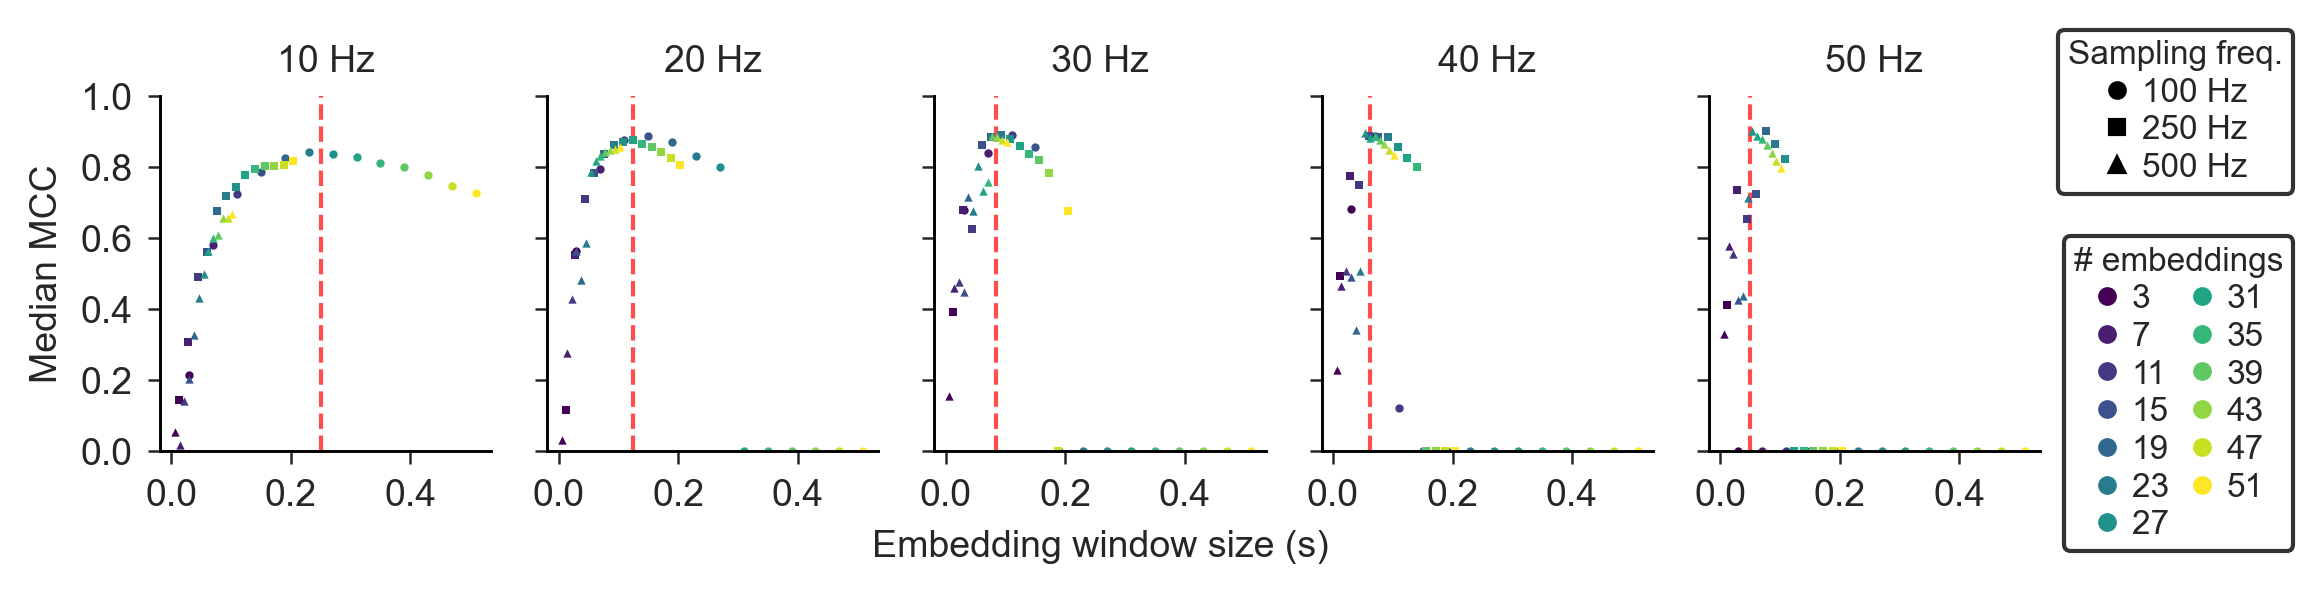

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.82         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(median_df["method"].dropna().unique())
burst_fs  = np.sort(median_df["burst_f"].dropna().unique())
num_embs  = np.sort(median_df["num_emb"].dropna().unique())
fs_levels = np.sort(median_df["fs"].dropna().unique())

BAND_HALF_WIDTH = 0.015   # 5 ms on each side -> total 10 ms


# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 2),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = median_df[(median_df["method"] == method) & (median_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))
        ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ref_x = TRUTH_CYCLES / bf
        # faint orange band: ±5 ms around reference

        ax.axvline(
            x=ref_x,
            color="red",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
            zorder=1
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["median_mcc"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel("Median MCC")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    columnspacing=0.60,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator, PercentFormatter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_manuscript_composite_lollipop(
    mean_df,
    df,
    sim_cond=None,
    savepath=None,
    truth_cycles=2.5,
    band_half_width=0.015,   # 0.015 = ±15 ms
    scatter_size=14,
):
    mean_df = mean_df.copy()
    df = df.copy()

    # -------------------------
    # checks
    # -------------------------
    mean_required = {"burst_f", "num_emb", "fs", "median_mcc"}
    raw_required  = {"burst_f", "num_emb", "fs", "num_states_active"}

    missing_mean = mean_required - set(mean_df.columns)
    missing_raw  = raw_required  - set(df.columns)

    if missing_mean:
        raise ValueError(f"mean_df is missing columns: {sorted(missing_mean)}")
    if missing_raw:
        raise ValueError(f"df is missing columns: {sorted(missing_raw)}")

    if "method" not in mean_df.columns:
        mean_df["method"] = "method"
    if "method" not in df.columns:
        df["method"] = "method"

    if "window_size" not in mean_df.columns:
        mean_df["window_size"] = mean_df["num_emb"] / mean_df["fs"]
    if "window_size" not in df.columns:
        df["window_size"] = df["num_emb"] / df["fs"]

    methods   = list(mean_df["method"].dropna().unique())
    burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
    num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
    fs_levels = np.sort(mean_df["fs"].dropna().unique())

    # -------------------------
    # style
    # -------------------------
    plt.rcParams.update({
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    ORANGE = "#F4A300"
    RED    = "#FF4D4D"
    GRAY   = "0.55"
    cmap   = plt.get_cmap("viridis")

    # -------------------------
    # palette / markers
    # -------------------------
    if len(num_embs) == 1:
        norm = Normalize(vmin=num_embs[0] - 0.5, vmax=num_embs[0] + 0.5)
        palette = {num_embs[0]: cmap(0.5)}
    else:
        norm = Normalize(vmin=num_embs.min(), vmax=num_embs.max())
        palette = {emb: cmap(norm(emb)) for emb in num_embs}

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
    if len(fs_levels) > len(marker_cycle):
        raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
    marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

    # -------------------------
    # figure layout
    # -------------------------
    n_methods = len(methods)
    n_burst   = len(burst_fs)

    fig_w = 1.7 * n_burst + 1.7
    fig_h = 1.75 * n_methods + 1.45

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        nrows=n_methods + 1,
        ncols=n_burst + 1,
        width_ratios=[1] * n_burst + [0.85],
        height_ratios=[1] * n_methods + [0.95],
        wspace=0.28,
        hspace=0.55,
    )

    # -------------------------
    # panel A: scatter panels
    # -------------------------
    axes = np.empty((n_methods, n_burst), dtype=object)
    first_ax = None

    x_min = max(0, mean_df["window_size"].min() - 0.02)
    x_max = mean_df["window_size"].max() + 0.02
    x_step = 0.1 if x_max <= 0.6 else 0.2

    for i, method in enumerate(methods):
        for j, bf in enumerate(burst_fs):
            if first_ax is None:
                ax = fig.add_subplot(gs[i, j])
                first_ax = ax
            else:
                ax = fig.add_subplot(gs[i, j], sharex=first_ax, sharey=first_ax)

            axes[i, j] = ax

            sub_df = mean_df[
                (mean_df["method"] == method) &
                (mean_df["burst_f"] == bf)
            ].copy()

            ref_x = truth_cycles / bf

            ax.axvspan(
                ref_x - band_half_width,
                ref_x + band_half_width,
                color=ORANGE,
                alpha=0.18,
                zorder=0
            )
            ax.axvline(
                ref_x,
                color=RED,
                linestyle="--",
                linewidth=1.0,
                alpha=0.85,
                zorder=1
            )

            for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
                ax.scatter(
                    g["window_size"],
                    g["median_mcc"],
                    color=palette[emb],
                    marker=marker_map[fs],
                    s=scatter_size,
                    linewidths=0,
                    alpha=0.95,
                    zorder=2,
                )

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(0, 1.0)
            ax.xaxis.set_major_locator(MultipleLocator(x_step))
            ax.yaxis.set_major_locator(MultipleLocator(0.2))
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if i == 0:
                ax.set_title(f"{bf:g} Hz", pad=10)

            if j == 0:
                if n_methods == 1:
                    ax.set_ylabel("Mean MCC")
                else:
                    ax.set_ylabel(f"{method}\nMean MCC")

            if i < n_methods - 1:
                ax.tick_params(labelbottom=False)

    axes[-1, n_burst // 2].set_xlabel("Embedding window size (s)")
    axes[0, 0].text(
        -0.30, 1.10, "A",
        transform=axes[0, 0].transAxes,
        fontsize=12, fontweight="bold",
        ha="left", va="bottom"
    )

    # -------------------------
    # panel B: compact lollipop
    # centered under middle columns
    # -------------------------
    if n_burst >= 5:
        ax_sum = fig.add_subplot(gs[-1, 1:4])
    elif n_burst >= 3:
        ax_sum = fig.add_subplot(gs[-1, :3])
    else:
        ax_sum = fig.add_subplot(gs[-1, :-1])

    band_df = df.loc[
        np.abs(df["window_size"] - (truth_cycles / df["burst_f"])) <= band_half_width
    ].copy()

    if len(band_df) == 0:
        raise ValueError("No rows fall inside the selected band.")

    band_df["num_states_active_diff"] = band_df["num_states_active"] - 2

    diff = band_df["num_states_active_diff"].dropna().astype(int)
    order = np.arange(diff.min(), diff.max() + 1)
    counts = diff.value_counts().reindex(order, fill_value=0).sort_index()
    props = counts / counts.sum()

    y = np.arange(len(order))

    for yi, d, p, c in zip(y, order, props.values, counts.values):
        color = ORANGE if d == 0 else GRAY
        ax_sum.hlines(yi, 0, p, color=color, lw=2.2, zorder=1)
        ax_sum.scatter(p, yi, s=45, color=color, edgecolor="black", linewidth=0.6, zorder=2)
        ax_sum.text(
            p + 0.012, yi,
            f"{c} ({100*p:.1f}%)",
            va="center", ha="left", fontsize=8
        )

    ax_sum.set_yticks(y)
    ax_sum.set_yticklabels([str(d) for d in order])
    ax_sum.set_xlabel("Proportion of runs")
    ax_sum.set_ylabel("Deviation in active-state count")
    ax_sum.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax_sum.set_xlim(0, max(props.max() * 1.35, 0.35))

    ax_sum.spines["top"].set_visible(False)
    ax_sum.spines["right"].set_visible(False)

    band_ms = int(round(1000 * band_half_width))
    ax_sum.text(
        0.00, 1.10,
        f"Runs within ±{band_ms} ms of the ground-truth window",
        transform=ax_sum.transAxes,
        ha="left", va="bottom", fontsize=8
    )
    ax_sum.text(
        1.00, 1.10,
        f"n = {len(diff)}",
        transform=ax_sum.transAxes,
        ha="right", va="bottom", fontsize=8
    )

    ax_sum.text(
        -0.18, 1.10, "B",
        transform=ax_sum.transAxes,
        fontsize=12, fontweight="bold",
        ha="left", va="bottom"
    )

    # -------------------------
    # side column: legend + colorbar
    # -------------------------
    side = gs[:, -1].subgridspec(
        nrows=2, ncols=1,
        height_ratios=[0.9, 1.15],
        hspace=0.42
    )

    ax_leg = fig.add_subplot(side[0, 0])
    ax_leg.axis("off")

    fs_handles = [
        mlines.Line2D(
            [], [], color="black",
            marker=marker_map[fs],
            linestyle="None",
            markersize=5.8,
            label=f"{int(fs)} Hz"
        )
        for fs in fs_levels
    ]

    leg = ax_leg.legend(
        handles=fs_handles,
        title="Sampling freq.",
        loc="upper left",
        frameon=True,
        borderpad=0.35,
        labelspacing=0.35,
        handletextpad=0.45,
        handlelength=0.8,
    )
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_alpha(1.0)

    ax_cbar = fig.add_subplot(side[1, 0])
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cbar, orientation="vertical")
    cbar.set_label("No. embeddings", fontsize=9)
    cbar.set_ticks(num_embs)
    cbar.ax.tick_params(labelsize=8, length=2)

    fig.subplots_adjust(left=0.08, right=0.93, bottom=0.14, top=0.94)

    if savepath is None and sim_cond is not None:
        savepath = f"../figures/raw_figure/{sim_cond}_composite_lollipop.png"

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.03)

    plt.show()
    return fig


# -------------------------
# example call
# -------------------------
plot_manuscript_composite_lollipop(
    mean_df=mean_df,
    df=df,
    sim_cond=sim_cond,
    savepath=None,          # or e.g. "../figures/final/sim_result_composite.pdf"
    truth_cycles=2.5,
    band_half_width=0.015,  # ±15 ms
    scatter_size=14,
)

NameError: name 'mean_df' is not defined

In [24]:



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.82         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(mean_df["method"].dropna().unique())
burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
fs_levels = np.sort(mean_df["fs"].dropna().unique())

# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 2),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))

        #ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ax.axvline(
            x=TRUTH_CYCLES / bf,
            color="red",
            linestyle="--",
            linewidth = 1,
            alpha=0.7
        )

        ax.axhline(
            y = 2,
            color="black",
            linestyle="--",
            linewidth=0.7,
            alpha=0.7
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["mean_active_states_diff"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel("Mean active states")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    columnspacing=0.60,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results_active_states.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


NameError: name 'mean_df' is not defined

In [25]:
df.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.29273134, 'weights': [0.5695511, 0...",1.0347505,4,2115331525,...,201.831493,0.482088,202.313581,10,3,"[1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, ...","[1, 0]",None,0.160969,1.0347505
1,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.31598914, 'weights': [0.5411968, 0...",0.9151948,9,3685075416,...,231.521849,0.474563,231.996412,10,7,"[0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, ...","[0, 1]",None,0.580943,0.9151948
2,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.3298428, 'weights': [0.61319804, 0...",0.86433065,4,411306526,...,256.409930,0.509579,256.919509,10,11,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.705430,0.86433065
3,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.38528442, 'weights': [0.6463548, 0...",0.8398367,4,2007295958,...,276.959226,0.520020,277.479246,10,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.785034,0.8398367
4,DP-GMM,"[-0.8498616546270453, -0.41409058865861503, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10,100,2,"{'alpha': 0.48961407, 'weights': [0.66300255, ...",0.8253039,4,1297792343,...,315.493184,0.541160,316.034344,10,19,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.831509,0.8253039


In [26]:
df["window_size"] = 1/ df["fs"].values * df["num_emb"].values


BAND_HALF_WIDTH = 0.005   # ±5 ms, total 10 ms

band_df = df.loc[
    np.abs(df["window_size"] - (TRUTH_CYCLES / df["burst_f"])) <= BAND_HALF_WIDTH
].copy()

band_df["num_states_active_diff"] = band_df["num_states_active"] - 2

print(f"Rows inside orange band: {len(band_df)}")

sns.histplot(data=band_df, x="num_states_active_diff", discrete=True)
plt.xlabel("Deviation in # of Active States (Estimated − 2)")
plt.ylabel("Count")
plt.show()

KeyError: 'num_states_active'

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# =========================================================
# USER STYLE
# =========================================================
FIG_WIDTH = 7.5
FIG_HEIGHT = 3.6

MY_FONT_SIZE = 9
TICK_FONT_SIZE = 7
LEG_FONT_SIZE = 7
TITLE_FONT_SIZE = 9

plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": LEG_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": TITLE_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.7,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # --- Grid ---
    "axes.grid": False,

    # --- Layout ---
    "figure.autolayout": False,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})

# =========================================================
# CONFIG
# =========================================================
TRUTH_CYCLES = 2.5
BAND_HALF_WIDTH = 0.02   # 0.02 s = ±20 ms
SCATTER_SIZE = 13

LEG_MARKERSIZE = 3.8
TRUTH_BAND_COLOR = "orange"
TRUTH_LINE_COLOR = "red"
BAR_COLOR = "0.75"

METHOD_TO_PLOT = mean_df["method"].dropna().unique()[0]

# =========================================================
# COPY DATA
# =========================================================
mean_df = mean_df.copy()
df = df.copy()

if "window_size" not in mean_df.columns:
    mean_df["window_size"] = mean_df["num_emb"] / mean_df["fs"]

if "window_size" not in df.columns:
    df["window_size"] = df["num_emb"] / df["fs"]

df["num_states_active_diff"] = df["num_states_active"] - 2

mean_sub = mean_df[mean_df["method"] == METHOD_TO_PLOT].copy()
if "method" in df.columns:
    df_sub = df[df["method"] == METHOD_TO_PLOT].copy()
else:
    df_sub = df.copy()

# =========================================================
# ORDERING
# =========================================================
burst_fs = np.sort(mean_sub["burst_f"].dropna().unique())
num_embs = np.sort(mean_sub["num_emb"].dropna().unique())
fs_levels = np.sort(mean_sub["fs"].dropna().unique())

# =========================================================
# COLOR PALETTE (num_emb)
# =========================================================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================================================
# MARKER MAP (fs)
# =========================================================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================================================
# PRECOMPUTE BOTTOM COUNTS
# =========================================================
bottom_counts = {}
global_devs = set()
max_count = 0

for bf in burst_fs:
    tmp = df_sub[df_sub["burst_f"] == bf].copy()
    ref_x = TRUTH_CYCLES / bf

    band_tmp = tmp.loc[
        np.abs(tmp["window_size"] - ref_x) <= BAND_HALF_WIDTH
    ].copy()

    x = band_tmp["num_states_active_diff"].dropna().astype(int)

    if len(x) == 0:
        bottom_counts[bf] = {"counts": None, "n": 0}
        continue

    order = np.arange(x.min(), x.max() + 1)
    counts = x.value_counts().reindex(order, fill_value=0).sort_index()

    bottom_counts[bf] = {"counts": counts, "n": len(x)}
    global_devs.update(order.tolist())
    max_count = max(max_count, counts.max())

if len(global_devs) == 0:
    raise ValueError("No runs fall inside the selected window band.")

global_order = np.arange(min(global_devs), max(global_devs) + 1)

# =========================================================
# FIGURE LAYOUT
# =========================================================
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
gs = fig.add_gridspec(
    nrows=2,
    ncols=len(burst_fs) + 1,
    width_ratios=[1, 1, 1, 1, 1, 1.35],   # wider legend column
    height_ratios=[1.18, 0.88],
    wspace=0.30,
    hspace=0.34,
)

top_axes = []
bottom_axes = []

# =========================================================
# TOP ROW
# =========================================================
x_min = max(0, mean_sub["window_size"].min() - 0.02)
x_max = mean_sub["window_size"].max() + 0.02
x_step = 0.2   # force sparser x ticks to avoid overlap

first_top_ax = None
for j, bf in enumerate(burst_fs):
    if first_top_ax is None:
        ax = fig.add_subplot(gs[0, j])
        first_top_ax = ax
    else:
        ax = fig.add_subplot(gs[0, j], sharex=first_top_ax, sharey=first_top_ax)

    top_axes.append(ax)
    sub_df = mean_sub[mean_sub["burst_f"] == bf].copy()
    ref_x = TRUTH_CYCLES / bf

    ax.axvspan(
        ref_x - BAND_HALF_WIDTH,
        ref_x + BAND_HALF_WIDTH,
        color=TRUTH_BAND_COLOR,
        alpha=0.15,
        zorder=0,
    )
    ax.axvline(
        x=ref_x,
        color=TRUTH_LINE_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=1,
    )

    for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
        ax.scatter(
            g["window_size"],
            g["median_mcc"],
            color=palette[emb],
            marker=marker_map[fs],
            s=SCATTER_SIZE-7,
            linewidths=0,
            alpha=0.95,
            zorder=2,
        )

    ax.set_title(f"{bf:g} Hz", pad=8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.0)
    ax.xaxis.set_major_locator(MultipleLocator(x_step))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    if j == 0:
        ax.set_ylabel("Mean MCC")
    else:
        ax.tick_params(labelleft=False)

# =========================================================
# BOTTOM ROW
# =========================================================
first_bottom_ax = None
for j, bf in enumerate(burst_fs):
    if first_bottom_ax is None:
        ax = fig.add_subplot(gs[1, j])
        first_bottom_ax = ax
    else:
        ax = fig.add_subplot(gs[1, j], sharex=first_bottom_ax, sharey=first_bottom_ax)

    bottom_axes.append(ax)
    info = bottom_counts[bf]

    if info["counts"] is not None:
        counts = info["counts"].reindex(global_order, fill_value=0)

        colors = [BAR_COLOR] * len(global_order)
        if 0 in global_order:
            zero_idx = np.where(global_order == 0)[0][0]
            colors[zero_idx] = TRUTH_BAND_COLOR

        ax.bar(
            global_order,
            counts.values,
            width=0.72,
            color=colors,
            edgecolor="black",
            linewidth=0.7,
            zorder=2,
        )



        ax.text(
            0.95, 0.90, f"n = {info['n']}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=LEG_FONT_SIZE,
        )
    else:
        ax.text(
            0.5, 0.5, "No runs\nin band",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=LEG_FONT_SIZE,
        )

    ax.set_xticks(global_order)
    ax.set_xlim(global_order.min() - 0.55, global_order.max() + 0.55)
    ax.set_ylim(0, max_count * 1.12 + 0.5)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    if j == 0:
        ax.set_ylabel("Counts")
    else:
        ax.tick_params(labelleft=False)

# blank lower-right cell
ax_blank = fig.add_subplot(gs[1, -1])
ax_blank.axis("off")

# =========================================================
# LEGENDS IN TOP-RIGHT COLUMN: SPLIT INTO TWO REAL PANELS
# =========================================================
leg_gs = gs[0, -1].subgridspec(
    nrows=2, ncols=1,
    height_ratios=[0.80, 1.20],
    hspace=0.15
)

ax_leg_top = fig.add_subplot(leg_gs[0, 0])
ax_leg_top.axis("off")

ax_leg_bottom = fig.add_subplot(leg_gs[1, 0])
ax_leg_bottom.axis("off")

fs_handles = [
    mlines.Line2D(
        [], [], color="black",
        marker=marker_map[fs],
        linestyle="None",
        markersize=LEG_MARKERSIZE,
        label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg_fs = ax_leg_top.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="upper left",
    frameon=True,
    borderaxespad=0.0,
    fontsize=LEG_FONT_SIZE,
    title_fontsize=TITLE_FONT_SIZE,
    borderpad=0.25,
    labelspacing=0.18,
    handletextpad=0.30,
    handlelength=0.7,
)
leg_fs.get_frame().set_edgecolor("black")
leg_fs.get_frame().set_alpha(1.0)

emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE,
        label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg_emb = ax_leg_bottom.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="upper left",
    ncol=2,
    frameon=True,
    borderaxespad=0.0,
    fontsize=LEG_FONT_SIZE,
    title_fontsize=TITLE_FONT_SIZE,
    borderpad=0.25,
    labelspacing=0.16,
    handletextpad=0.28,
    columnspacing=0.45,
    handlelength=0.7,
)
leg_emb.get_frame().set_edgecolor("black")
leg_emb.get_frame().set_alpha(1.0)

# =========================================================
# PANEL LETTERS
# =========================================================
top_axes[0].text(
    -0.26, 1.08, "A",
    transform=top_axes[0].transAxes,
    fontsize=MY_FONT_SIZE + 2,
    fontweight="bold",
    ha="left",
    va="bottom"
)

bottom_axes[0].text(
    -0.26, 1.08, "B",
    transform=bottom_axes[0].transAxes,
    fontsize=MY_FONT_SIZE + 2,
    fontweight="bold",
    ha="left",
    va="bottom"
)

# =========================================================
# FINAL SPACING
# =========================================================
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.95)

fig.canvas.draw()

x_center = 0.5 * (top_axes[0].get_position().x0 + top_axes[-1].get_position().x1)

gap_top = top_axes[0].get_position().y0
gap_bottom = bottom_axes[0].get_position().y1
y_top_xlabel = gap_bottom + 0.28 * (gap_top - gap_bottom)
y_bottom_xlabel = bottom_axes[0].get_position().y0 - 0.12

fig.text(
    x_center,
    y_top_xlabel,
    "Embedding window size (s)",
    ha="center",
    va="center",
    fontsize=MY_FONT_SIZE,
)

fig.text(
    x_center,
    y_bottom_xlabel,
    "Deviation in active-state count (estimated - ground truth)",
    ha="center",
    va="center",
    fontsize=MY_FONT_SIZE,
)

# fig.savefig("../figures/raw_figure/sim_cond_2x5_final.png",
#             bbox_inches="tight", pad_inches=0.02)

plt.show()

NameError: name 'mean_df' is not defined

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# SHARED STYLE
# -------------------------
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
    "savefig.dpi": 300,
})

TRUTH_COLOR = "orange"
BAR_COLOR = "0.65"

# -------------------------
# COMPUTE BAND DATA
# -------------------------
df = df.copy()
df["window_size"] = df["num_emb"] / df["fs"]

BAND_HALF_WIDTH = 0.015   # ±15 ms; fix this if you intended ±5 ms

band_df = df.loc[
    np.abs(df["window_size"] - (TRUTH_CYCLES / df["burst_f"])) <= BAND_HALF_WIDTH
].copy()

band_df["num_states_active_diff"] = band_df["num_states_active"] - 2

x = band_df["num_states_active_diff"].dropna().astype(int)
order = np.arange(x.min(), x.max() + 1)
counts = x.value_counts().reindex(order, fill_value=0)

# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(2.8, 2.0))

bar_colors = [BAR_COLOR] * len(order)
if 0 in order:
    zero_idx = np.where(order == 0)[0][0]
    bar_colors[zero_idx] = TRUTH_COLOR

ax.bar(
    order,
    counts.values,
    width=0.8,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

# reference line at correct estimate
if 0 in order:
    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.8)

ax.set_xlabel("Deviation in active-state count\n(estimated − ground truth)")
ax.set_ylabel("Number of fits")   # or: "Number of settings"

ax.set_xticks(order)
ax.set_xlim(order.min() - 0.6, order.max() + 0.6)
ax.set_ylim(0, counts.max() * 1.15 + 0.5)

# sample size
ax.text(
    0.98, 0.96, f"n = {len(x)}",
    transform=ax.transAxes,
    ha="right", va="top", fontsize=8
)

# cleaner spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

KeyError: 'num_states_active'

In [29]:
df["num_states_active_diff"] = df["num_states_active"] - 2



KeyError: 'num_states_active'

In [30]:
sns.histplot(data=df, x="num_states_active_diff", discrete=True)
plt.xlabel("Deviation in # of Active States (Estimated − 2)")
plt.ylabel("Count")
plt.show()

ValueError: Could not interpret value `num_states_active_diff` for `x`. An entry with this name does not appear in `data`.

# 3-state scenario

In [45]:
from nds_toolbox.preprocessing.features import choose_embedding_dim, trim_data
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.preprocessing.features import compute_wavelet
from nds_toolbox.preprocessing.features import compute_tde
from nds_toolbox.models.dpgmm_numpyro import truncate
from nds_toolbox.preprocessing.features import trim_data
from nds_toolbox.models.dpgmm_numpyro import get_states
from nds_toolbox.utils.helper import match_states


fs = 250         # Sampling frequency in Hz.
n_seconds = 60   # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))


# Condition 1: frequency distances (3 states)
freqs_dist_range = [[10, 40], [15, 40], [20, 40], [25, 40], [30, 40],[35, 40]]  #30, 25, 20, 15, 10, 5Hz diff

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB




In [46]:
sim_cond_data = "3states"

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (5, 6, 11, 45000)


In [47]:
snr_range

array([-10,  -8,  -6,  -4,  -2,   0,   2,   4,   6,   8,  10])

In [48]:



performance_dir = "../data/simulations"
file_path = f"{performance_dir}/3states_data.npz"

signal = np.load(file_path)
signal["signal_sample"][-1]

array([[[-0.1363738 , -0.18047502,  0.08167195, ..., -0.05770917,
         -0.15138972, -0.07153542],
        [-0.1363738 , -0.18031328,  0.08288943, ..., -0.06468139,
         -0.15138972, -0.0645632 ],
        [-0.1363738 , -0.18010966,  0.08442214, ..., -0.0734589 ,
         -0.15138972, -0.05578569],
        ...,
        [-0.1363738 , -0.17715834,  0.10663781, ..., -0.20068289,
         -0.15138972,  0.07143831],
        [-0.1363738 , -0.17613782,  0.11431958, ..., -0.24467465,
         -0.15138972,  0.11543006],
        [-0.1363738 , -0.17485307,  0.12399036, ..., -0.30005698,
         -0.15138972,  0.1708124 ]],

       [[ 0.35616214,  0.31511812,  0.21173175, ...,  0.33762432,
          0.34596073,  0.13936564],
        [ 0.35616214,  0.31565829,  0.21549112, ...,  0.33762432,
          0.34596073,  0.13936564],
        [ 0.35616214,  0.31633832,  0.22022388, ...,  0.33762432,
          0.34596073,  0.13936564],
        ...,
        [ 0.35616214,  0.3261949 ,  0.28882208, ...,  

In [49]:

sim_cond = "3states_est_k"


performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
gmm_df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

gmm_df_3states["burst_f"] = gmm_df_3states["burst_f"].apply(tuple)

gmm_df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-0.6966162536171051, -1.4341820911803904, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.3453871, 'weights': [1.0], 'means'...",0.78511506,0,479243620,...,467.256817,0.611311,467.868128,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.78511506
1,DP-GMM (Imputed),"[-0.6966162536171051, -1.4341820911803904, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.3453871, 'weights': [1.0], 'means'...",0.78511506,0,479243620,...,467.256817,0.611311,467.868128,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.78511506
2,DP-GMM,"[-0.6940842432854243, -1.4288155776650338, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'alpha': 0.35129267, 'weights': [1.0], 'means...",0.7859595,0,479243620,...,456.475364,0.076427,456.551791,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7859595
3,DP-GMM (Imputed),"[-0.6940842432854243, -1.4288155776650338, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'alpha': 0.35129267, 'weights': [1.0], 'means...",0.7859595,0,479243620,...,456.475364,0.076427,456.551791,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7859595
4,DP-GMM,"[-0.6900688698209411, -1.420357454806654, -1.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-6,"{'alpha': 0.3829929, 'weights': [0.9674714, 0....",0.7870618,5,2666256175,...,470.829090,0.069266,470.898356,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.043124,0.7870618


In [15]:
# extract parameters

snr_db = 8
snr_id = np.where(snr_range == snr_db)[0][0]
print(snr_id)
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 4


res = gmm_df_3states.query("burst_f == @plot_f and snr == @snr_db")
res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]



signal = res["signal"]
num_emb = res["num_emb"]
true_states = res["true_states"]
mcc = res["mcc"]
num_states = res["num_states"]


tde_data = compute_tde(signal, num_emb)
trimmed_signal = trim_data(signal, num_emb)
trimmed_states = trim_data(true_states, num_emb)
true_states_onehot = np.eye(trimmed_states.max() +1)[trimmed_states]




est_params = res["est_params"]
weights = est_params["weights"]
means = est_params["means"]
covs = est_params["covs"]

alpha = est_params["alpha"]
untrunc_weights = est_params["untrunc_weights"]
untrunc_means = est_params["untrunc_means"]
untrunc_covs = est_params["untrunc_covs"]
est_states = res["est_states"]
est_states_onehot = np.eye(num_active_states)[est_states]

print(len(weights))


trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(untrunc_means, untrunc_covs, untrunc_weights,
                                            verbose=True, return_info=True, remove_edge_states=False)

est_states_with_edge = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
est_states_onehot_with_edge = np.eye(8)[est_states_with_edge]

order, reordered_est_states_onehot = match_states(
    true_states_onehot, est_states_onehot_with_edge, verbose=False
)
est_states_with_edge = np.argmax(reordered_est_states_onehot, axis=1)




9
10 data points were lost from both ends.
data shape: (44980, 21)
Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)
4
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 9
    kept original indices       : [0, 1, 2, 3, 4, 5, 6, 7, 8]
    retained weight mass        : 0.9948
    dropped weight mass         : 0.0052

  Final result
    final components kept       : 9
    final original indices      : [0, 1, 2, 3, 4, 5, 6, 7, 8]
    final retained weight mass  : 0.9948
    final dropped weight mass   : 0.0052


IndexError: index 8 is out of bounds for axis 0 with size 8

In [16]:
cmap = plt.get_cmap("tab10")
colors = ["#BDBDBD"] + [cmap(i) for i in range(num_states)]
state_labels = [f"S{i + 1}" for i in range(num_states)]


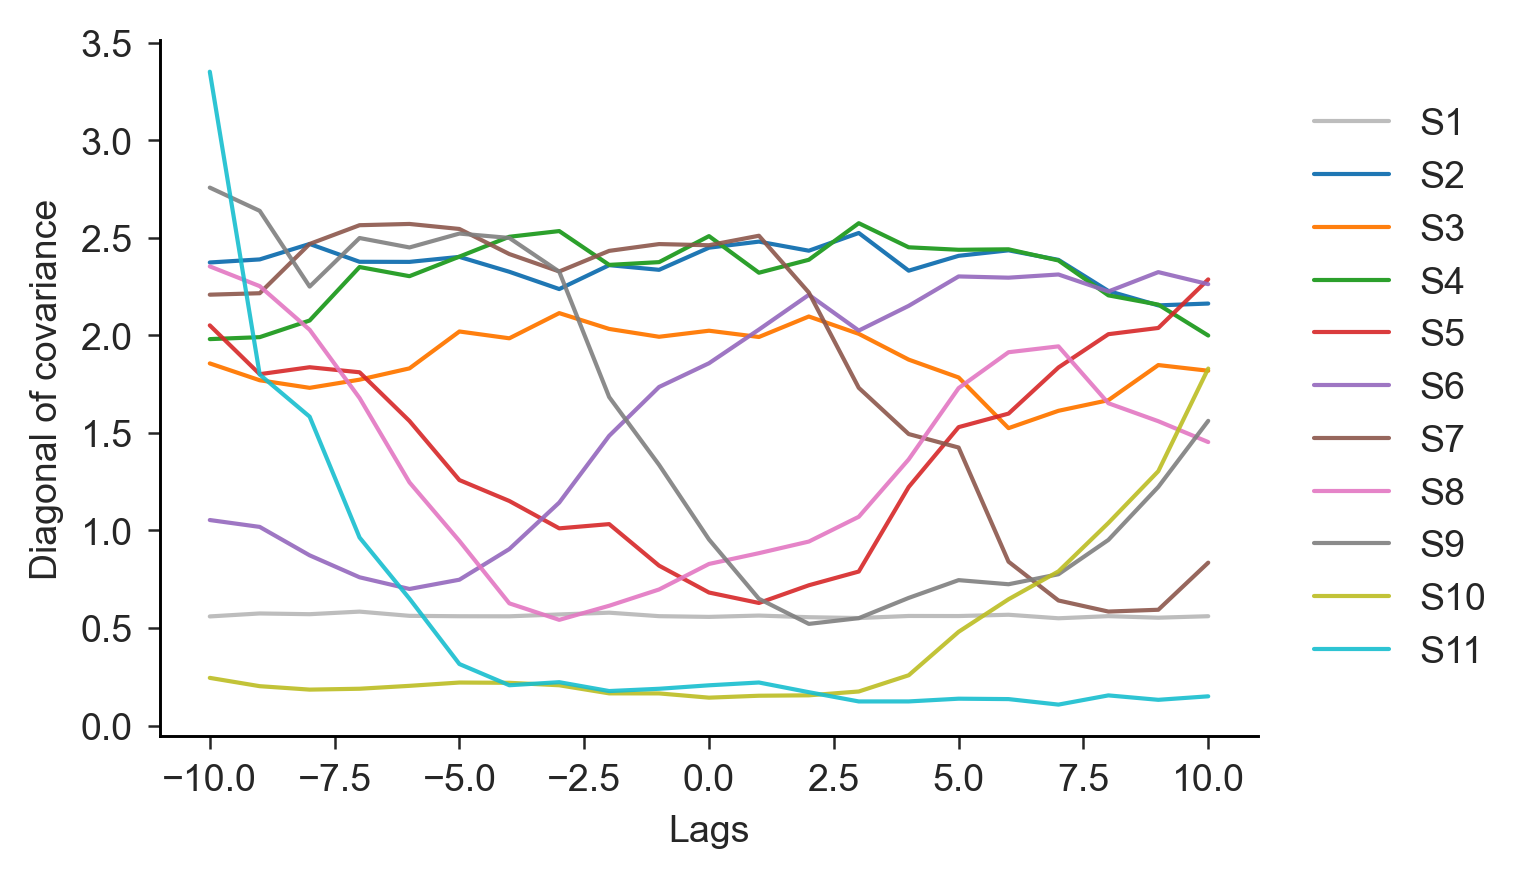

In [17]:
plt.figure(figsize=(FIG_WIDTH - 1, 3))


dim_vec = np.arange(-num_emb // 2 + 1, num_emb // 2 + 1).astype(int)


for i, cov in enumerate(untrunc_covs):

    if i <= 3:
        plt.plot(dim_vec, np.diag(cov), label=f"S{i + 1}", color=colors[i], lw=1)

    else:
        plt.plot(dim_vec, np.diag(cov), label=f"S{i + 1}", color=colors[i], lw=1, alpha=0.9)

plt.xlabel("Lags")
plt.ylabel("Diagonal of covariance")

# legend outside (right)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# leave room on the right for the legend
plt.tight_layout(rect=[0, 0, 0.80, 1])

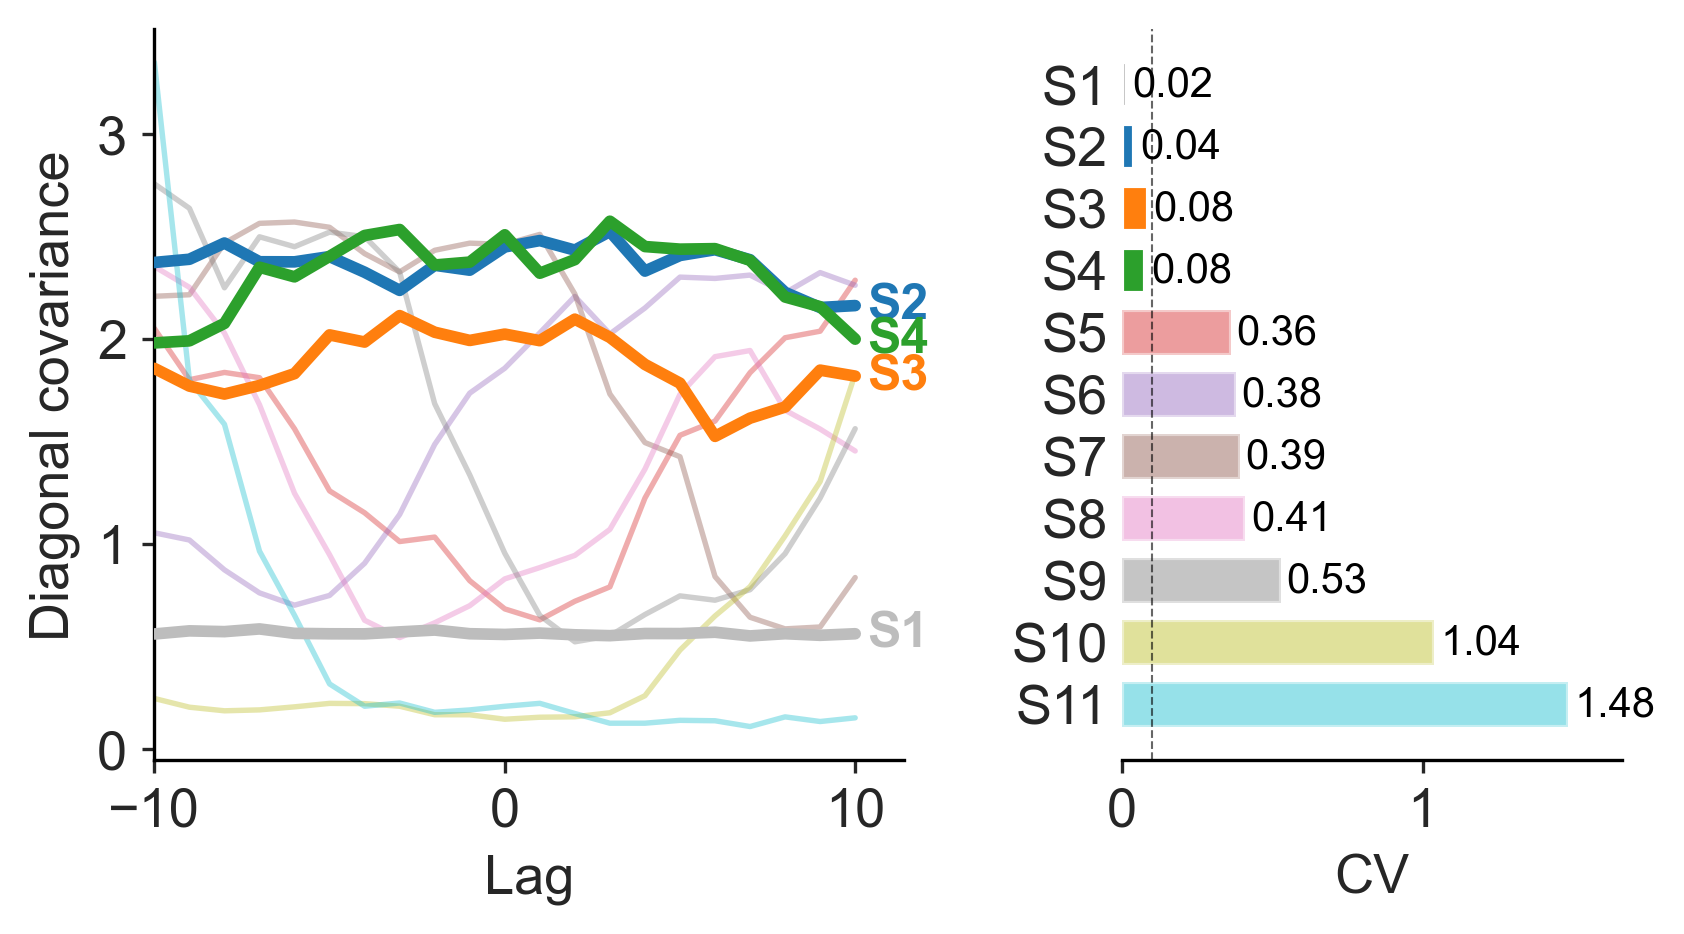

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
n_states = len(untrunc_covs)
dim_vec = np.arange(-num_emb // 2 + 1, num_emb // 2 + 1).astype(int)
cv_threshold = 0.1

# -----------------------------
# Extract diagonals and compute CV
# -----------------------------
diags = [np.diag(cov) for cov in untrunc_covs]

cv_vals = []
for d in diags:
    mu = np.mean(d)
    sd = np.std(d)
    cv = sd / (mu + 1e-12)
    cv_vals.append(cv)

cv_vals = np.array(cv_vals)

# define stable states from the threshold
stable_states = np.where(cv_vals < cv_threshold)[0].tolist()

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(FIG_WIDTH-2, 3), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.1)

ax = fig.add_subplot(gs[0, 0])
ax_cv = fig.add_subplot(gs[0, 1])

# -----------------------------
# Main covariance diagonal plot
# -----------------------------
for i, d in enumerate(diags):
    is_stable = i in stable_states
    ax.plot(
        dim_vec,
        d,
        color=colors[i],
        lw=2.8 if is_stable else 1.3,
        alpha=1.0 if is_stable else 0.38,
        zorder=4 if is_stable else 2,
    )

# optional: label only stable states at the right end
x_text = dim_vec[-1] + 0.35
for i in stable_states:
    ax.text(
        x_text,
        diags[i][-1],
        f"S{i + 1}",
        color=colors[i],
        fontsize=12,
        fontweight="bold",
        va="center",
        ha="left",
    )

ax.set_xlim(dim_vec[0], dim_vec[-1] + 1.4)
ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Diagonal covariance", fontsize=13)

ax.tick_params(axis="both", labelsize=13, width=0.8, length=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.set_axisbelow(True)

# -----------------------------
# CV panel
# -----------------------------
state_ids = np.arange(n_states)

for i in state_ids:
    ax_cv.barh(
        i,
        cv_vals[i],
        color=colors[i],
        alpha=1.0 if i in stable_states else 0.45,
        height=0.72,
    )

    # numeric label right next to each bar
    ax_cv.text(
        cv_vals[i] + 0.02,
        i,
        f"{cv_vals[i]:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        color="black",
    )

ax_cv.set_yticks(state_ids)
ax_cv.set_yticklabels([f"S{i + 1}" for i in state_ids], fontsize=13)
ax_cv.invert_yaxis()

ax_cv.set_xlabel("CV", fontsize=13)
ax_cv.tick_params(axis="x", labelsize=13, width=0.8, length=3)
ax_cv.tick_params(axis="y", length=0)

ax_cv.spines["top"].set_visible(False)
ax_cv.spines["right"].set_visible(False)
ax_cv.spines["left"].set_visible(False)
ax_cv.spines["bottom"].set_linewidth(0.8)


ax_cv.set_axisbelow(True)

# threshold line at CV = 0.1
ax_cv.axvline(cv_threshold, color="k", lw=0.5, alpha=0.6, ls="--")



# leave room for the numeric labels
xmax = np.nanmax(cv_vals)
ax_cv.set_xlim(0, xmax + 0.18)

plt.show()

## merging with the other 3state scenario results

In [19]:



performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond_data}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

df_3states["burst_f"] = df_3states["burst_f"].apply(tuple)

df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.3334877, 'weights': [0.9979328, 0....",0.7826813,1.0,454024514.0,...,0.541619,268.991583,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.012779,0.7826813,NaN
1,DP-GMM (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.3334877, 'weights': [0.9979328, 0....",0.7826813,1.0,454024514.0,...,0.541619,268.991583,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7826813,NaN
2,HMM,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,0.322336,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.056893,0.756168,1.0
3,HMM (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,0.322336,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.061085,0.756168,1.0
4,Thresholding,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,0.001672,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.197054,"[[0.30000000000000004, 0.30000000000000004], [...",NaN


In [20]:
gmm_df_3states["method"]

0                 DP-GMM
1       DP-GMM (Imputed)
2                 DP-GMM
3       DP-GMM (Imputed)
4                 DP-GMM
              ...       
1315    DP-GMM (Imputed)
1316              DP-GMM
1317    DP-GMM (Imputed)
1318              DP-GMM
1319    DP-GMM (Imputed)
Name: method, Length: 1320, dtype: object

In [42]:
freq

NameError: name 'freq' is not defined

In [43]:
fs

250

In [44]:
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.analysis.utils import imputing_mode


for i in range(len(gmm_df_3states)):
    
    method = gmm_df_3states.iloc[i]["method"]
    freq = np.array(gmm_df_3states.iloc[i]["burst_f"])
    snr = gmm_df_3states.iloc[i]["snr"]
    print(f"snr = {snr}; freqs = {freq}")
    
    

    
    true_states = gmm_df_3states.iloc[i]["true_states"]
    old_mcc = gmm_df_3states.iloc[i]["mcc"]
    est_params = gmm_df_3states.iloc[i]["est_params"]
    alpha = est_params["alpha"]
    weights = est_params["untrunc_weights"]
    means = est_params["untrunc_means"]
    covs = est_params["untrunc_covs"]
    signal = gmm_df_3states.iloc[i]["signal"]
    num_emb = gmm_df_3states.iloc[i]["num_emb"]
    tde_data = compute_tde(signal, num_emb)

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info= True, edge_states_cv = 0.1)


    num_active_states = int(len(trunc_weights))

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    
    if method == "DP-GMM (Imputed)":
        
    #knn imputation
        min_samples = np.round((2/np.max(freq))*fs).astype(int)

        est_states = imputing_mode(est_states, min_samples = min_samples)

    est_states_onehot = np.eye(num_active_states)[est_states]

    trimmed_states = trim_data(true_states, num_emb, verbose = False)


    true_states_onehot = np.eye(trimmed_states.max()+1, dtype=np.float32)[trimmed_states]



    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)
    


    mcc = matthews_corrcoef(trimmed_states, est_states)
    
    est_params = {
    "alpha": alpha,
    "weights": trunc_weights,
    "means": trunc_means,
    "covs": trunc_covs,
    "untrunc_means": means,
    "untrunc_covs": covs,
    "untrunc_weights": weights,
    "num_states_active":num_active_states,
    "trunc_info": trunc_info,}

    

    gmm_df_3states.at[i, "est_params"] = est_params
    gmm_df_3states.at[i, "mcc"] = float(mcc)
    gmm_df_3states.at[i, "est_states"] = np.asarray(est_states)
    gmm_df_3states.at[i, "num_states_active"] = num_active_states
    print("mcc", old_mcc)
    print("new mcc", mcc)
    #print()
    #print()

snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 1
    kept original indices       : [0]
    retained weight mass        : 0.9999
    dropped weight mass         : 0.0001

  Stage 2: edge-state removal
    CV threshold                : 0.100
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0114]

  Final result
    final components kept       : 1
    final original indices      : [0]
    final retained weight mass  : 0.9999
    final dropped weight mass   : 0.0001
mcc 0.0
new mcc 0.0
snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 1
    kept orig

KeyboardInterrupt: 

In [45]:
methods = ["DP-GMM (Imputed)", "DP-GMM"]

# 1) drop old DP-GMM rows
df_keep = df_3states.loc[~df_3states["method"].isin(methods)].copy()


# 2) append new DP-GMM rows (your source of truth)
df_3states = pd.concat([df_keep, gmm_df_3states.copy()], ignore_index=True)


In [46]:
df_3states

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active
0,HMM,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.056893,0.756168,1.0,NaN
1,HMM (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.061085,0.756168,1.0,NaN
2,Thresholding,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.197054,"[[0.30000000000000004, 0.30000000000000004], [...",NaN,NaN
3,Thresholding (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.198073,"[[0.30000000000000004, 0.30000000000000004], [...",NaN,NaN
4,HMM,"[-1.4194751248175188, -0.6442518238696098, 0.6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'initial_probs': [0.27990672, 0.40751556, 0.3...",0.756446,NaN,NaN,...,185.553713,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.073450,0.756446,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3955,DP-GMM (Imputed),"[0.10747542341726199, -0.6208818420947805, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,6,"{'alpha': 2.190439, 'weights': [0.65424526, 0....",0.79638296,3.0,1.415260e+09,...,359.880619,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1]",None,0.865838,0.79638296,NaN,NaN
3956,DP-GMM,"[0.09888966773932419, -0.5775959678643968, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,8,"{'alpha': 2.240827, 'weights': [0.7154195, 0.1...",0.7361026,2.0,5.323744e+08,...,349.214785,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1]",None,0.788736,0.7361026,NaN,NaN
3957,DP-GMM (Imputed),"[0.09888966773932419, -0.5775959678643968, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,8,"{'alpha': 2.240827, 'weights': [0.7154195, 0.1...",0.7361026,2.0,5.323744e+08,...,349.214785,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1]",None,0.879687,0.7361026,NaN,NaN
3958,DP-GMM,"[0.08854884098620477, -0.5244677862554108, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,10,"{'alpha': 2.7639308, 'weights': [0.92280453, 0...",0.65200394,2.0,5.323744e+08,...,338.721068,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.880232,0.65200394,NaN,NaN


In [47]:
res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]


In [48]:
snr_range == snr_db

array([False, False, False, False, False, False, False, False, False,
        True, False])

In [49]:
snr_id = np.where(snr_range == snr_db)[0][0]


In [50]:
num_states = 3
snr_db = 0
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 0


res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]
hmm_res = res.query("method == 'HMM (Imputed)'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding (Imputed)'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]





trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)


trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]

Lost 12 data points were lost from both ends.
data shape: (44976,)
Lost 12 data points were lost from both ends.
data shape: (44976,)
Lost 12 data points were lost from both ends.
data shape: (44976,)


In [51]:
df_3states.query("burst_f == @plot_f")

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active
88,HMM,"[1.441942841422249, 0.3799228218161315, 0.4178...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'initial_probs': [0.37112677, 0.353144, 0.275...",0.767382,NaN,NaN,...,122.774288,3,25,"[0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, ...","[0, 2, 1]",None,0.031909,0.767382,7.0,NaN
89,HMM (Imputed),"[1.441942841422249, 0.3799228218161315, 0.4178...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'initial_probs': [0.37112677, 0.2757292, 0.35...",0.767382,NaN,NaN,...,122.774288,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.000000,0.767382,7.0,NaN
90,Thresholding,"[1.441942841422249, 0.3799228218161315, 0.4178...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'enveloped_signal': [[0.10669386, 0.101323135...",NaN,NaN,NaN,...,1.437343,3,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.213406,"[[0.4, 0.30000000000000004], [0.5, 0.4]]",NaN,NaN
91,Thresholding (Imputed),"[1.441942841422249, 0.3799228218161315, 0.4178...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'enveloped_signal': [[0.10669386, 0.101323135...",NaN,NaN,NaN,...,1.437343,3,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.211978,"[[0.4, 0.30000000000000004], [0.5, 0.4]]",NaN,NaN
92,HMM,"[1.4381113709211102, 0.3787876010306261, 0.416...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-8,"{'initial_probs': [0.3770171, 0.27789962, 0.34...",0.768891,NaN,NaN,...,122.330797,3,25,"[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, ...","[1, 0, 2]",None,0.047496,0.768891,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3889,DP-GMM (Imputed),"[-1.360962860816844, -1.0541868160346355, -1.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 3.7984204, 'weights': [0.84555465, 0...",0.7475531,7.0,149413706.0,...,411.232957,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.939961,0.7475531,NaN,NaN
3890,DP-GMM,"[-1.2474339356033575, -0.9664827896943484, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,8,"{'alpha': 2.2081506, 'weights': [0.684946, 0.1...",0.6751639,7.0,149413706.0,...,394.509629,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1]",None,0.820704,0.6751639,NaN,NaN
3891,DP-GMM (Imputed),"[-1.2474339356033575, -0.9664827896943484, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,8,"{'alpha': 2.2081506, 'weights': [0.684946, 0.1...",0.6751639,7.0,149413706.0,...,394.509629,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1]",None,0.902256,0.6751639,NaN,NaN
3892,DP-GMM,"[-1.1143356356873448, -0.8636242399221169, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,10,"{'alpha': 0.8469711, 'weights': [0.8824778, 0....",0.5770235,8.0,493199887.0,...,413.519821,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.755300,0.5770235,NaN,NaN


In [52]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active
0,HMM,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.056893,0.756168,1.0,NaN
1,HMM (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.061085,0.756168,1.0,NaN
2,Thresholding,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.197054,"[[0.30000000000000004, 0.30000000000000004], [...",NaN,NaN
3,Thresholding (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.198073,"[[0.30000000000000004, 0.30000000000000004], [...",NaN,NaN
4,HMM,"[-1.4194751248175188, -0.6442518238696098, 0.6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'initial_probs': [0.27990672, 0.40751556, 0.3...",0.756446,NaN,NaN,...,185.553713,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.073450,0.756446,6.0,NaN


In [53]:
df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index=False)
    .agg(
        mcc_median=("mcc", "median"),
        mcc_q25=("mcc", lambda x: x.quantile(0.25)),
        mcc_q75=("mcc", lambda x: x.quantile(0.75)),
    )
)

df_avg["mcc_err_low"] = df_avg["mcc_median"] - df_avg["mcc_q25"]
df_avg["mcc_err_high"] = df_avg["mcc_q75"] - df_avg["mcc_median"]

In [54]:

df_avg.head()


,method,snr,mcc_median,mcc_q25,mcc_q75,mcc_err_low,mcc_err_high
0,DP-GMM,-10,0.000000,0.000000,0.000000,0.000000,0.000000
1,DP-GMM,-8,0.000000,0.000000,0.065027,0.000000,0.065027
2,DP-GMM,-6,0.103167,0.093690,0.154301,0.009477,0.051134
3,DP-GMM,-4,0.521578,0.499612,0.534227,0.021966,0.012649
4,DP-GMM,-2,0.669945,0.662980,0.681283,0.006964,0.011339


In [55]:
df_3states.method.values


array(['HMM', 'HMM (Imputed)', 'Thresholding', ..., 'DP-GMM (Imputed)',
       'DP-GMM', 'DP-GMM (Imputed)'], shape=(3960,), dtype=object)

In [56]:
def relabel_freqs(burst_f):
    f0, f1 = burst_f 
    label = f"{str(f0)}&{str(f1)}"
    return label


df_3states["burst_f"] = df_3states["burst_f"].apply(relabel_freqs)


In [57]:
df_3states["snr"].value_counts()

snr
-10    360
-8     360
-6     360
-4     360
-2     360
 0     360
 2     360
 4     360
 6     360
 8     360
 10    360
Name: count, dtype: int64

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_11814/796825110.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


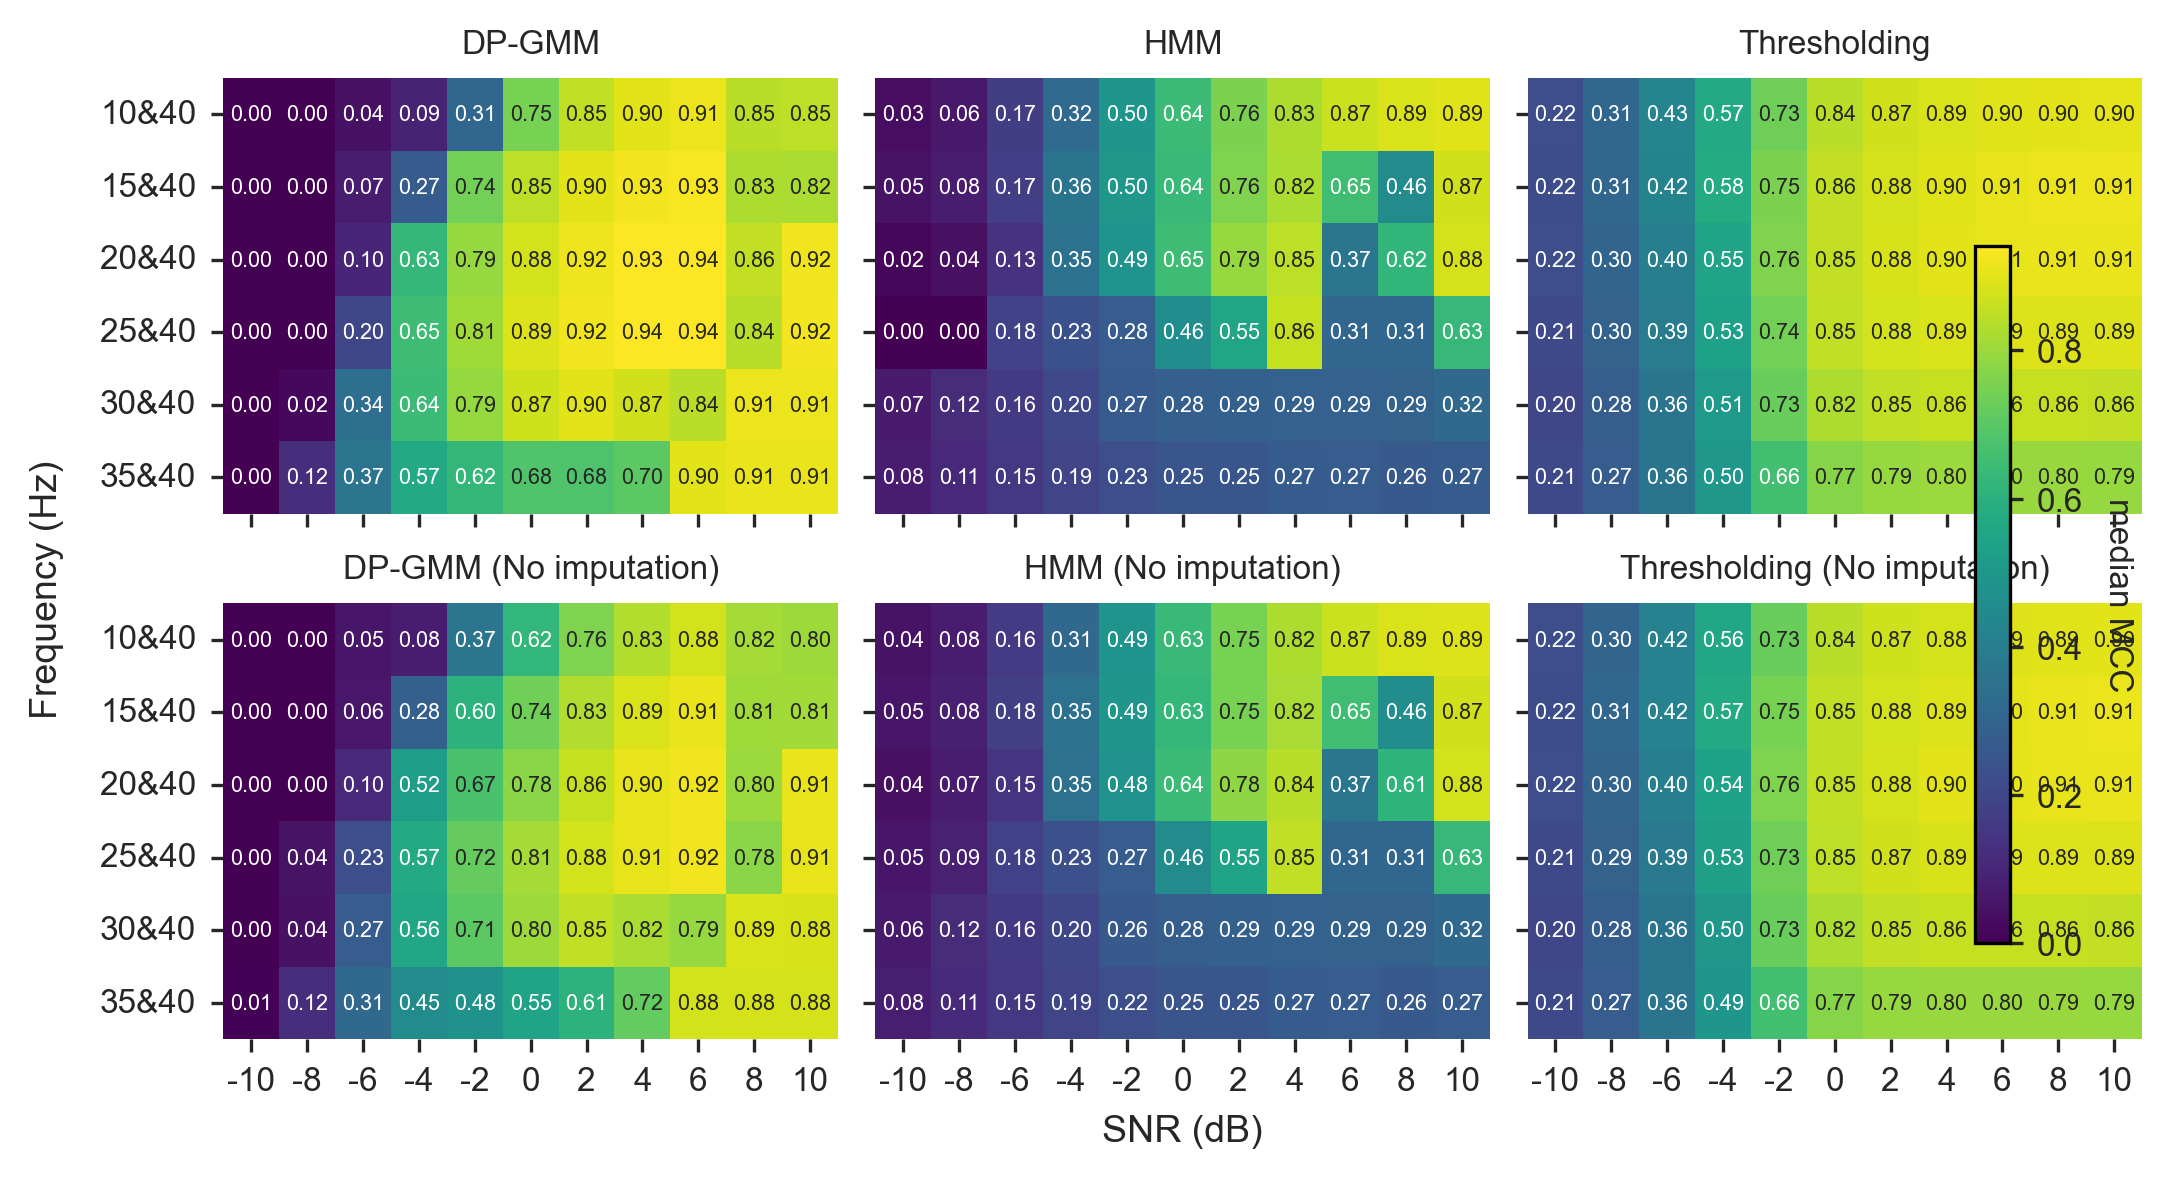

In [58]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator



method_names = set(df_3states.method.values)




aggfunc = "median"

dpgmm_heat = (df_3states.query("method == 'DP-GMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0)
        .sort_index(axis=1))

hmm_heat = (df_3states.query("method == 'HMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending



thresh_heat = (df_3states.query("method == 'Thresholding'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0) 
        .sort_index(axis=1))




dpgmm_imputed_heat = (df_3states.query("method == 'DP-GMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc = aggfunc)
        .sort_index(axis=0) 
        .sort_index(axis=1))


hmm_imputed_heat = (df_3states.query("method == 'HMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending


thresh_imputed_heat = (df_3states.query("method == 'Thresholding (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0) 
        .sort_index(axis=1))




mats = [
    dpgmm_heat, hmm_heat, thresh_heat,
    dpgmm_imputed_heat, hmm_imputed_heat, thresh_imputed_heat
]

vmin = np.nanmin([m.to_numpy() for m in mats])
vmax = np.nanmax([m.to_numpy() for m in mats])




common = dict(
    annot=True, fmt=".2f", annot_kws={"size": 5.2},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=False
)


fig, ax = plt.subplots(2, 3, figsize=(FIG_WIDTH, 4), sharex=True, sharey=True)

sns.heatmap(dpgmm_imputed_heat, **common, ax=ax[0,0])
ax[0,0].set_title("DP-GMM")

sns.heatmap(hmm_imputed_heat, **common, ax=ax[0,1])
ax[0,1].set_title("HMM")

sns.heatmap(thresh_imputed_heat, **common, ax=ax[0,2])
ax[0,2].set_title("Thresholding")

sns.heatmap(dpgmm_heat, **common, ax=ax[1,0])
ax[1,0].xaxis.set_major_locator(MaxNLocator(6))
ax[1,0].set_title("DP-GMM (No imputation)")

sns.heatmap(hmm_heat, **common, ax=ax[1,1])
ax[1,1].set_title("HMM (No imputation)")

sns.heatmap(thresh_heat, **common, ax=ax[1,2])
ax[1,2].set_title("Thresholding (No imputation)")






sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), fraction=0.02, pad=-0.05)
cbar.set_label("median MCC",  rotation=270, labelpad=12)




for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")
    

fig.supylabel("Frequency (Hz)", fontsize = MY_FONT_SIZE)

ax[1,1].set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)


plt.tight_layout()

fig.savefig(
    f"../figures/raw_figure/{sim_cond}heatmaps.jpg",
    bbox_inches="tight"
)





In [59]:


gmm_df_3states["num_states_active"] = [gmm_df_3states.iloc[i]["est_params"]["num_states_active"] for i in range(len(gmm_df_3states))]



KeyError: 'num_states_active'

In [60]:
mask = gmm_df_3states["method"].eq("DP-GMM (Imputed)")

gmm_df_3states[mask]["num_states_active"] = [len(np.unique(gmm_df_3states[mask].iloc[i]["est_states"])) for i in range(len(gmm_df_3states[mask]))]

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_11814/3519516940.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gmm_df_3states[mask]["num_states_active"] = [len(np.unique(gmm_df_3states[mask].iloc[i]["est_states"])) for i in range(len(gmm_df_3states[mask]))]


In [61]:
mask = gmm_df_3states["snr"].eq(6)
mask2 = gmm_df_3states["num_emb"].eq(21)

gmm_df_3states[mask&mask2]

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,num_states_active
60,DP-GMM,"[1.2393711941918713, 0.3243226162268218, 0.357...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 2.0616415, 'weights': [0.8235996, 0....",0.73337406,1,454024514,...,0.060034,404.542927,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.928915,0.73337406,NaN
61,DP-GMM (Imputed),"[1.2393711941918713, 0.3243226162268218, 0.357...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 2.0616415, 'weights': [0.8235996, 0....",0.73337406,1,454024514,...,0.060034,404.542927,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.952584,0.73337406,NaN
82,DP-GMM,"[0.10905186967612718, -0.2290912658311745, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 0.7491737, 'weights': [0.8471011, 0....",0.74339354,0,479243620,...,0.058909,387.253812,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.924589,0.74339354,NaN
83,DP-GMM (Imputed),"[0.10905186967612718, -0.2290912658311745, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 0.7491737, 'weights': [0.8471011, 0....",0.74339354,0,479243620,...,0.058909,387.253812,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.945495,0.74339354,NaN
192,DP-GMM,"[1.695724438812263, 1.9452236553539708, 1.6627...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 0.8068774, 'weights': [0.69458103, 0...",0.77862346,8,3476387030,...,0.057801,408.335245,11,21,"[0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 3, 2]",None,0.859188,0.77862346,NaN
193,DP-GMM (Imputed),"[1.695724438812263, 1.9452236553539708, 1.6627...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 0.8068774, 'weights': [0.69458103, 0...",0.77862346,8,3476387030,...,0.057801,408.335245,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 3, 2]",None,0.932411,0.77862346,NaN
214,DP-GMM,"[0.09486484100486368, -0.313977835199126, 0.70...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 2.8312588, 'weights': [0.89348185, 0...",0.79359037,8,3476387030,...,0.057859,396.069711,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.921944,0.79359037,NaN
215,DP-GMM (Imputed),"[0.09486484100486368, -0.313977835199126, 0.70...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 2.8312588, 'weights': [0.89348185, 0...",0.79359037,8,3476387030,...,0.057859,396.069711,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.939774,0.79359037,NaN
324,DP-GMM,"[-0.386769407562338, 0.5008224365650035, 0.368...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 2.6204493, 'weights': [0.82073337, 0...",0.7643708,3,1994996016,...,0.062474,419.887781,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.927909,0.7643708,NaN
325,DP-GMM (Imputed),"[-0.386769407562338, 0.5008224365650035, 0.368...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 2.6204493, 'weights': [0.82073337, 0...",0.7643708,3,1994996016,...,0.062474,419.887781,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.948332,0.7643708,NaN


In [62]:
gmm_df_3states.iloc[457][

SyntaxError: incomplete input (537815817.py, line 1)

In [63]:
active_states_df = gmm_df_3states.groupby(["method", "snr"], as_index = False).agg(
    mean_active_states=("num_states_active", "median"),
)


mask = gmm_df_3states["method"].eq("DP-GMM")


active_states_df = gmm_df_3states[mask].groupby(["snr"], as_index = False).agg(
    mean_active_states=("num_states_active", "median"),
)

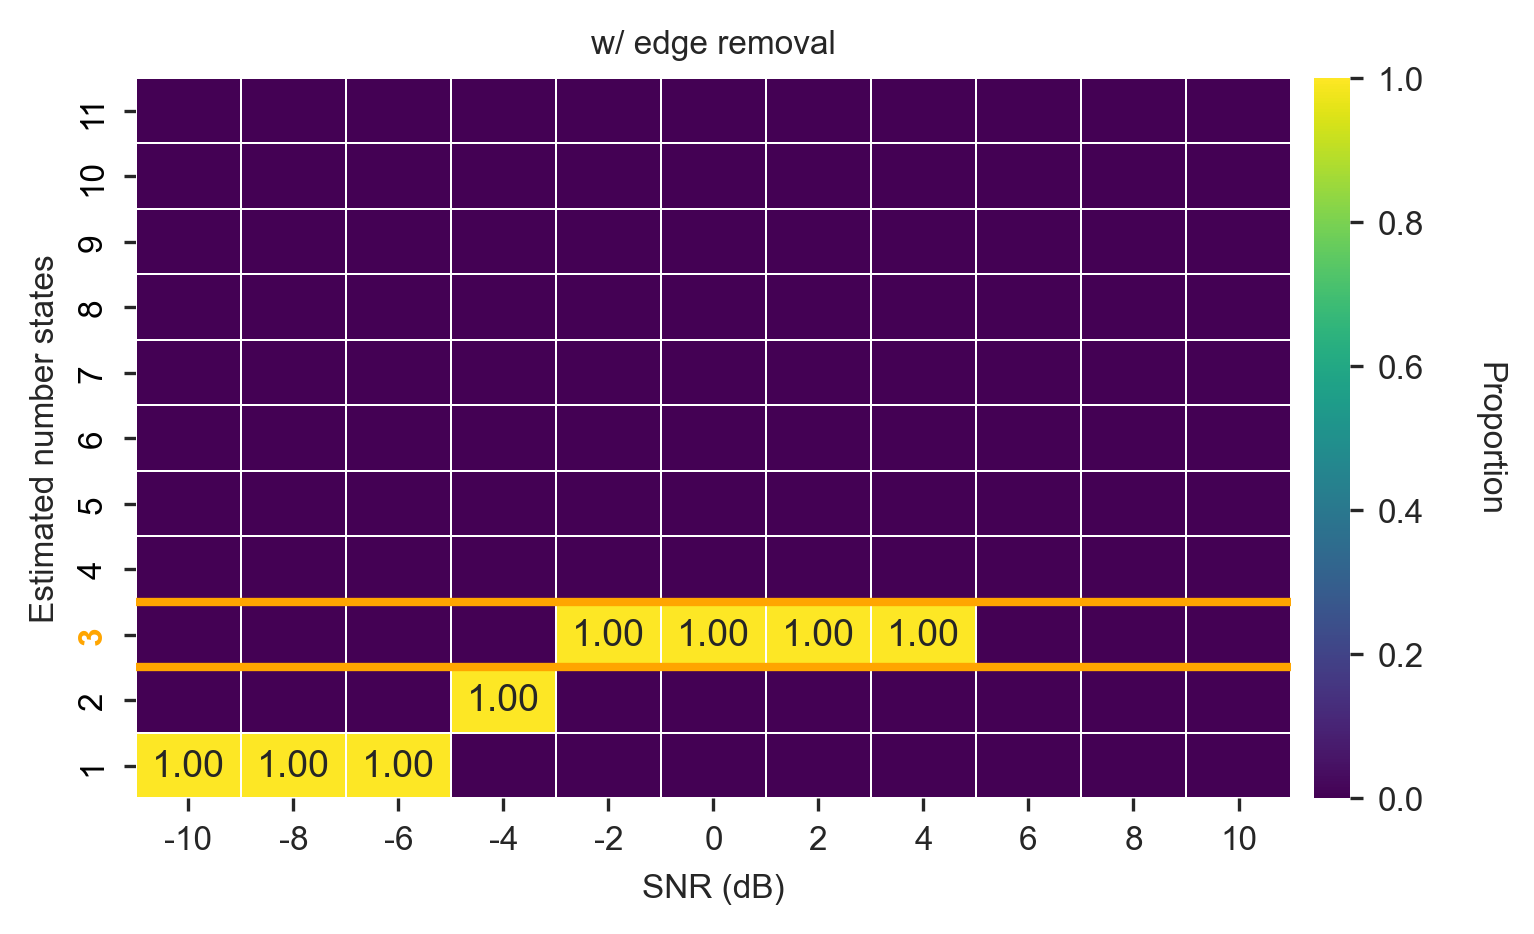

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# settings
# =========================================================
ground_truth_active_states = 3
state_range = np.arange(1, 12)

# =========================================================
# prepare data
# =========================================================
df = gmm_df_3states.copy()
df["active_states_plot"] = df["num_states_active"]

heat_df = (
    df.groupby(["active_states_plot", "snr"])
      .size()
      .reset_index(name="count")
)

heat_df["prop"] = (
    heat_df.groupby("snr")["count"]
           .transform(lambda x: x / x.sum())
)

snr_range = sorted(df["snr"].unique())

heat_mat = (
    heat_df.pivot(index="active_states_plot", columns="snr", values="prop")
           .reindex(index=state_range, columns=snr_range)
           .fillna(0)
           .sort_index(ascending=False)
)

# =========================================================
# annotation matrix: hide zeros
# =========================================================
annot_mat = heat_mat.copy().astype(object)
for i in range(annot_mat.shape[0]):
    for j in range(annot_mat.shape[1]):
        val = float(annot_mat.iat[i, j])
        annot_mat.iat[i, j] = "" if np.isclose(val, 0) else f"{val:.2f}"

# =========================================================
# plot
# =========================================================
fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)

hm = sns.heatmap(
    heat_mat,
    ax=ax,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=annot_mat,
    fmt="",
    linewidths=0.01,
    linecolor="white",
    cbar_kws={"pad": 0.02},
)

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Estimated number states")
ax.set_title("w/ edge removal")

# =========================================================
# highlight ground-truth row
# =========================================================
if ground_truth_active_states in heat_mat.index:
    gt_row = list(heat_mat.index).index(ground_truth_active_states)
    x0, x1 = ax.get_xlim()
    ax.hlines(gt_row, x0, x1, colors="orange", linewidth=2.)
    ax.hlines(gt_row + 1, x0, x1, colors="orange", linewidth=2.)

# =========================================================
# color the y-tick label for the ground-truth state
# =========================================================
for tick in ax.get_yticklabels():
    if tick.get_text() == str(ground_truth_active_states):
        tick.set_color("orange")
        tick.set_fontweight("bold")
    else:
        tick.set_color("black")
        tick.set_fontweight("normal")

# =========================================================
# colorbar label
# =========================================================
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(length=3, width=0.8)
cbar.ax.set_ylabel("Proportion", rotation=270, va="bottom", labelpad=12)

plt.show()

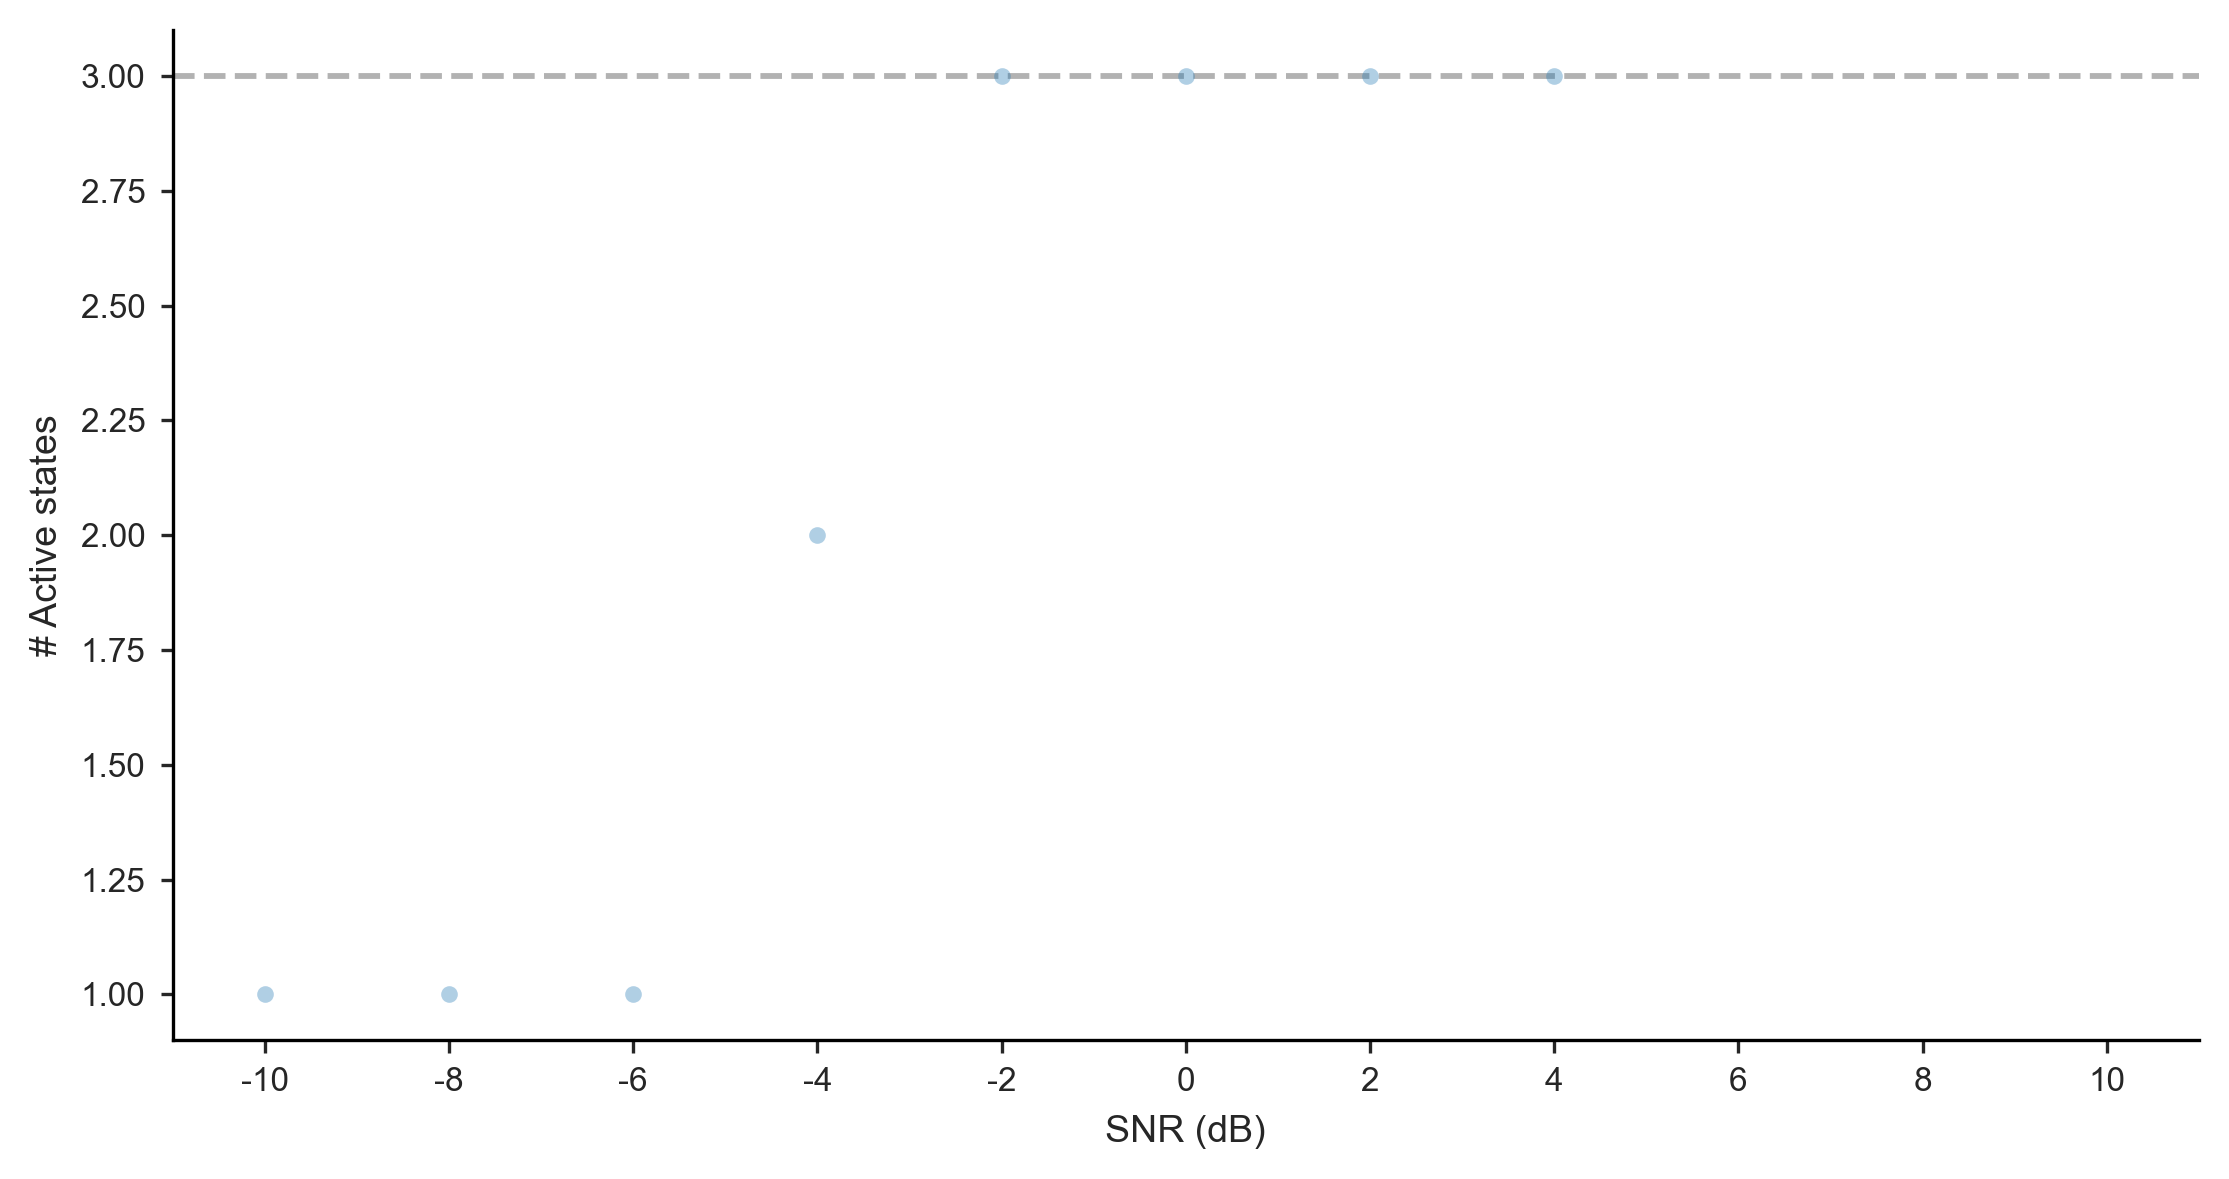

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(FIG_WIDTH,4))
ax = sns.swarmplot(
    data=gmm_df_3states.loc[mask],
    x="snr", y="num_states_active",
    size=4.0, alpha=0.35
)

ax.axhline(y=3, linestyle="--", linewidth=1.4, color = "black", alpha = 0.3)  # horizontal reference line

sns.despine(ax=ax)
ax.set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)
ax.set_ylabel("# Active states", fontsize = MY_FONT_SIZE)
plt.tight_layout()
plt.show()


In [66]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_states_active
0,HMM,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10&40,250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.056893,0.756168,1.0,NaN
1,HMM (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10&40,250,-10,"{'initial_probs': [0.32001477, 0.4240886, 0.25...",0.756168,NaN,NaN,...,160.470830,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.061085,0.756168,1.0,NaN
2,Thresholding,"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10&40,250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.197054,"[[0.30000000000000004, 0.30000000000000004], [...",NaN,NaN
3,Thresholding (Imputed),"[-1.425042998688219, -0.6467064557674178, 0.65...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10&40,250,-10,"{'enveloped_signal': [[0.40243578, 0.405917, 0...",NaN,NaN,NaN,...,1.373550,3,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.198073,"[[0.30000000000000004, 0.30000000000000004], [...",NaN,NaN
4,HMM,"[-1.4194751248175188, -0.6442518238696098, 0.6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10&40,250,-8,"{'initial_probs': [0.27990672, 0.40751556, 0.3...",0.756446,NaN,NaN,...,185.553713,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.073450,0.756446,6.0,NaN


In [67]:
plot_f = "20&40"

In [68]:
df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index=False)
    .agg(
        mcc_median=("mcc", "median"),
        mcc_q25=("mcc", lambda x: x.quantile(0.25)),
        mcc_q75=("mcc", lambda x: x.quantile(0.75)),
    )
)

df_avg["mcc_err_low"] = df_avg["mcc_median"] - df_avg["mcc_q25"]
df_avg["mcc_err_high"] = df_avg["mcc_q75"] - df_avg["mcc_median"]

In [69]:
df_avg

,method,snr,mcc_median,mcc_q25,mcc_q75,mcc_err_low,mcc_err_high
0,DP-GMM,-10,0.000000,0.000000,0.000000,0.000000,0.000000
1,DP-GMM,-8,0.000000,0.000000,0.065027,0.000000,0.065027
2,DP-GMM,-6,0.103167,0.093690,0.154301,0.009477,0.051134
3,DP-GMM,-4,0.521578,0.499612,0.534227,0.021966,0.012649
4,DP-GMM,-2,0.669945,0.662980,0.681283,0.006964,0.011339
...,...,...,...,...,...,...,...
61,Thresholding (Imputed),2,0.884054,0.880241,0.892528,0.003813,0.008474
62,Thresholding (Imputed),4,0.899927,0.896478,0.903313,0.003449,0.003386
63,Thresholding (Imputed),6,0.905632,0.901934,0.909329,0.003698,0.003696
64,Thresholding (Imputed),8,0.908701,0.903475,0.911068,0.005226,0.002367


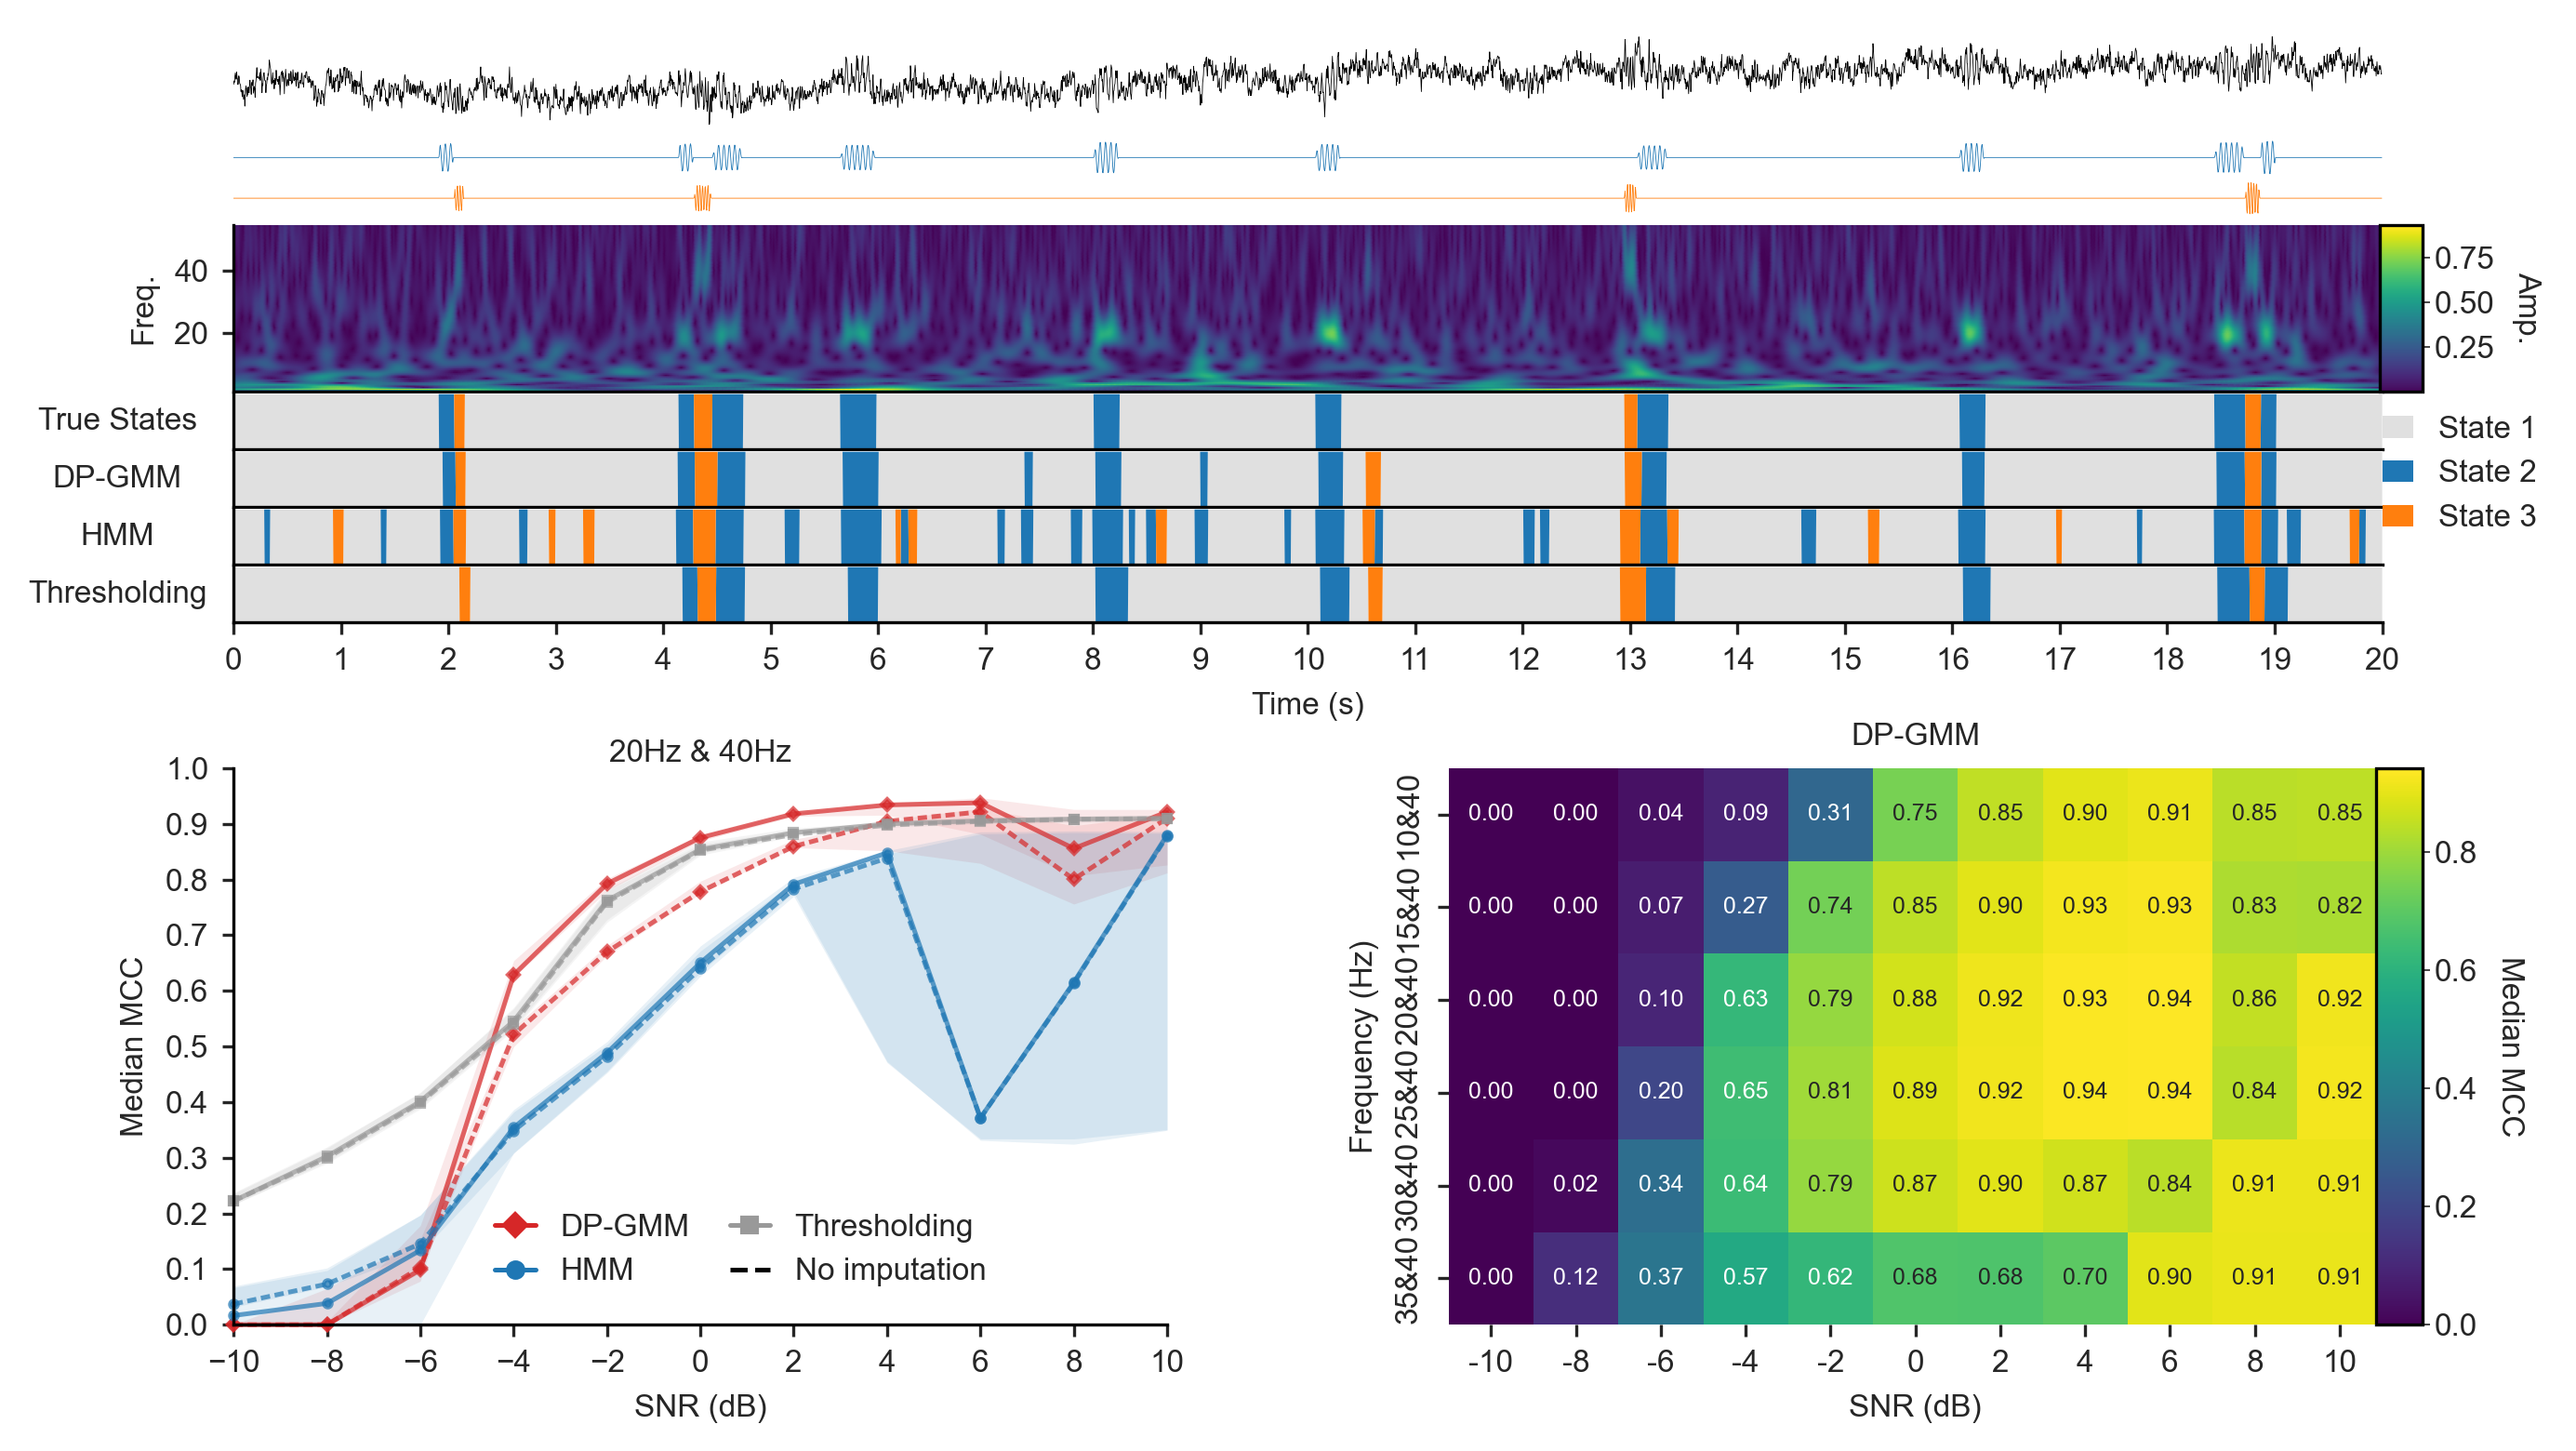

In [70]:

plt.close("all")

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],
          ["a", "c"]
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH+1, 5),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2, 0.2,0.2,2]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)




thresh_color = "#999999" # grey
hmm_color   = "#1f77b4"  # vivid blue
dpgmm_color   = "#d62728"

palette = {
    "Thresholding":                 thresh_color,
    "Thresholding (Imputed)":     thresh_color,
    "HMM":                   hmm_color,
    "HMM (Imputed)":       hmm_color,
    "DP-GMM":                 dpgmm_color,
    "DP-GMM (Imputed)":     dpgmm_color,
}

dashes = {
    "Thresholding":               (2, 1),      # dashed
    "Thresholding (Imputed)":   (None, None),# solid
    "HMM":                 (2, 1),
    "HMM (Imputed)":     (None, None),
    "DP-GMM":               (2, 1),
    "DP-GMM (Imputed)":   (None, None),
}

markers = {
    "Thresholding":               "s",   # square
    "Thresholding (Imputed)":   "s",
    "HMM":                 "o",   # circle
    "HMM (Imputed)":     "o",
    "DP-GMM":               "D",   # diamond
    "DP-GMM (Imputed)":   "D",
}


handles_left = [
    Line2D([0], [0], color=dpgmm_color, marker="D", lw=1.2, ms=4, linestyle="-", label="DP-GMM"),
    Line2D([0], [0], color=hmm_color, marker="o", lw=1.2, ms=4, linestyle="-", label="HMM"),
    Line2D([0], [0], color=thresh_color, marker="s", lw=1.2, ms=4, linestyle="-", label="Thresholding"),
]

handles_right = [
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="No imputation")  # dashed example
]
handles = handles_left + handles_right
labels  = [h.get_label() for h in handles]

axes["a"].legend(
    handles, labels,
    ncols=2,
    loc="best",  # or adjust position
    frameon=False,
    bbox_to_anchor=(0.25, 0.25),
    columnspacing=1.3,
    handlelength=1.3
)



for method in df_avg["method"].unique():
    df_sub = df_avg[df_avg["method"] == method]
    label = method.replace("_", " ")
    axes["a"].plot(
        df_sub["snr"], df_sub["mcc_median"],
        label=label,
        color=palette[method],
        marker=markers[method],
        linestyle='-' if dashes[method] == (None, None) else (0, dashes[method]),
        lw=1.2, ms=2, alpha=0.7, clip_on=False
    )

    # Shaded Q1–Q3 band
    axes["a"].fill_between(
        df_sub["snr"],
        df_sub["mcc_q25"],
        df_sub["mcc_q75"],
        color=palette[method],
        alpha=0.1, clip_on=True,
        linewidth=0
    )

axes["a"].set_xticks(snr_range)
axes["a"].set_xlim(min(snr_range), max(snr_range))
axes["a"].set_ylim(0, 1)
axes["a"].yaxis.set_major_locator(MultipleLocator(0.1))
#axes["a"].yaxis.set_minor_locator(MultipleLocator(0.05))
#axes["a"].grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
axes["a"].set_xlabel("SNR (dB)")
axes["a"].set_ylabel("Median MCC")
#axes["a"].set_title(f"{plot_f[0]} Hz & {plot_f[1]} Hz",pad = 0.3)
axes["a"].set_title(f"20Hz & 40Hz",pad = 0.3)




axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame


#axes["a"].tick_params(direction='in', length=3, width=0.4, bottom=True, left=True)

cax_heat = inset_axes(
    axes["c"],
    width="5%", height="100%",
    loc="center right",
    borderpad=-1.3
)

sns.heatmap(
    dpgmm_imputed_heat,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=True, cbar_ax=cax_heat,
    ax=axes["c"]
)


cbar = axes["c"].collections[0].colorbar
cbar.set_label("Median MCC", rotation=270, labelpad=12)
cbar.ax.tick_params(which="both", length=2, width=0.4, pad=1)
cbar.outline.set_visible(True)
cbar.outline.set_linewidth(0.8)

axes["c"].set_title("DP-GMM")
axes["c"].set_xlabel("SNR (dB)")
axes["c"].set_ylabel("Frequency (Hz)")






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",
           bbox_to_anchor=(0.981, 0.68), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)



cb.solids.set_edgecolor("face")
cbar.solids.set_edgecolor("face")


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.jpg",
    bbox_inches="tight"
)





## performance before imputation

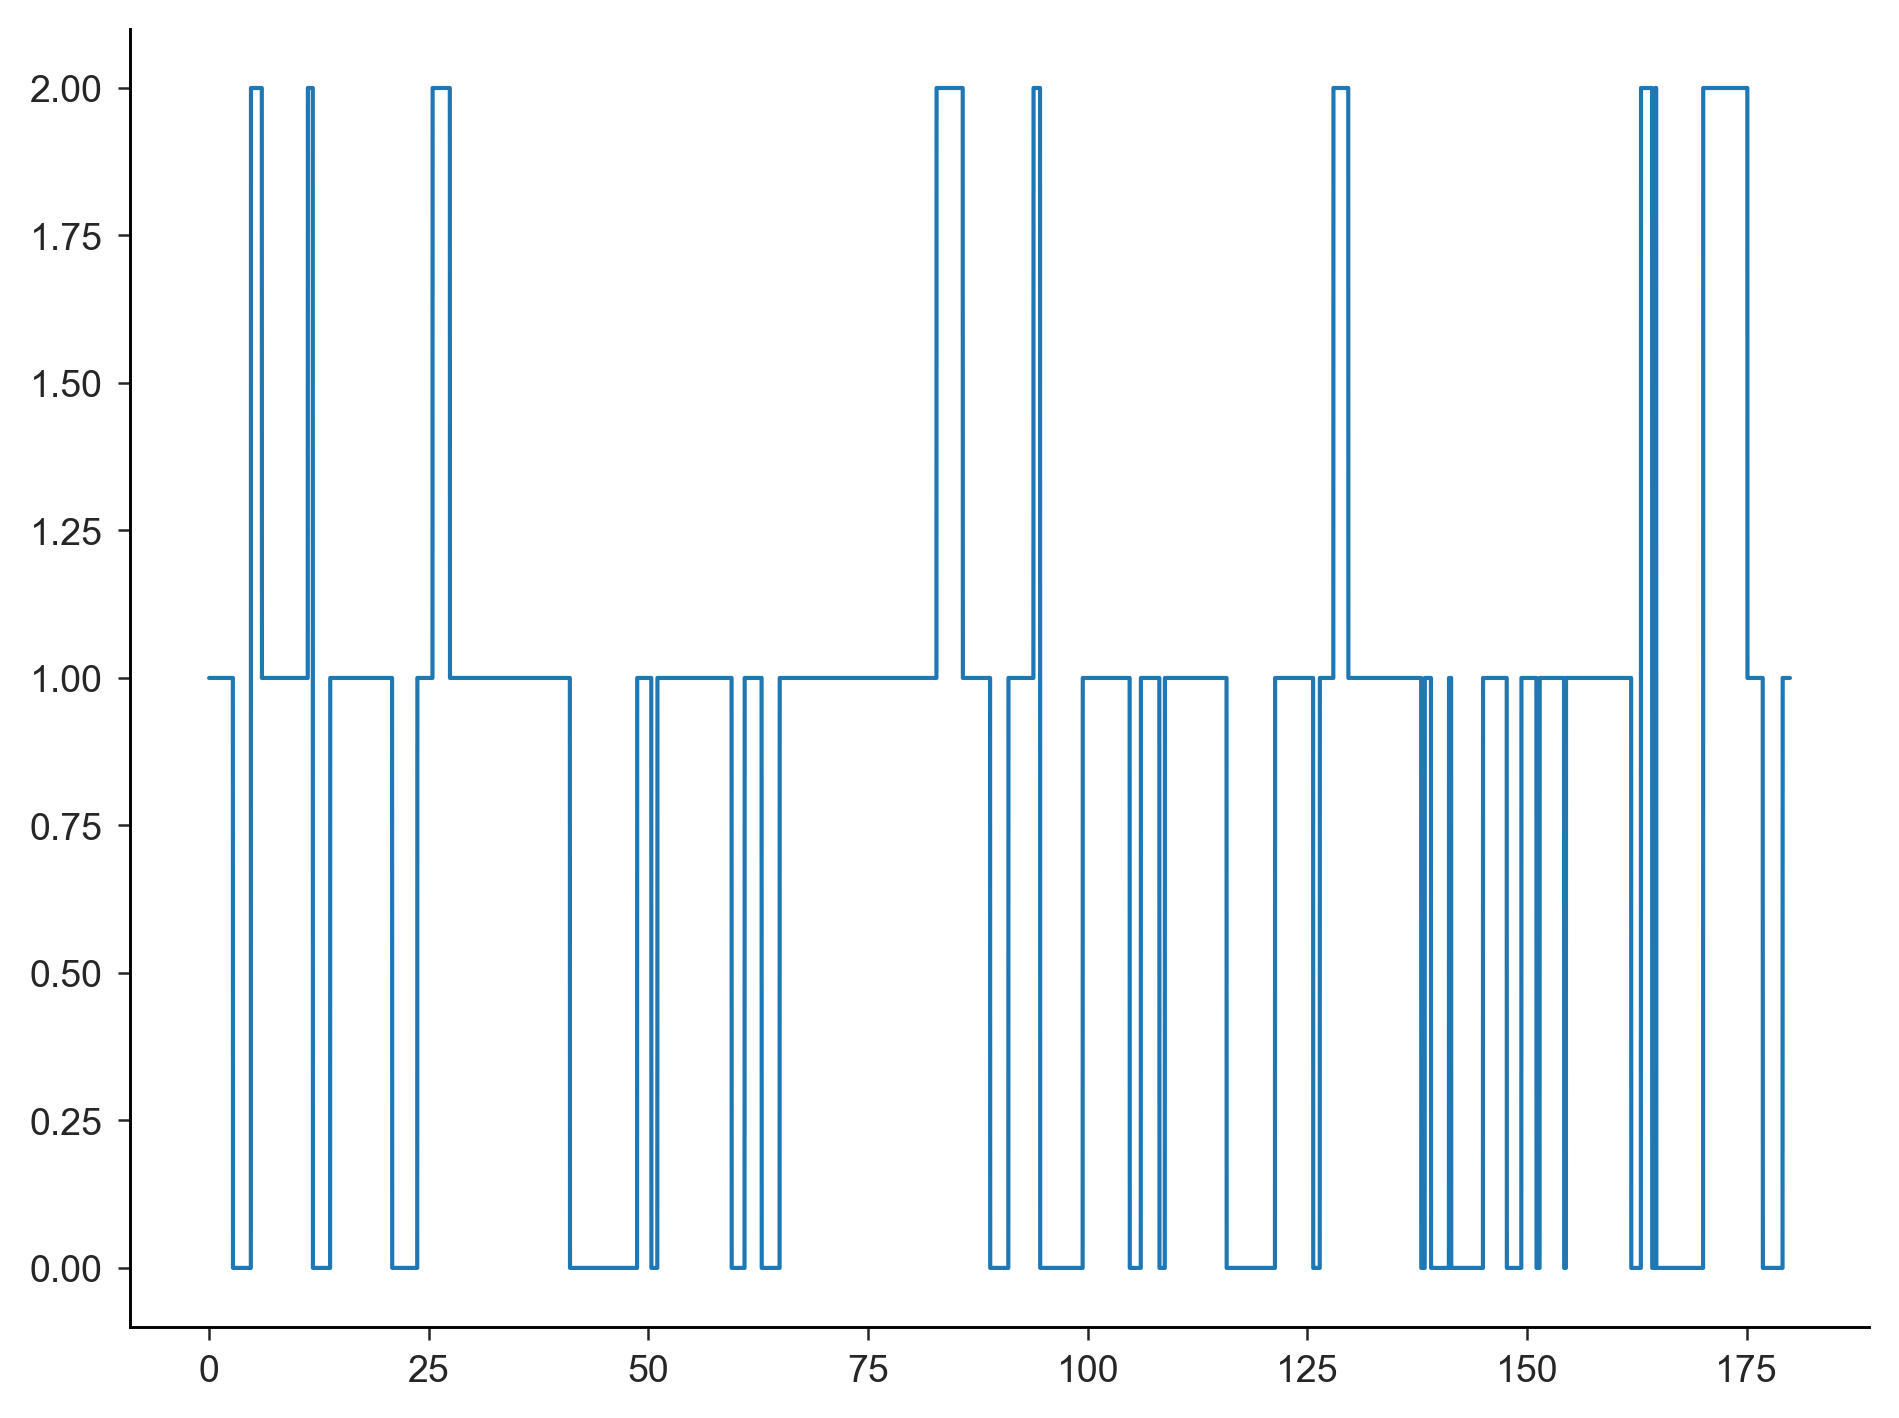

In [62]:
plt.plot(trimmed_time_vec, dpgmm_states)

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(44980, 3))

In [65]:


dpgmm_res = gmm_df_3states.iloc[sample_id]
hmm_res = res.query("method == 'HMM'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding'").iloc[sample_id]


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states+1)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]



IndexError: single positional indexer is out-of-bounds

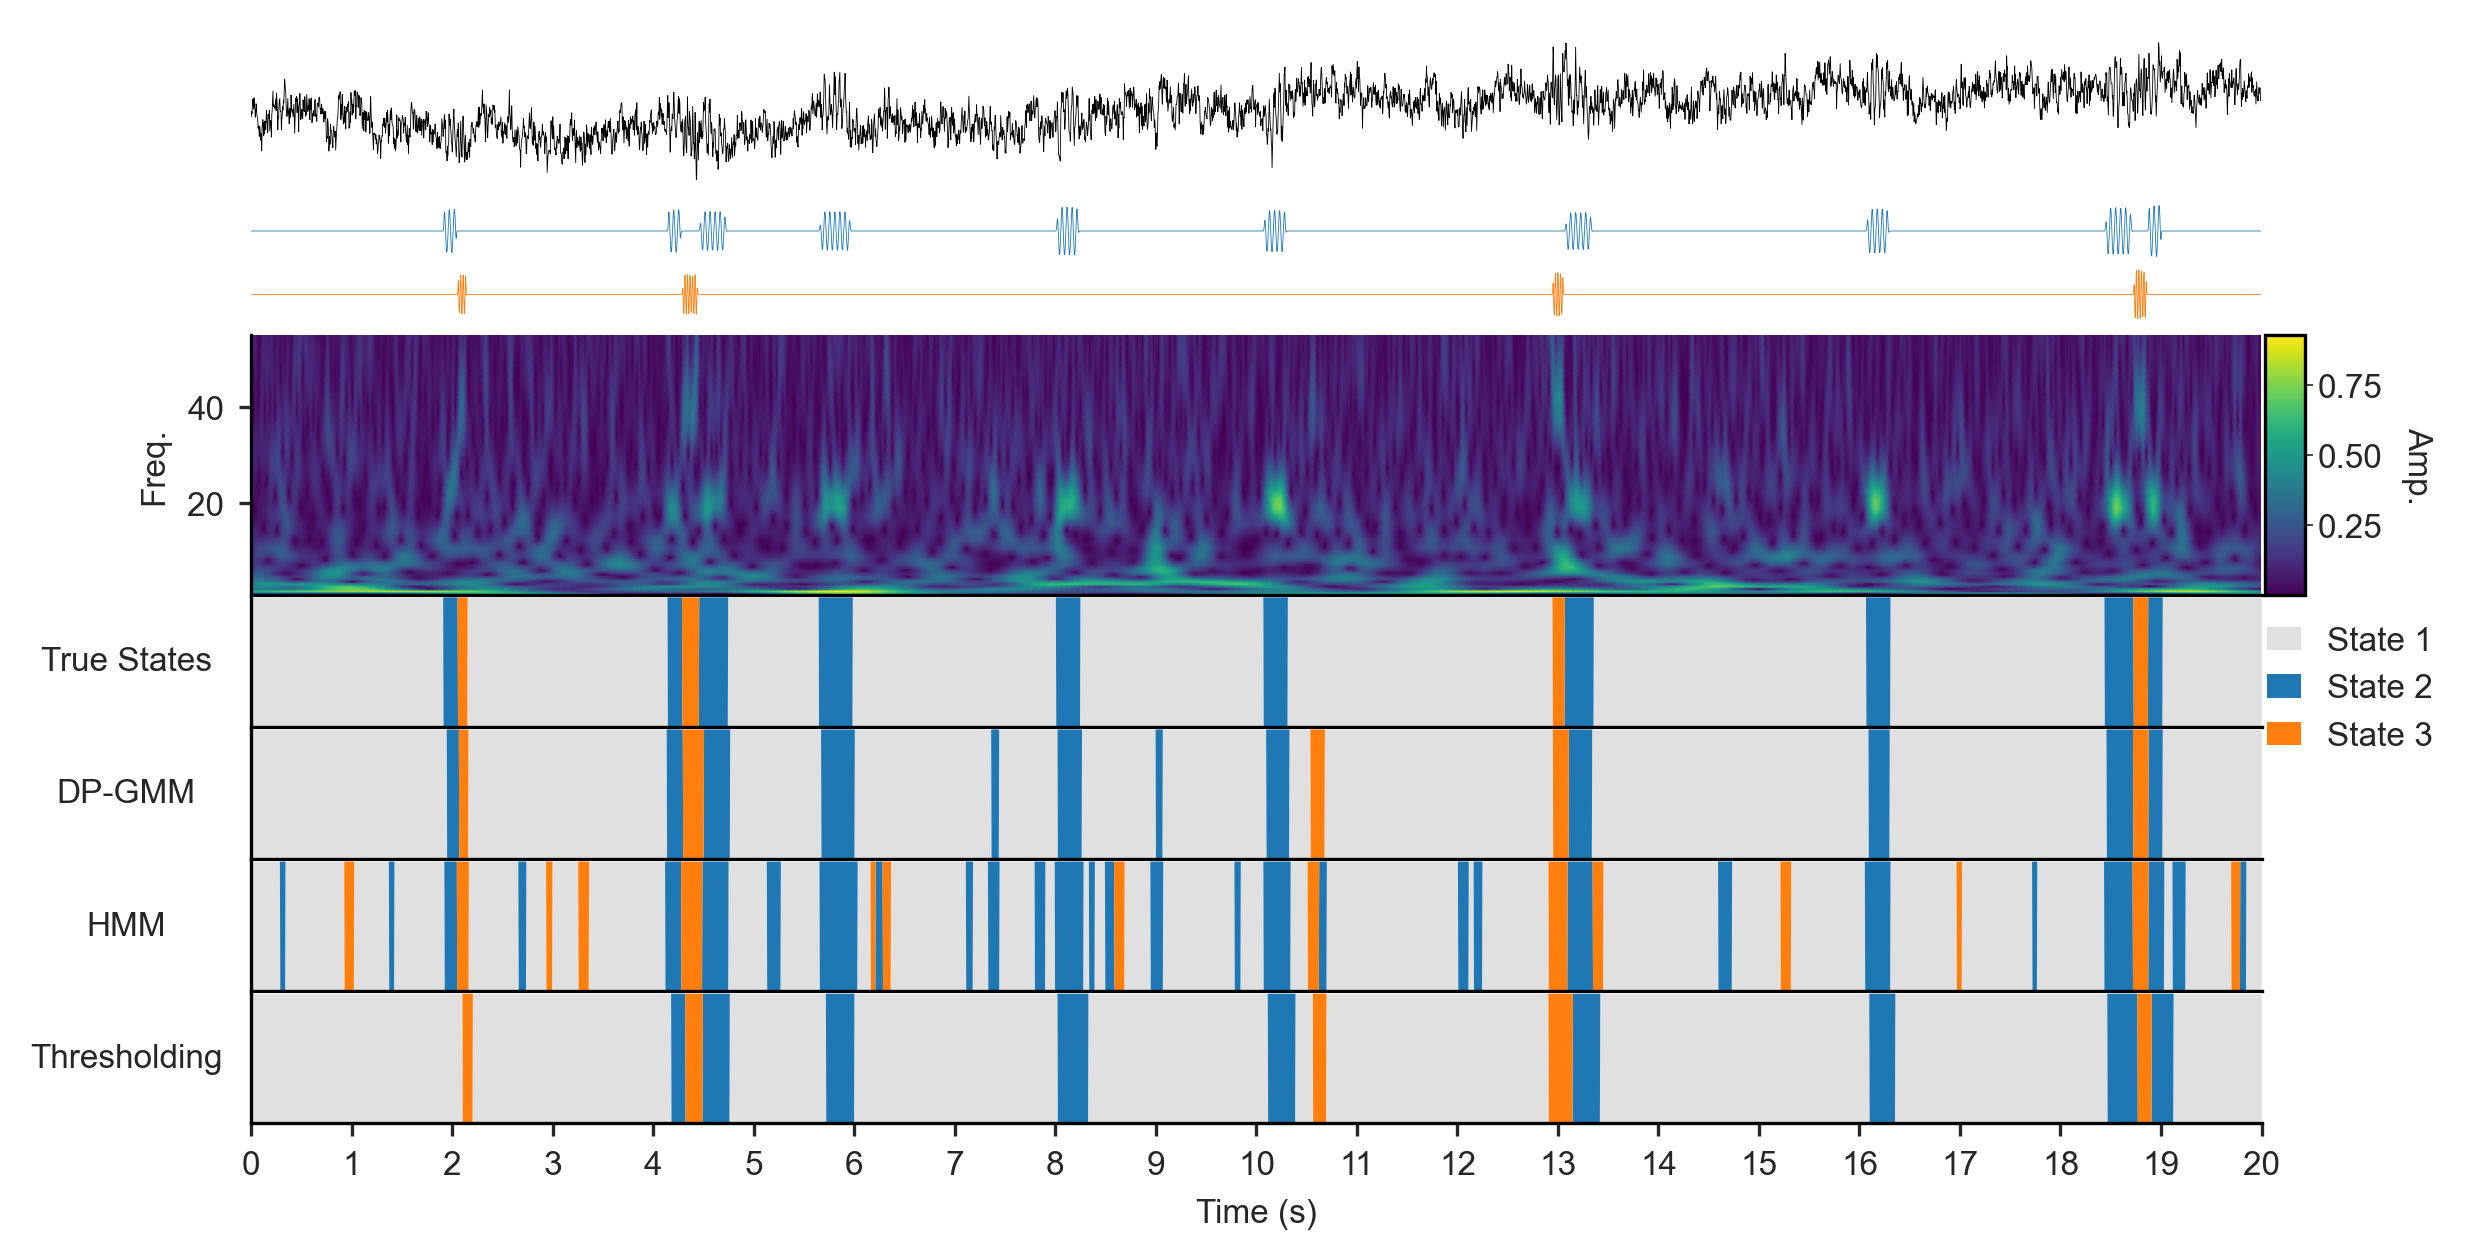

In [71]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],

         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3, 0.3, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.981, 0.45), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight"
)





In [67]:

res

method  \
62             DP-GMM   
63   DP-GMM (Imputed)   
194            DP-GMM   
195  DP-GMM (Imputed)   
326            DP-GMM   
327  DP-GMM (Imputed)   
458            DP-GMM   
459  DP-GMM (Imputed)   
590            DP-GMM   
591  DP-GMM (Imputed)   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  signal  \
62                                                                [0.4461500710402967, 0.9529588356014878, 0.6376619197232218, 0.6637386280400106, 2.7234632255232145, 1.85231855623935, 1.5849083314406016, 0.15856951080403506, -0.7414820538531043, -1.993919237615581, -2.278419808693767, -2.109519914866006, -0.10862549620654671, 0.8164396731309239, 2.1517672841139786, 3.4885943831031323, 3.2545436076313923, 2.8007086047142553, 2.0955603319297573, 0.6018378258564503, -0.7945299882459522, -1.9329067529738135, -2.1436613075710262, -1.0174747526721055, -0.3892173524031765, 0.5870126999481283, 2.5420545796016145, 3.088657479987482, 4.27401412285151, 4.375544879036447, 2.8624404407973616, 2.267509045639924, -0.19287880571959384, -0.7317507924220615, -2.0812953304106987, -2.1988724255917345, -1.1980155931978904, 0.18490350805621325, 2.155295219917692, 2.9890281909537135, 3.8549230524696156, 3.8424631731072685, 2.9006459399689897, 2.3187840737440917, 0.2599171865085428, -1.2785136336286227, -2.293982672004147, -2.7100091695385804, -2.161217142151155, -1.1702437371961552, 0.12264254227206293, 1.9524751397324327, 3.612124511256485, 4.214686458448872, 2.8311284768247353, 2.5448345675112107, 0.559872563273824, -0.9714980101930513, -2.185096069939988, -2.712259983345861, -2.7368147072419284, -2.051464391551979, -0.09760101912215115, 1.546289233138279, 3.049633097508964, 3.5486834140324395, 3.1187876128559147, 2.3841046475778063, 1.2489213707030709, 0.019790891745000167, -0.960070349961181, -2.2595860712491933, -2.351275317946822, -2.046487373033903, -0.8767552873578596, 0.3707177986198514, 1.5275868303254527, 2.1294397

In [56]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,HMM,"[0.35698753167245767, 0.1324410290675029, 0.49...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.27514318, 0.39301887, 0.3...",0.724845,NaN,NaN,...,0.088267,81.070495,3,25,"[2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, ...","[1, 2, 0]",None,0.023617,0.724845,9.0
1,HMM (Imputed),"[0.35698753167245767, 0.1324410290675029, 0.49...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.33183795, 0.27514318, 0.3...",0.724845,NaN,NaN,...,0.088267,81.070495,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.000000,0.724845,9.0
2,Thresholding,"[0.35698753167245767, 0.1324410290675029, 0.49...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.23980206, 0.24261962, ...",NaN,NaN,NaN,...,0.001808,1.390413,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.125543,"[[0.5, 0.4], [0.4, 0.30000000000000004]]",NaN
3,Thresholding (Imputed),"[0.35698753167245767, 0.1324410290675029, 0.49...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.23980206, 0.24261962, ...",NaN,NaN,NaN,...,0.001808,1.390413,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.127367,"[[0.5, 0.4], [0.4, 0.30000000000000004]]",NaN
4,HMM,"[-0.34525068550435095, 0.03539207537988161, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10&40,250,-8,"{'initial_probs': [0.3922782, 0.29441473, 0.31...",0.651161,NaN,NaN,...,0.000571,69.471388,3,25,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, ...","[2, 0, 1]",None,0.040556,0.651161,0.0


In [57]:
res

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
108,HMM,"[0.01083351283506138, 0.4466687801298719, 0.39...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.39461723, 0.19793338, 0.4...",0.827298,NaN,NaN,...,0.000376,64.479100,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[2, 0, 1]",None,0.239865,0.827298,6.0
109,HMM (Imputed),"[0.01083351283506138, 0.4466687801298719, 0.39...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.39461723, 0.19793338, 0.4...",0.827298,NaN,NaN,...,0.000376,64.479100,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[2, 0, 1]",None,0.243408,0.827298,6.0
110,Thresholding,"[0.01083351283506138, 0.4466687801298719, 0.39...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'envelped_signal': [[0.11375438, 0.10771865, ...",NaN,NaN,NaN,...,0.000772,1.183852,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.807155,"[[1.8, 1.6], [1.8, 1.7000000000000002]]",NaN
111,Thresholding (Imputed),"[0.01083351283506138, 0.4466687801298719, 0.39...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'envelped_signal': [[0.11375438, 0.10771865, ...",NaN,NaN,NaN,...,0.000772,1.183852,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.807155,"[[1.8, 1.6], [1.8, 1.7000000000000002]]",NaN
372,HMM,"[-1.9097850283163706, -1.8386808417197644, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'initial_probs': [0.612162, 0.22882254, 0.159...",0.760433,NaN,NaN,...,0.000407,69.410175,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.173935,0.760433,6.0
373,HMM (Imputed),"[-1.9097850283163706, -1.8386808417197644, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'initial_probs': [0.612162, 0.15901546, 0.228...",0.760433,NaN,NaN,...,0.000407,69.410175,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 2, 1]",None,0.192001,0.760433,6.0
374,Thresholding,"[-1.9097850283163706, -1.8386808417197644, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'envelped_signal': [[0.6578381, 0.67864805, 0...",NaN,NaN,NaN,...,0.000802,1.221568,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.816226,"[[2.0, 1.9000000000000001], [1.8, 1.7000000000...",NaN
375,Thresholding (Imputed),"[-1.9097850283163706, -1.8386808417197644, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'envelped_signal': [[0.6578381, 0.67864805, 0...",NaN,NaN,NaN,...,0.000802,1.221568,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.817087,"[[2.0, 1.9000000000000001], [1.8, 1.7000000000...",NaN
636,HMM,"[-0.477042886685132, -0.7724946953054691, -1.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.53458077, 0.35541508, 0.1...",0.73136,NaN,NaN,...,0.000406,63.804892,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...","[2, 0, 1]",None,0.158019,0.73136,8.0
637,HMM (Imputed),"[-0.477042886685132, -0.7724946953054691, -1.0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.53458077, 0.35541508, 0.1...",0.73136,NaN,NaN,...,0.000406,63.804892,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...","[2, 0, 1]",None,0.158844,0.73136,8.0


In [68]:
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB

num_states = 3
snr_db = 8
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 2

res = gmm_df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])

dpgmm_states =dpgmm_res.est_states
num_active_states = dpgmm_states.max()+1

dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_active_states)[dpgmm_states]

dpgmm_states_onehot[:, [2, 3]] = dpgmm_states_onehot[:, [3, 2]]



trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(4)[trimmed_states]

states_onehot[:, [2, 3]] = states_onehot[:, [3, 2]]

print("num_active_states", num_active_states)
print("mcc", dpgmm_mcc)


IndexError: index 3 is out of bounds for axis 1 with size 3

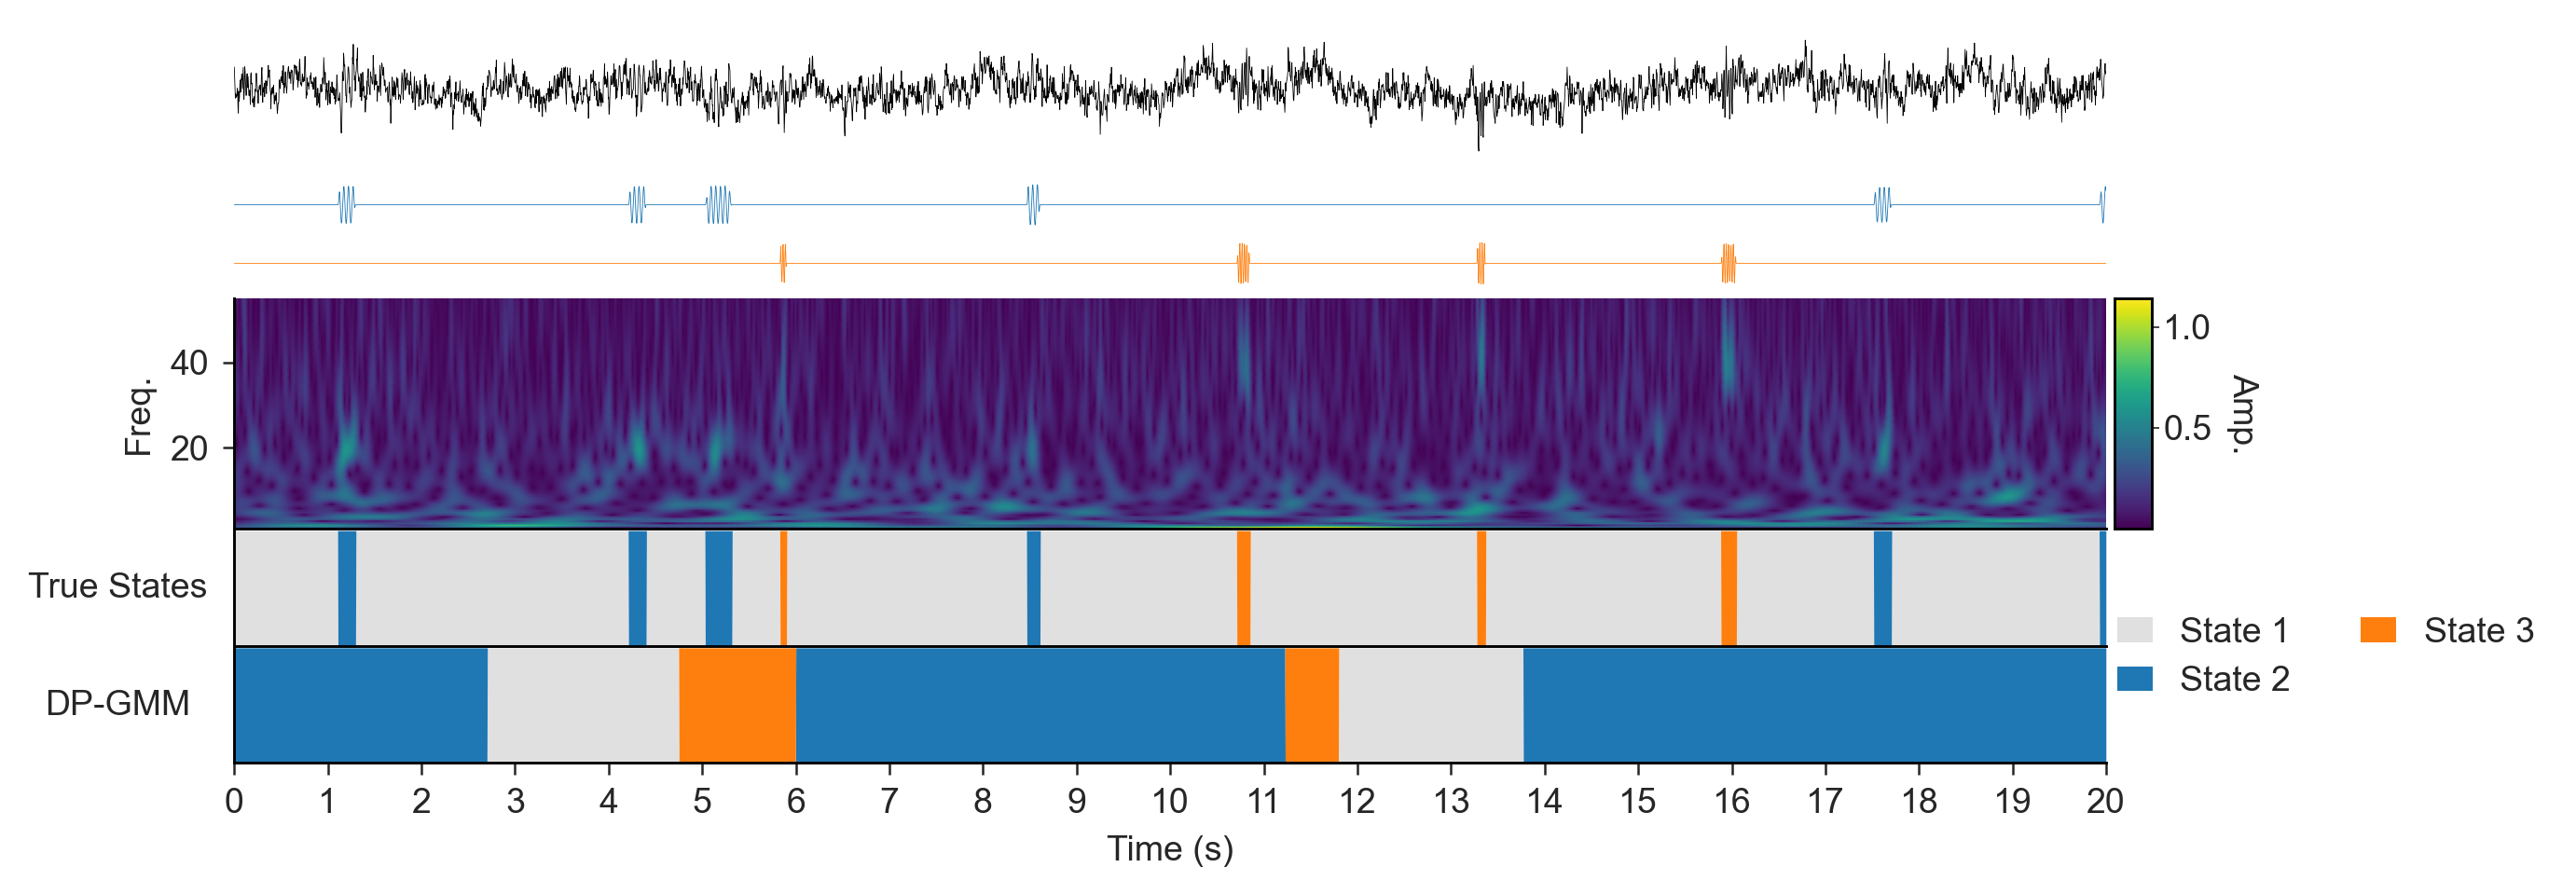

In [69]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_active_states)]
grey = ["#E0E0E0"]
colors = grey + colors



state_labels = [f"State {i+1}" for i in range(num_active_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 3),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(trimmed_signal[:plot_t*fs]), lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(-2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1], )
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(-3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"mcc = {dpgmm_mcc}")
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")




for key in ["b3"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)

for key in ["b1","b2", "b3", "b4"]:
    axes[key].sharex(axes["b1"])




axes["b4"].set_xlabel("Time (s)")
axes["b4"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b4"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b4"].set_ylim(0, 1)
axes["b4"].set_xlim(0, plot_t)


axes["b4"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b4"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           ncol = 2,
           bbox_to_anchor=(0.981, 0.25), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)







/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


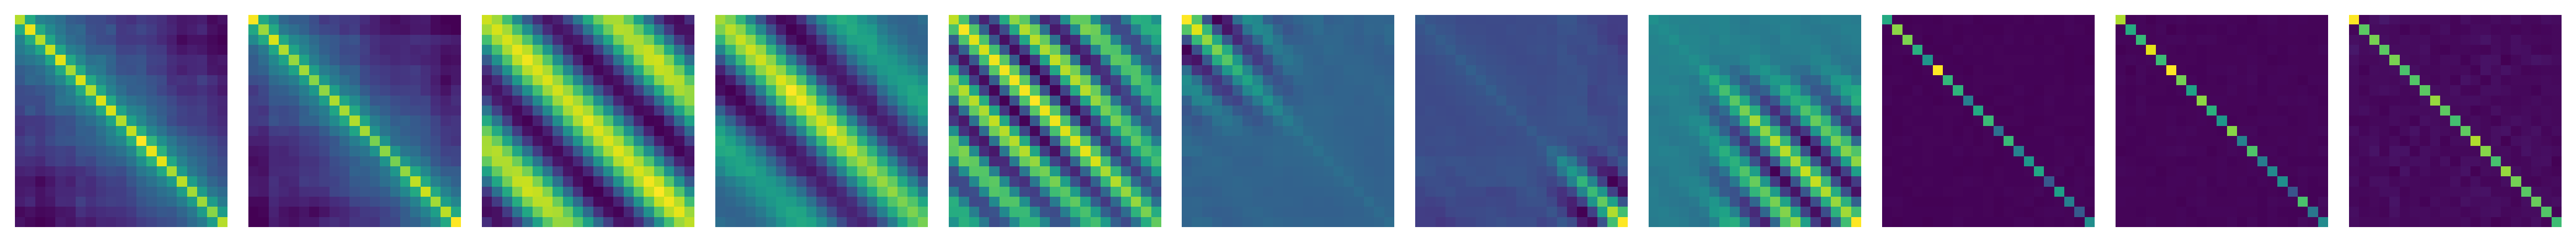

In [70]:

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_active_states)]
grey = ["#E0E0E0"]
colors = grey + colors

covs = dpgmm_res["est_params"]["covs"]
untrunc_covs = dpgmm_res["est_params"]["untrunc_covs"]
untrunc_weights = dpgmm_res["est_params"]["untrunc_weights"]


fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(untrunc_covs):
    ax[i].imshow(cov,  cmap = "viridis")
    ax[i].set_axis_off()

dim_vec = np.arange(-num_emb//2+1, num_emb//2+1)


In [71]:
num_states

3

In [72]:
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(11)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(1)]

print(len(colors))

12


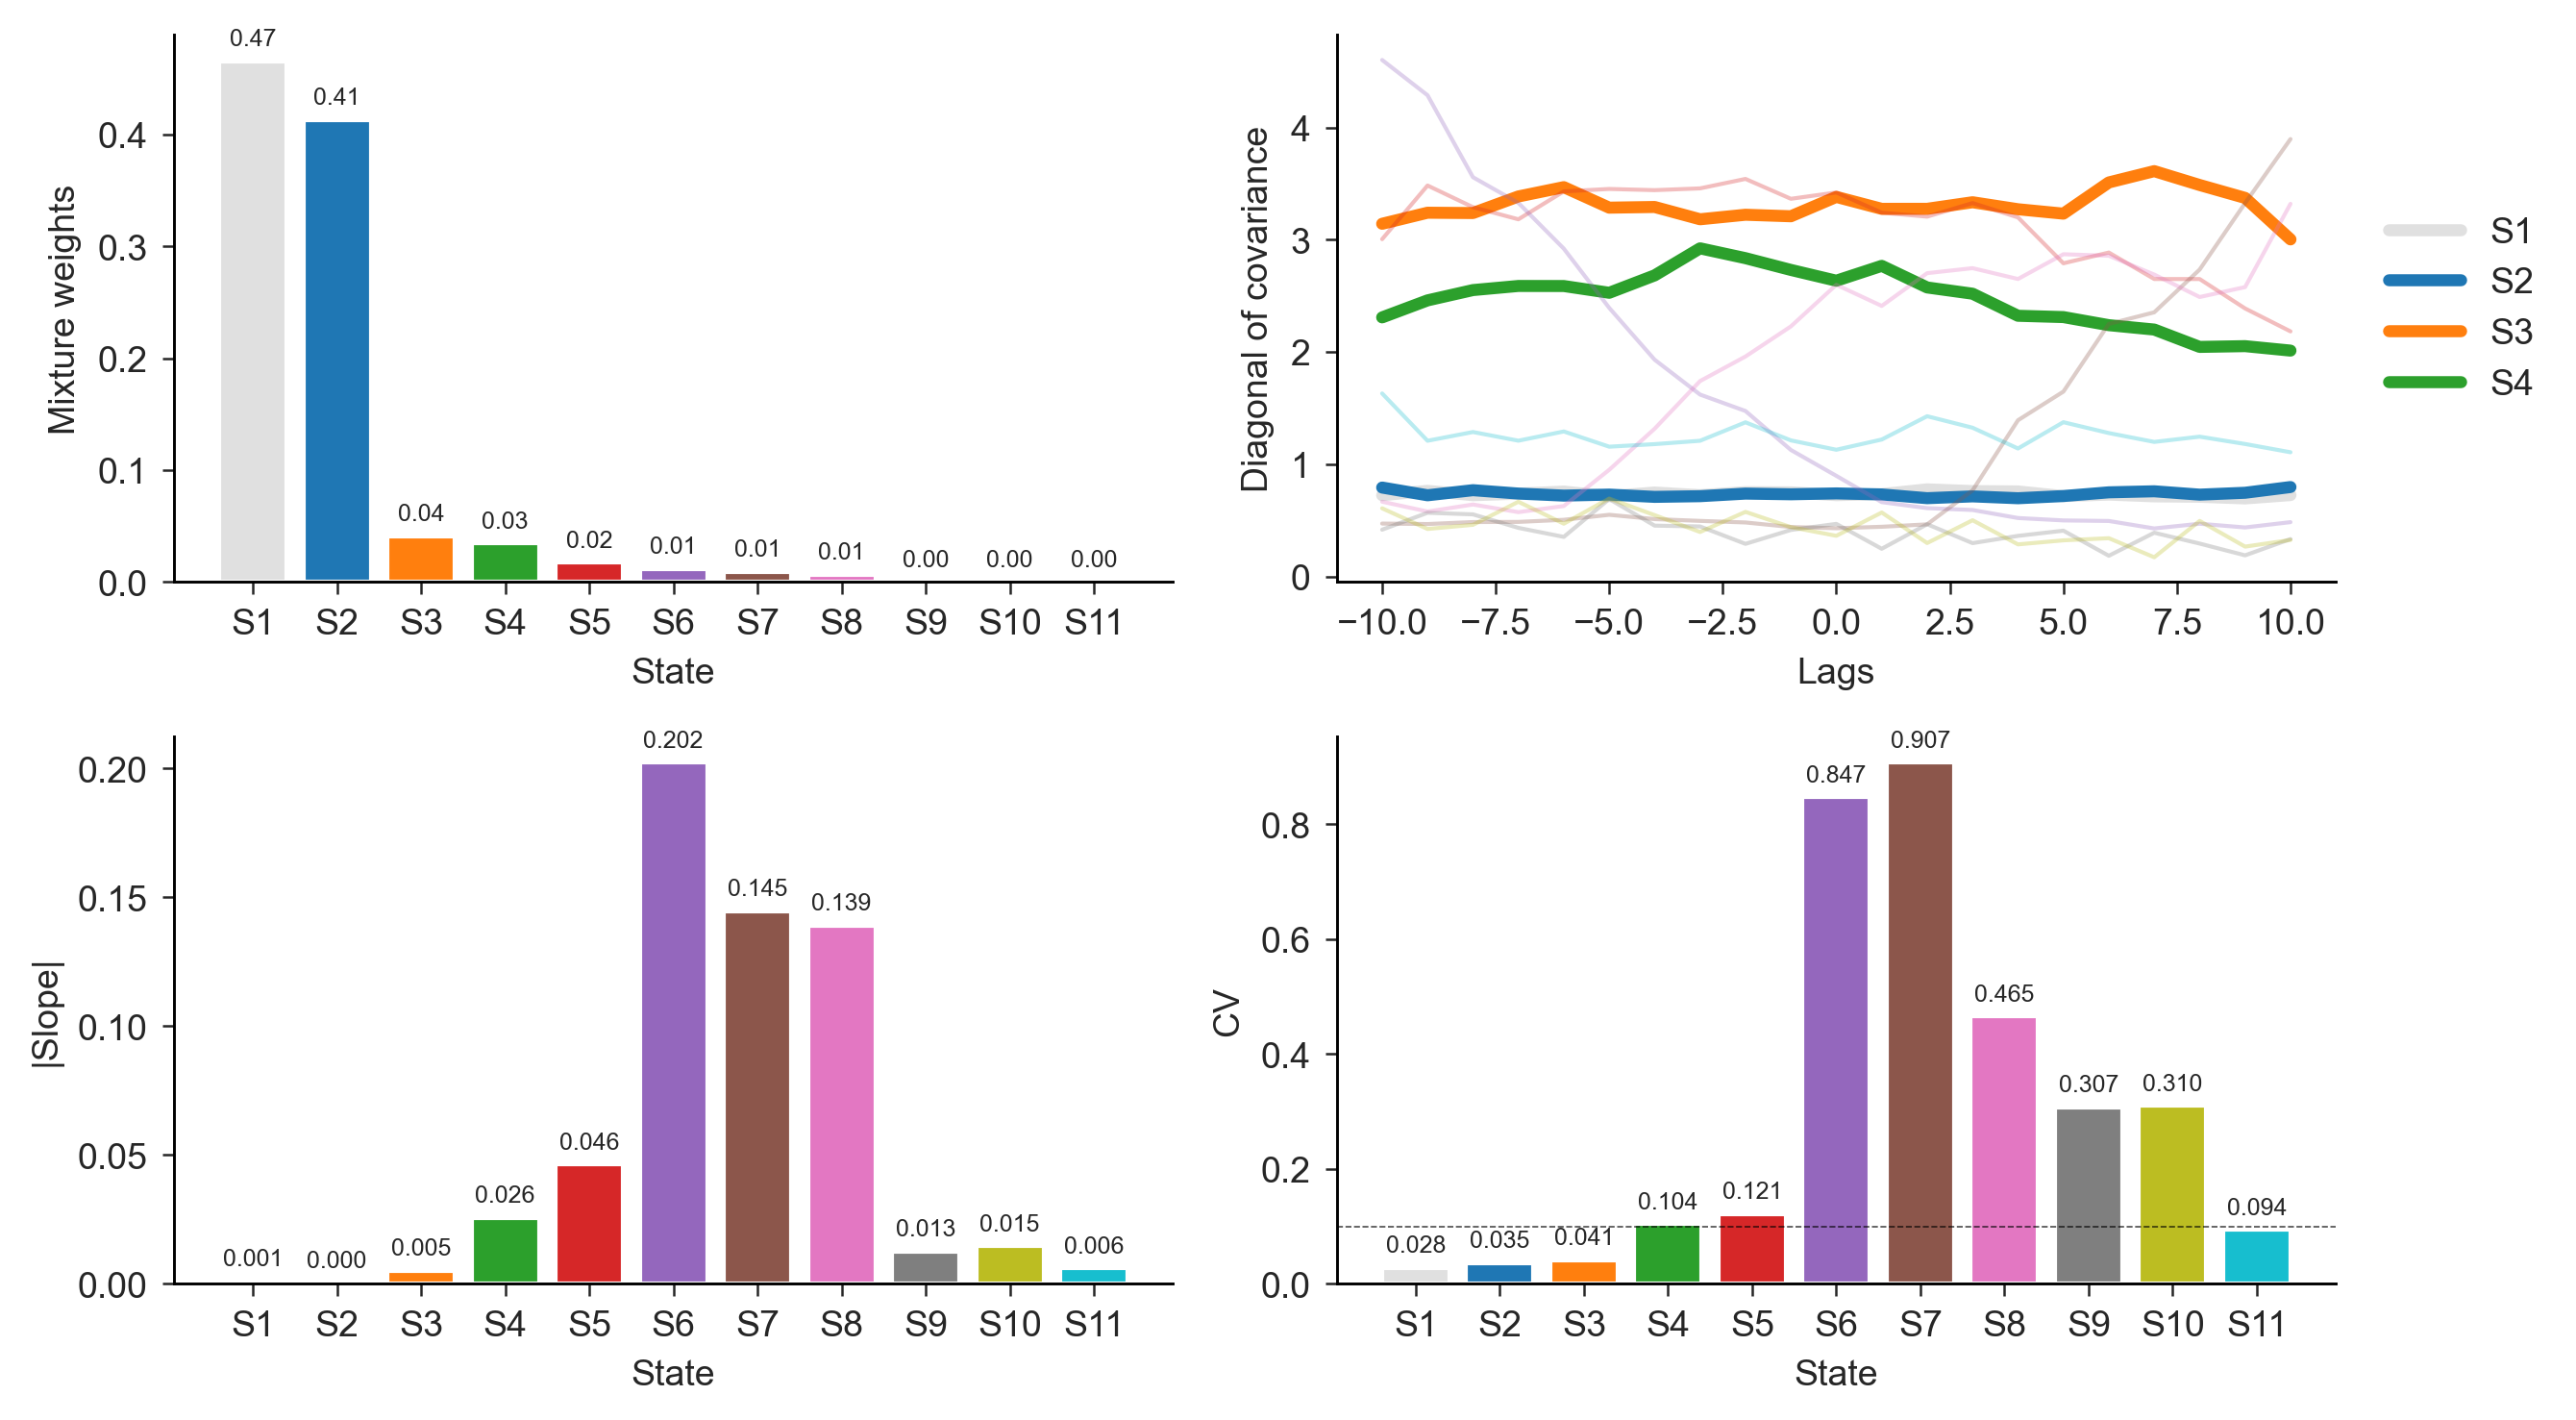

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

slopes = []
cvs = []
state_labels = []

X = np.asarray(dim_vec).reshape(-1, 1)

for i, cov in enumerate(untrunc_covs):
    d = np.diag(np.asarray(cov))

    reg = LinearRegression().fit(X, d)
    slope = reg.coef_[0]
    cv = np.std(d) / (np.mean(d) + 1e-12)

    slopes.append(abs(slope))
    cvs.append(cv)
    state_labels.append(f"S{i+1}")

bar_colors = [colors[i % len(colors)] for i in range(len(state_labels))]

def add_value_labels(axis, bars, fmt="{:.2f}", pad_frac=0.02):
    y_min, y_max = axis.get_ylim()
    pad = (y_max - y_min) * pad_frac

    for bar in bars:
        h = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        axis.text(
            x, h + pad, fmt.format(h),
            ha="center", va="bottom", fontsize=6
        )

fig, ax = plt.subplots(2, 2, figsize=(9, 5))

# ax[0,0]: mixture weights
bars0 = ax[0, 0].bar(state_labels, untrunc_weights, color=bar_colors)
ax[0, 0].set_ylabel("Mixture weights")
ax[0, 0].set_xlabel("State")

# ax[0,1]: diagonal covariance
for i, cov in enumerate(untrunc_covs):
    y = np.diag(np.asarray(cov))
    color = colors[i % len(colors)]

    if i <= 3:
        ax[0, 1].plot(dim_vec, y, label=f"S{i+1}", color=color, lw=3)
    else:
        ax[0, 1].plot(dim_vec, y, color=color, lw=1, alpha=0.3)

ax[0, 1].set_xlabel("Lags")
ax[0, 1].set_ylabel("Diagonal of covariance")
ax[0, 1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# ax[1,0]: absolute slope
bars1 = ax[1, 0].bar(state_labels, slopes, color=bar_colors)
ax[1, 0].set_ylabel("|Slope|")
ax[1, 0].set_xlabel("State")

# ax[1,1]: CV
bars2 = ax[1, 1].bar(state_labels, cvs, color=bar_colors)
ax[1, 1].set_ylabel("CV")
ax[1, 1].set_xlabel("State")
ax[1, 1].axhline(0.1, linestyle="--", linewidth=0.4,alpha =0.7, color="k")


# add labels above bars
add_value_labels(ax[0, 0], bars0, fmt="{:.2f}")
add_value_labels(ax[1, 0], bars1, fmt="{:.3f}")
add_value_labels(ax[1, 1], bars2, fmt="{:.3f}")



plt.tight_layout()
plt.show()

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_22912/850929999.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


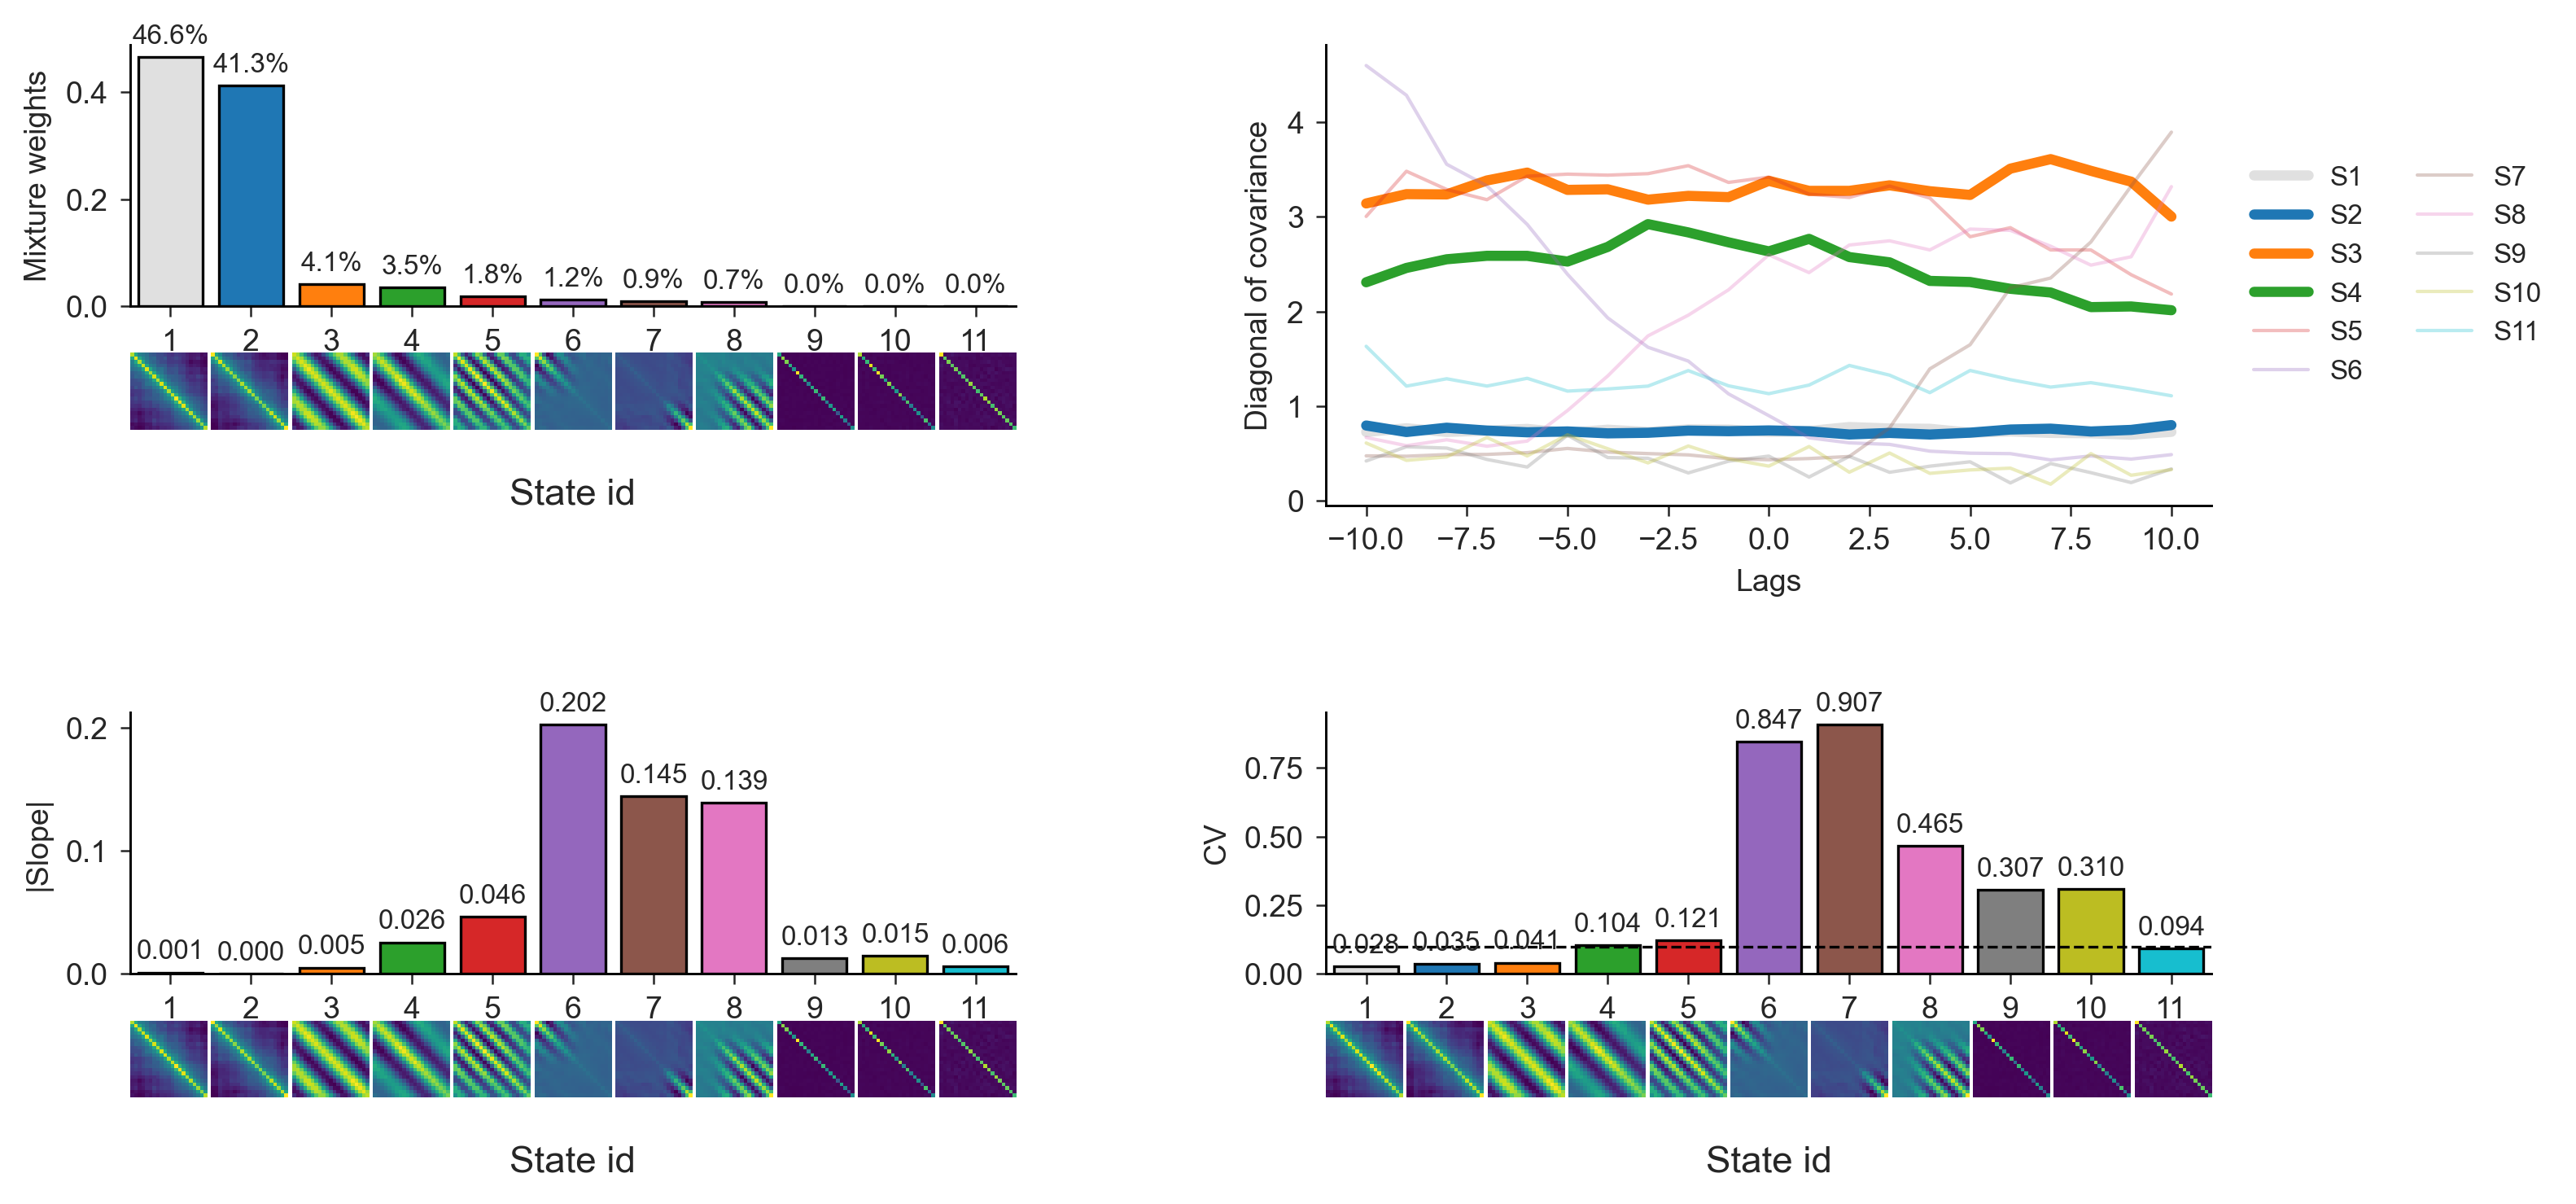

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ----------------------------
# compute metrics
# ----------------------------
slopes = []
cvs = []
state_labels = []

X = np.asarray(dim_vec).reshape(-1, 1)

for i, cov in enumerate(untrunc_covs):
    d = np.diag(np.asarray(cov))

    reg = LinearRegression().fit(X, d)
    slope = reg.coef_[0]
    cv = np.std(d) / (np.mean(d) + 1e-12)

    slopes.append(abs(slope))
    cvs.append(cv)
    state_labels.append(str(i + 1))

bar_colors = [colors[i % len(colors)] for i in range(len(state_labels))]


# ----------------------------
# helper: bar + cov thumbnails + xlabel row
# ----------------------------
def add_bar_with_covs(
    fig,
    subspec,
    values,
    covs,
    colors,
    ylabel,
    value_fmt="{:.2f}",
    xlabel="State id",
    hline=None,
    cmap="viridis",
):
    n = len(values)

    # 3 rows:
    # row 0 = bars
    # row 1 = covariance thumbnails
    # row 2 = xlabel only
    inner = subspec.subgridspec(
        3, n,
        height_ratios=[3.2, 1.2, 0.35],
        hspace=0.28,
        wspace=0.05
    )

    # --- bar axis ---
    ax_bar = fig.add_subplot(inner[0, :])

    x = np.arange(n)
    bars = ax_bar.bar(x, values, color=colors, edgecolor="black", linewidth=0.8)

    if hline is not None:
        ax_bar.axhline(hline, linestyle="--", linewidth=0.8, color="k")

    ax_bar.set_xlim(-0.5, n - 0.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(state_labels)
    ax_bar.set_ylabel(ylabel)
    ax_bar.set_xlabel("")  # avoid overlap with covariance row

    # value labels
    y_min, y_max = ax_bar.get_ylim()
    pad = (y_max - y_min) * 0.03
    for b, v in zip(bars, values):
        ax_bar.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + pad,
            value_fmt.format(v),
            ha="center",
            va="bottom",
            fontsize=8
        )

    # --- covariance thumbnails ---
    cov_axes = []
    for i, cov in enumerate(covs):
        ax_cov = fig.add_subplot(inner[1, i])
        ax_cov.imshow(np.asarray(cov), cmap=cmap, aspect="equal", interpolation="nearest")
        ax_cov.set_xticks([])
        ax_cov.set_yticks([])

        for spine in ax_cov.spines.values():
            spine.set_visible(False)

        cov_axes.append(ax_cov)

    # --- xlabel row ---
    ax_xlab = fig.add_subplot(inner[2, :])
    ax_xlab.axis("off")
    ax_xlab.text(0.5, 0.35, xlabel, ha="center", va="center", fontsize=11)

    return ax_bar, cov_axes, ax_xlab


# ----------------------------
# figure layout
# ----------------------------
fig = plt.figure(figsize=(11, 6))
outer = fig.add_gridspec(2, 2, wspace=0.35, hspace=0.45)

# ax[0,0]: mixture weights
ax_w, cov_axes_w, xlab_w = add_bar_with_covs(
    fig=fig,
    subspec=outer[0, 0],
    values=untrunc_weights,
    covs=untrunc_covs,
    colors=bar_colors,
    ylabel="Mixture weights",
    value_fmt="{:.1%}",
    xlabel="State id",
)

# ax[0,1]: diagonal covariance
ax_diag = fig.add_subplot(outer[0, 1])

for i, cov in enumerate(untrunc_covs):
    y = np.diag(np.asarray(cov))
    color = colors[i % len(colors)]

    lw = 3 if i <= 3 else 1
    alpha = 1.0 if i <= 3 else 0.3

    # label ALL states so legend includes all of them
    ax_diag.plot(
        dim_vec,
        y,
        label=f"S{i+1}",
        color=color,
        lw=lw,
        alpha=alpha
    )

ax_diag.set_xlabel("Lags")
ax_diag.set_ylabel("Diagonal of covariance")
ax_diag.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    ncol=2,
    fontsize=8
)

# ax[1,0]: absolute slope
ax_slope, cov_axes_slope, xlab_slope = add_bar_with_covs(
    fig=fig,
    subspec=outer[1, 0],
    values=slopes,
    covs=untrunc_covs,
    colors=bar_colors,
    ylabel="|Slope|",
    value_fmt="{:.3f}",
    xlabel="State id",
)

# ax[1,1]: CV
ax_cv, cov_axes_cv, xlab_cv = add_bar_with_covs(
    fig=fig,
    subspec=outer[1, 1],
    values=cvs,
    covs=untrunc_covs,
    colors=bar_colors,
    ylabel="CV",
    value_fmt="{:.3f}",
    xlabel="State id",
    hline=0.10,
)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

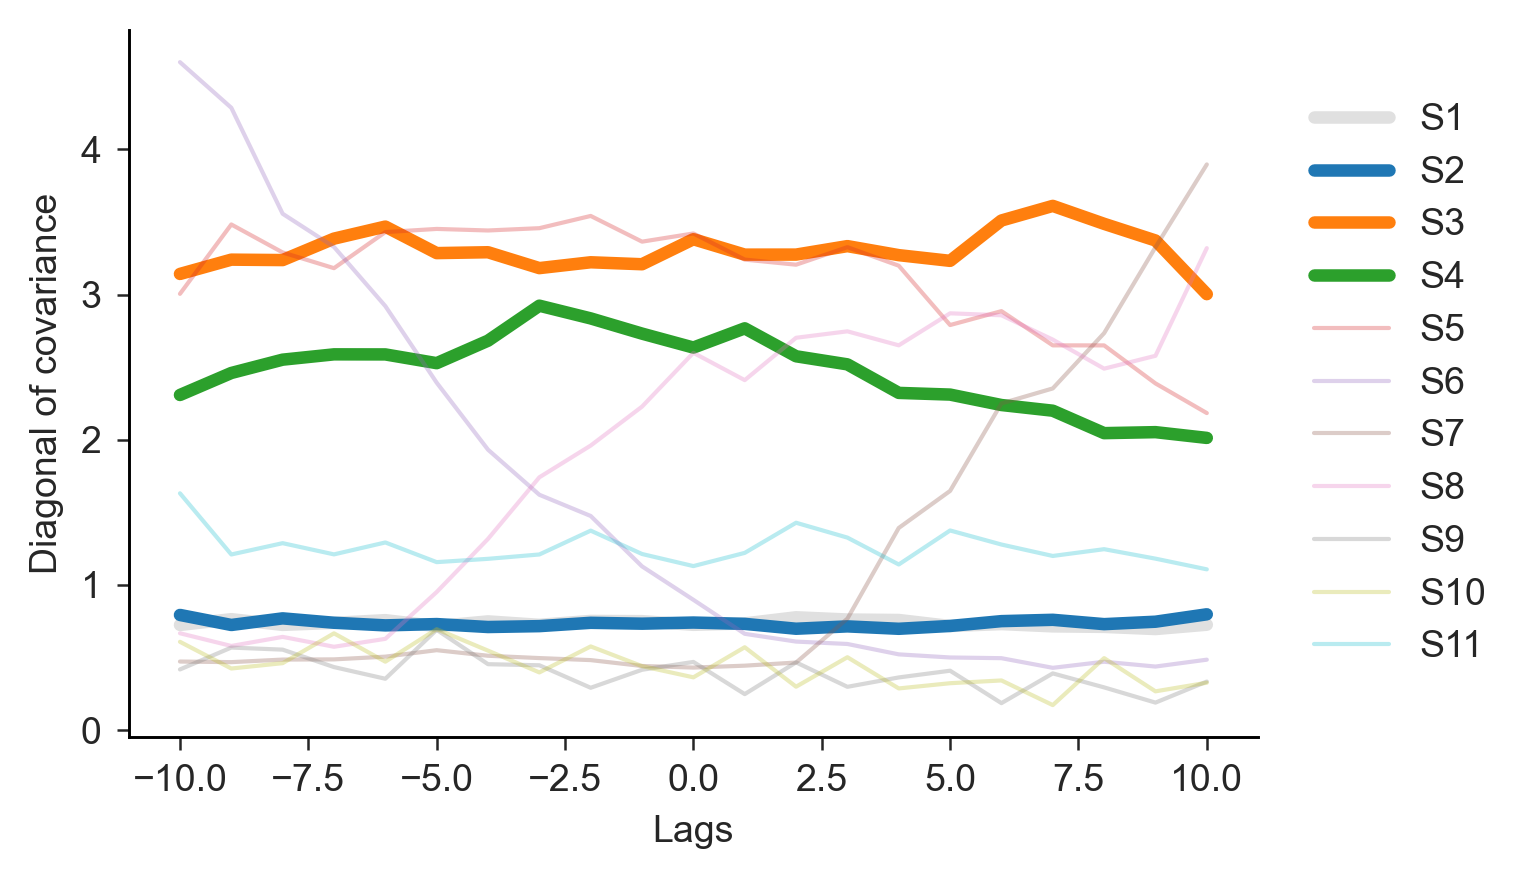

In [75]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH - 1, 3))

for i, cov in enumerate(untrunc_covs):
    if i <= 3:
        ax.plot(dim_vec, np.diag(cov), label=f"S{i+1}", color=colors[i], lw=3)
    else:
        ax.plot(dim_vec, np.diag(cov), label=f"S{i+1}", color=colors[i], lw=1, alpha=0.3)

ax.set_xlabel("Lags")
ax.set_ylabel("Diagonal of covariance")

# legend outside
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# leave room for legend
fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()


## empirical transition matrix

In [55]:
import numpy as np

def empirical_transition_matrix(states, n_states=None, alpha=0.0, ignore_negative=True):
    """
    Compute empirical transition counts and probabilities from a state sequence.

    Parameters
    ----------
    states : array-like of shape (T,)
        Integer state labels over time.
    n_states : int or None
        Number of states. If None, inferred as max(states)+1 after filtering.
    alpha : float
        Additive pseudocount for smoothing.
    ignore_negative : bool
        If True, removes labels < 0 before computing transitions.

    Returns
    -------
    counts : (K, K) ndarray
        Transition count matrix.
    probs : (K, K) ndarray
        Row-normalized transition probability matrix.
    """
    z = np.asarray(states).astype(int)

    if ignore_negative:
        z = z[z >= 0]

    if z.ndim != 1:
        raise ValueError("states must be 1D")

    if len(z) < 2:
        raise ValueError("Need at least 2 time points")

    if n_states is None:
        n_states = int(z.max()) + 1

    counts = np.zeros((n_states, n_states), dtype=float)

    for a, b in zip(z[:-1], z[1:]):
        if 0 <= a < n_states and 0 <= b < n_states:
            counts[a, b] += 1

    probs = counts + alpha
    row_sums = probs.sum(axis=1, keepdims=True)

    # avoid division by zero for states never visited
    probs = np.divide(probs, row_sums, out=np.zeros_like(probs), where=row_sums > 0)

    return counts, probs

In [56]:
est_states.shape

(44984,)

In [57]:
num_states

3

In [58]:
est_states = np.argmax(dpgmm_states_onehot, axis=1)
est_states

array([3, 3, 3, ..., 1, 1, 1], shape=(44980,))

In [59]:
counts, P = empirical_transition_matrix(est_states, n_states=num_active_states, alpha=0)

print("Counts:\n", counts)
print("Transition matrix:\n", np.round(P, 3))



Counts:
 [[3.6723e+04 1.1000e+01 4.8000e+01 6.3000e+01]
 [1.3000e+01 3.5820e+03 4.4000e+01 0.0000e+00]
 [4.5000e+01 4.7000e+01 1.3080e+03 0.0000e+00]
 [6.4000e+01 0.0000e+00 0.0000e+00 3.0310e+03]]
Transition matrix:
 [[0.997 0.    0.001 0.002]
 [0.004 0.984 0.012 0.   ]
 [0.032 0.034 0.934 0.   ]
 [0.021 0.    0.    0.979]]


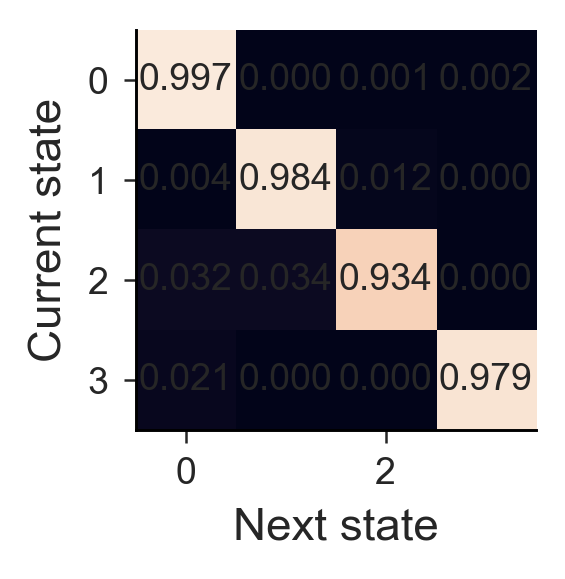

In [60]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(P)
ax.set_xlabel("Next state", fontsize=11)
ax.set_ylabel("Current state", fontsize=11)
    # minor grid to separate cells cleanly
ax.set_xticks(np.arange(-0.5, num_active_states, 1), minor=True)
ax.set_yticks(np.arange(-0.5, num_active_states, 1), minor=True)
ax.tick_params(which="minor", bottom=False, left=False)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        ax.text(j, i, f"{P[i, j]:.3f}", ha="center", va="center")


aa# 4 states scenario

In [61]:
sim_cond = "4states_500Hz"
data_dir = "../data/simulations"
data_file = f"{data_dir}/{sim_cond}_data.npz"


sim_data = np.load(data_file)

signal = sim_data["signal_sample"]
states = sim_data["states_sample"]
bursts = sim_data["bursts_sample"]


import pickle
performance_dir = "../data/performance"
save_path = os.path.join(performance_dir, f"{sim_cond}_res.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)



In [62]:
res = pd.DataFrame(res)

In [ ]:
from nds_toolbox.preprocessing.features import compute_tde, trim_data, choose_embedding_dim

In [ ]:

n_seconds = 60*3  # Total duration in seconds.
fs = 500

snr_db = 2

freq = np.array([20, 30, 40])  #ground truth = 4 states (including noise state)
num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles = 2.5, ensure_odd = True)
tde_signal = compute_tde(signal, num_emb)



trimmed_states = trim_data(states, num_embeddings = num_emb, verbose = False)
trimmed_signal = trim_data(signal, num_embeddings = num_emb, verbose = False)
trimmed_bursts = trim_data(bursts, num_embeddings = num_emb, verbose = False)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))




num_states = int(np.ceil(np.log(len(trimmed_signal))))
print(num_states)

In [ ]:
res

In [ ]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

In [ ]:

from nds_toolbox.models.dpgmm_numpyro import truncate, get_states
from sklearn.metrics import matthews_corrcoef

In [ ]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

In [ ]:
order_gmm

In [ ]:

gmm_states = res.query("method == 'DP-GMM (Imputed)'").est_states.to_numpy()[0]
gmm_states_onehot = np.eye(num_states)[gmm_states]
gmm_mcc = res.query("method == 'DP-GMM (Imputed)'").mcc.values[0]


gmm_sumary_stats = res.query("method == 'DP-GMM (Imputed)'")["summary_stats"].values[0]
gmm_fo = gmm_sumary_stats["fractional_occupancies"]
gmm_f, gmm_psds = gmm_sumary_stats["spectra"]



order_gmm = res.query("method == 'DP-GMM (Imputed)'").order.to_numpy()[0]
alpha, weights, gmm_means, gmm_covs, untrunc_means, untrunc_covs, untrunc_weights, trunc_info, nun_active_states  = res.query("method == 'DP-GMM'").est_params.values[0].values()

untrunc_means = untrunc_means[order_gmm]
untrunc_covs = untrunc_covs[order_gmm]
untrunc_weights = untrunc_weights[order_gmm]

#trunc_means, trunc_covs, trunc_weights = truncate(1, gmm_means, gmm_covs, weights, verbose = True)
#gmm_states = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
#gmm_mcc = matthews_corrcoef(trimmed_states, gmm_states)


hmm_states = res.query("method == 'HMM (Imputed)'").est_states.to_numpy()[0]
hmm_states_onehot = np.eye(num_states)[hmm_states]
hmm_mcc = res.query("method == 'HMM (Imputed)'").mcc.values[0]

hmm_sumary_stats = res.query("method == 'HMM (Imputed)'")["summary_stats"].values[0]
#hmm_fo = hmm_sumary_stats["fractional_occupancies"]
hmm_f, hmm_psds = hmm_sumary_stats["spectra"]



order_hmm = res.query("method == 'HMM (Imputed)'").order.to_numpy()[0]
init_probs, trans_mat, hmm_means, hmm_covs, stationary_dist = res.query("method == 'HMM (Imputed)'").est_params.values[0].values()




In [ ]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
          ["gap", "gap"],
          ["c", "b"],
          ["e", "d"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 6.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2,0.2, 0.1 ,1.5, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0., hspace=0.01)
axes["gap"].set_visible(False)


axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.63), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )





for k, w in enumerate(stationary_dist):
    axes["b"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["b"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k", fontsize = MY_FONT_SIZE - 3 )
    axes["b"].set_ylabel("Stationary distribution")
    axes["b"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["b"].tick_params(axis='y', )
    #axes["b"].spines["top"].set_visible(True)
    #axes["b"].spines["right"].set_visible(True)
    axes["b"].set_ylim(0, 1)

ax_b = inset_axes(axes["b"],
                      width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["b"].transAxes,
                      borderpad = 0.5,)


for i in range(num_states):
    ax_b.plot(hmm_f[i], hmm_psds[i], color = colors[i], lw = 0.7)
    ax_b.set_xlim(0, 55)
    ax_b.set_ylim(0, 0.2)
    ax_b.set_xlabel("Frequency (Hz)", )
    ax_b.set_ylabel("PSD (a.u.)",)






for k, w in enumerate(untrunc_weights):
    axes["c"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["c"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k" , fontsize = MY_FONT_SIZE - 3 )
    axes["c"].set_ylabel("Mixture weights")
    axes["c"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["c"].tick_params(axis='y')

   #axes["c"].spines["top"].set_visible(True)
    #axes["c"].spines["right"].set_visible(True)
    axes["c"].set_ylim(0, 1)


ab_c = inset_axes(axes["c"],
                  width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["c"].transAxes,
                      borderpad = 0.5,)

for i in range(num_states):

    ab_c.plot(gmm_f[i], gmm_psds[i], color = colors[i], lw = 0.7)
    ab_c.set_xlim(0, 55)
    ab_c.set_xlabel("Frequency (Hz)")
    ab_c.set_ylabel("PSD (a.u.)")
    ab_c.set_ylim(0, 0.20)
    #ab_c.tick_params(axis="both", which="both", bottom = False, top = False, left = False, right = False)
    #ab_c.grid(False)


axes["d"].set_xlabel("HMM States")
axes["e"].set_xlabel("DP-GMM States")

for key in ["d", "e"]:
    axes[key].set_xticks([])
    axes[key].set_yticks([])
    axes[key].spines[:].set_visible(False)


fig.canvas.draw()
fig.savefig(
    f"../figures/{sim_cond}_results.jpg",
    bbox_inches="tight"
)


plt.show()



In [ ]:
vmin  = np.min([untrunc_covs, hmm_covs])               # global minimum
vmax  = np.max([untrunc_covs, hmm_covs])               # global maximum
norm  = plt.Normalize(vmin, vmax)      # shared normalisation
fig, ax = plt.subplots(1, hmm_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(hmm_covs):
    ax[i].imshow(cov, cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_hmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


In [ ]:

fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(untrunc_covs):
    ax[i].imshow(cov,  cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_gpgmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


## states before imputation


In [76]:
_gmm_mcc = res.query("method == 'DP-GMM'").mcc.values[0]
_gmm_states = res.query("method == 'DP-GMM'").est_states.to_numpy()[0]
_gmm_states_onehot = np.eye(num_states)[_gmm_states]

_hmm_mcc = res.query("method == 'HMM'").mcc.values[0]
_hmm_states = res.query("method == 'HMM'").est_states.to_numpy()[0]
_hmm_states_onehot = np.eye(num_states)[_hmm_states]


print("dp-gmm", _gmm_mcc)
print("dp-gmm (imputed)", gmm_mcc)

print("hmm", _hmm_mcc)
print("hmm (imputed)", hmm_mcc)


"""
dp-gmm 0.8618107993142023
dp-gmm (imputed) 0.938337224764793
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908
"""

IndexError: index 3 is out of bounds for axis 0 with size 3

NameError: name '_gmm_states_onehot' is not defined

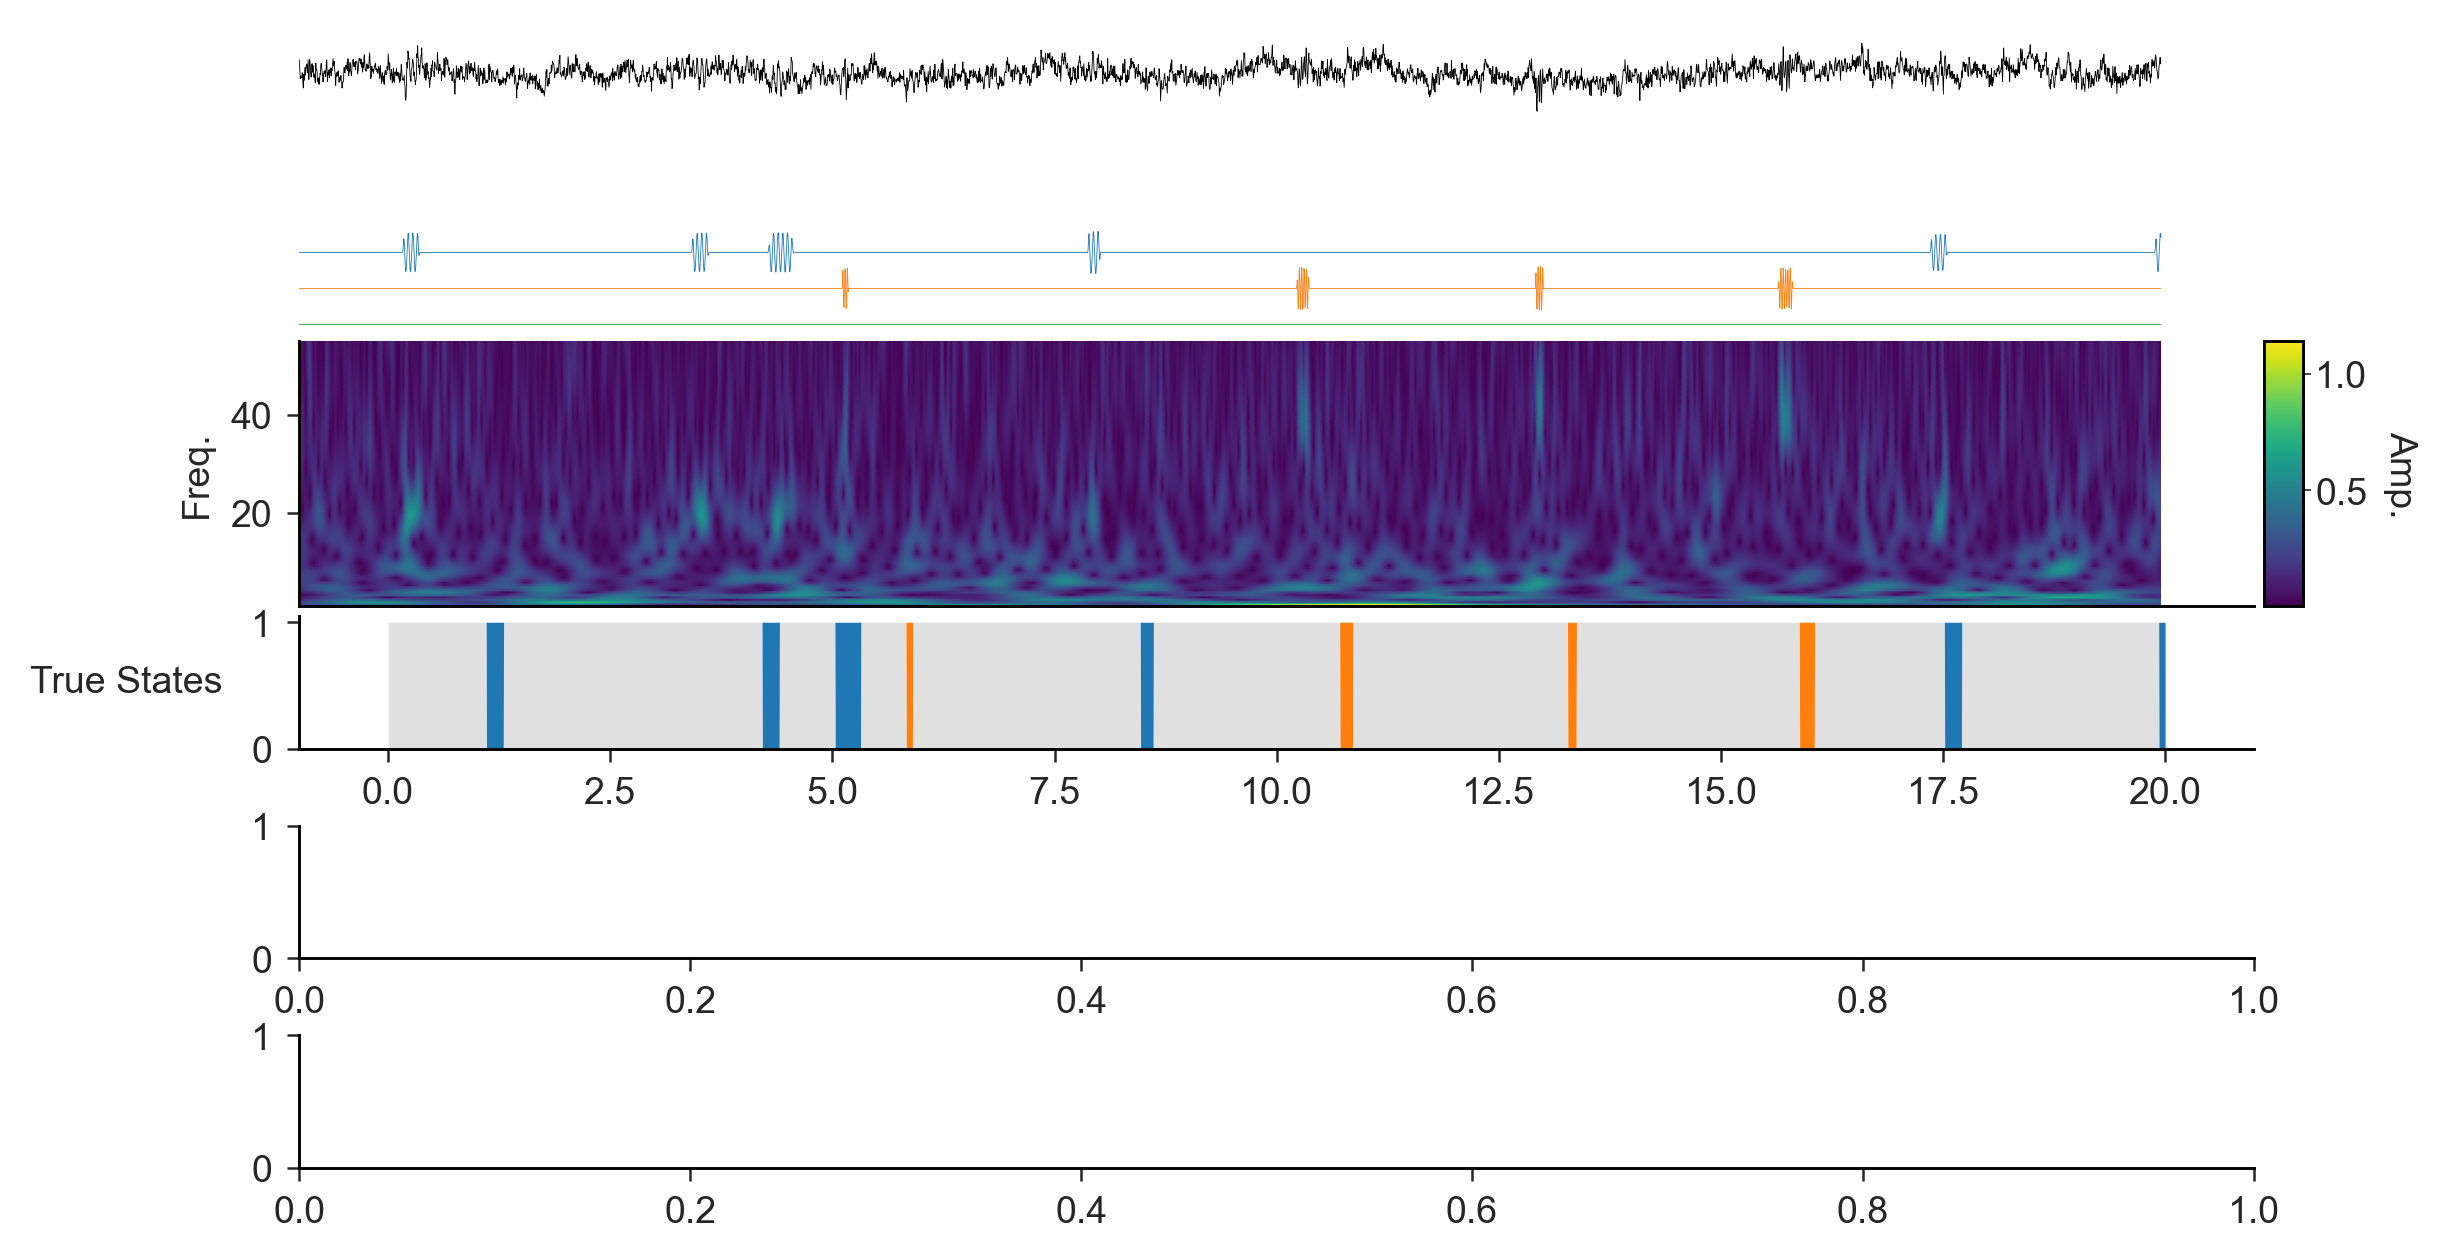

In [77]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3,0.3]}
)

fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)



axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], _gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {_gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], _hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {_hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.33), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )



fig.savefig(
    f"../figures/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


plt.show()



## HMM

In [ ]:
import pickle
save_path = os.path.join(performance_dir, f"{sim_cond}_HMM_results.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df.head()


In [ ]:
hmm_res = df.query("method == 'HMM'")
num_states_vec = hmm_res.num_states.to_numpy().astype(int)


hmm_color   = "#1f77b4"



elbos = hmm_res["loss_best"]
fig, ax = plt.subplots(figsize = (FIG_WIDTH, 3))
ax.bar(num_states_vec, elbos, color = hmm_color, width = 1, align = "center")
ax.set_yscale("log")
ax.set_xticks(num_states_vec)
ax.set_ylabel("NELBO")
ax.set_xlabel("Number of States")


fig.savefig(
    f"../figures/{sim_cond}_HMM_nelbo.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)








# 4-state scenario

In [28]:
sim_cond_data = "4states_snr"

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (10, 11, 45000)


In [38]:

sim_cond = "4states_snr"


performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df["burst_f"] = df["burst_f"].apply(tuple)

df

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.015649,0.7979713
1,DP-GMM (Edge-removed),"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7979713
2,DP-GMM (Imputed),"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7979713
3,DP-GMM (Imputed & Edge-removed),"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7979713
4,DP-GMM,"[-1.6865965774092944, -0.7849358210542872, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-8,"{'alpha': 0.327906, 'weights': [0.8902932, 0.1...",0.8018716,1,454024514,...,143.150413,0.064824,143.215237,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.054320,0.8018716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,DP-GMM (Imputed & Edge-removed),"[-0.5958742345117862, -0.4566765219504641, 0.1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,8,"{'alpha': 3.0767372, 'weights': [0.8138619, 0....",0.6678521,6,1390200052,...,135.987632,0.047583,136.035215,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",None,0.834728,0.6678521
436,DP-GMM,"[-0.5289704780701638, -0.40565934998810493, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,10,"{'alpha': 2.2566037, 'weights': [0.7370179, 0....",0.5649247,1,720172697,...,141.419045,0.049044,141.468088,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 4, 2, 3, 5, 6, 7, 8, 9]",None,0.745762,0.5649247
437,DP-GMM (Edge-removed),"[-0.5289704780701638, -0.40565934998810493, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,10,"{'alpha': 2.2566037, 'weights': [0.8261363, 0....",0.5649247,1,720172697,...,141.419045,0.049044,141.468088,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 3, 2]",None,0.863006,0.5649247
438,DP-GMM (Imputed),"[-0.5289704780701638, -0.40565934998810493, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,10,"{'alpha': 2.2566037, 'weights': [0.7370179, 0....",0.5649247,1,720172697,...,141.419045,0.049044,141.468088,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 4, 2, 3]",None,0.829242,0.5649247


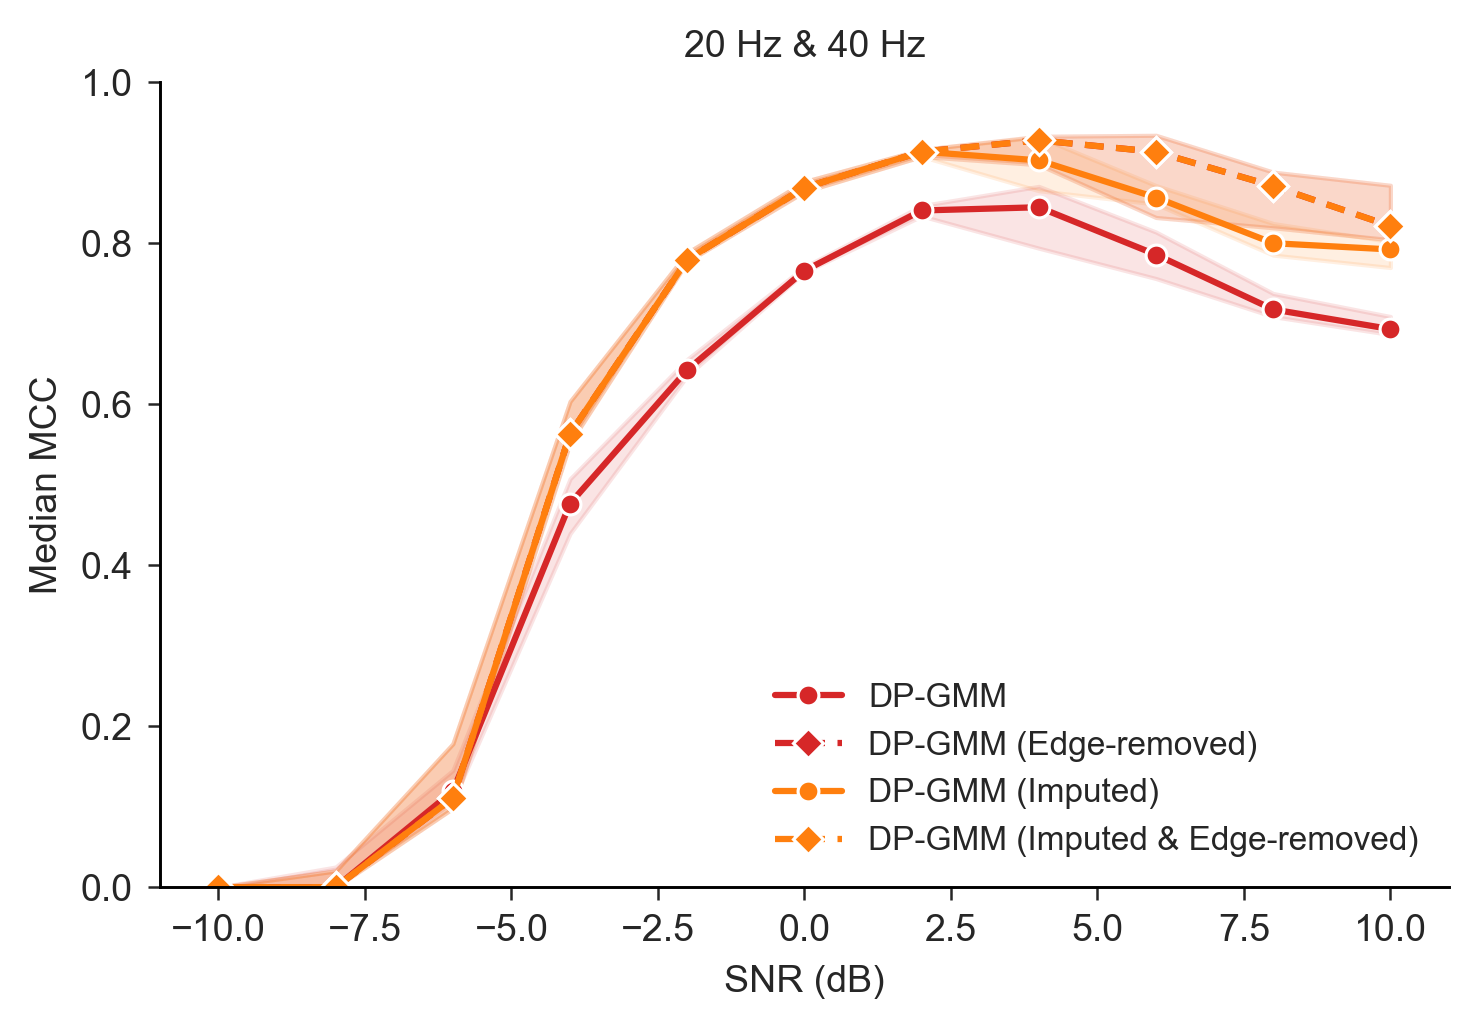

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

dpgmm_methods = [
    "DP-GMM",
    "DP-GMM (Edge-removed)",
    "DP-GMM (Imputed)",
    "DP-GMM (Imputed & Edge-removed)",
]

dpgmm_color = "#d62728"
dpgmm_imputed_color = "#ff7f0e"

palette = {
    "DP-GMM": dpgmm_color,
    "DP-GMM (Edge-removed)": dpgmm_color,
    "DP-GMM (Imputed)": dpgmm_imputed_color,
    "DP-GMM (Imputed & Edge-removed)": dpgmm_imputed_color,
}

dashes = {
    "DP-GMM": "",
    "DP-GMM (Edge-removed)": (3, 2),
    "DP-GMM (Imputed)": "",
    "DP-GMM (Imputed & Edge-removed)": (3, 2),
}

markers = {
    "DP-GMM": "o",
    "DP-GMM (Edge-removed)": "D",
    "DP-GMM (Imputed)": "o",
    "DP-GMM (Imputed & Edge-removed)": "D",
}

# Use this when plotting a specific frequency condition
df_plot = (
    df
    .query("method in @dpgmm_methods")
    .copy()
)

fig, ax = plt.subplots(figsize=(5, 3.5))

sns.lineplot(
    data=df_plot,
    x="snr",
    y="mcc",
    hue="method",
    style="method",
    hue_order=dpgmm_methods,
    style_order=dpgmm_methods,
    palette=palette,
    dashes=dashes,
    markers=markers,
    estimator="median",
    errorbar=("pi", 50),       # interquartile range: 25th–75th percentiles
    err_style="band",
    err_kws={"alpha": 0.12},
    linewidth=1.5,
    markersize=5,
    legend="full",
    ax=ax,
)

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Median MCC")
ax.set_ylim(0, 1)
ax.set_title(f"{plot_f[0]} Hz & {plot_f[1]} Hz")

ax.legend(
    title=None,
    frameon=False,
    fontsize=8,
)

sns.despine()
plt.tight_layout()
plt.show()

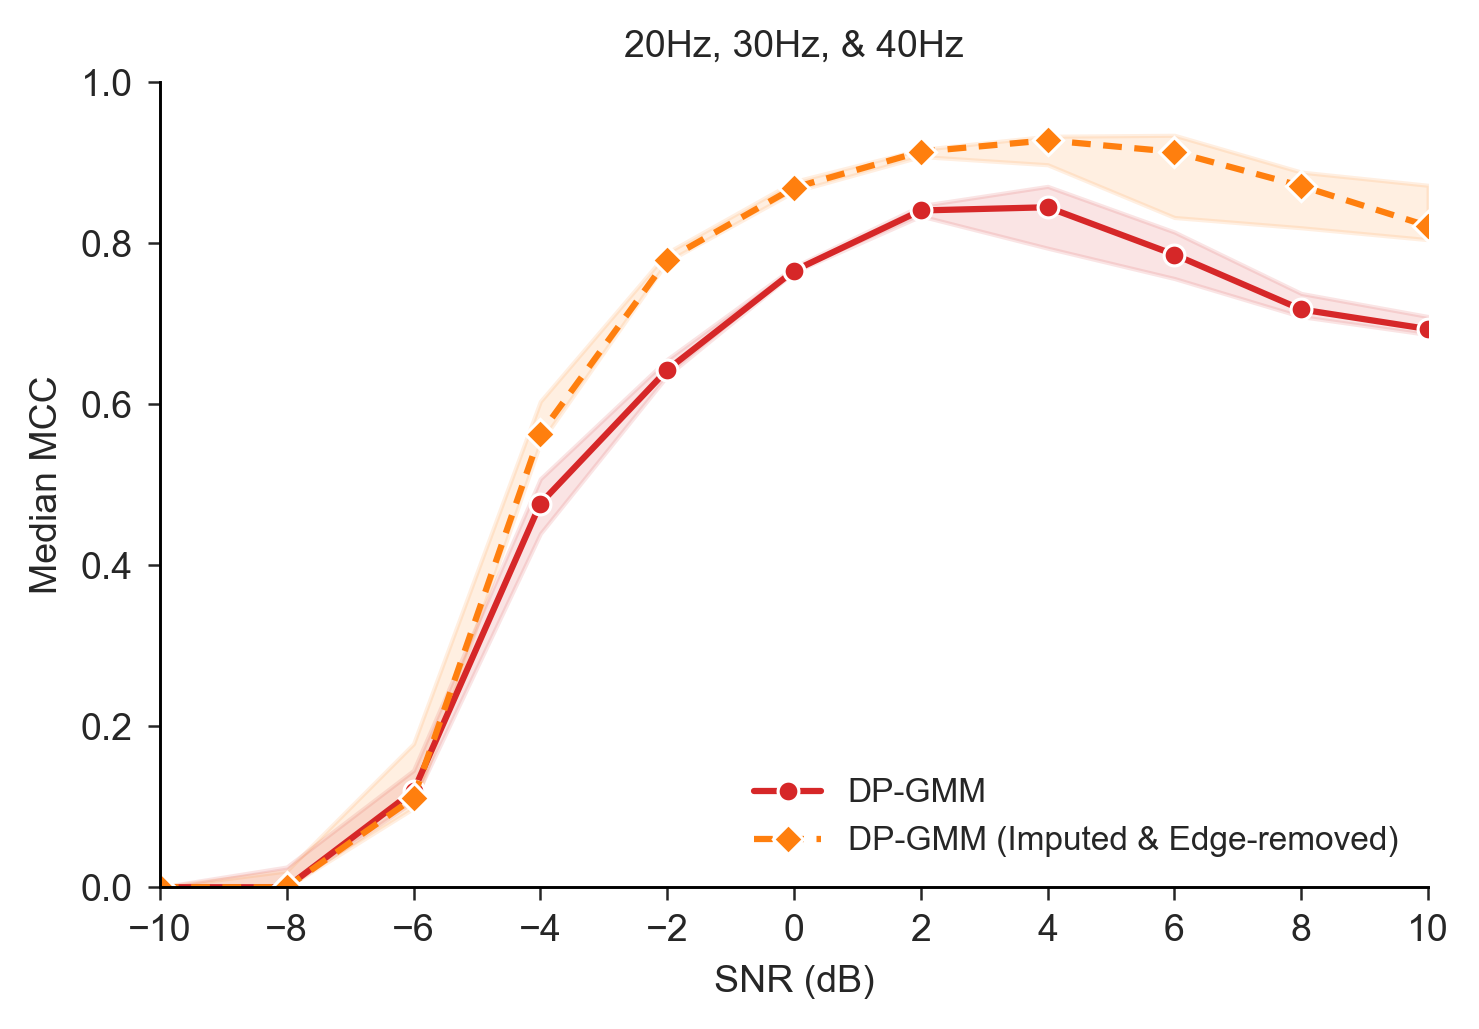

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB

# Methods to include
dpgmm_methods = [
    "DP-GMM",
    "DP-GMM (Imputed & Edge-removed)",
]

# Colors
dpgmm_color = "#d62728"
dpgmm_imputed_color = "#ff7f0e"

palette = {
    "DP-GMM": dpgmm_color,
    "DP-GMM (Edge-removed)": dpgmm_color,
    "DP-GMM (Imputed & Edge-removed)": dpgmm_imputed_color,
}

# Line styles
dashes = {
    "DP-GMM": "",
    "DP-GMM (Edge-removed)": (3, 2),
    "DP-GMM (Imputed & Edge-removed)": (3, 2),
}

# Markers
markers = {
    "DP-GMM": "o",
    "DP-GMM (Edge-removed)": "D",
    "DP-GMM (Imputed & Edge-removed)": "D",
}

# Filter data
df_plot = (
    df.loc[
        df["method"].isin(dpgmm_methods)
        & df["snr"].isin(snr_range)
    ]
    .copy()
)

# If df still contains several frequency conditions, use this instead:
# df_plot = (
#     df.loc[
#         df["method"].isin(dpgmm_methods)
#         & df["snr"].isin(snr_range)
#         & (df["burst_f"] == plot_f)
#     ]
#     .copy()
# )

fig, ax = plt.subplots(figsize=(5, 3.5))

sns.lineplot(
    data=df_plot,
    x="snr",
    y="mcc",
    hue="method",
    style="method",
    hue_order=dpgmm_methods,
    style_order=dpgmm_methods,
    palette=palette,
    dashes=dashes,
    markers=markers,
    estimator="median",
    errorbar=("pi", 50),      # IQR: 25th–75th percentiles
    err_style="band",
    err_kws={"alpha": 0.12},
    linewidth=1.5,
    markersize=5,
    legend="full",
    ax=ax,
)

ax.set_xticks(snr_range)
ax.set_xlim(snr_range.min(), snr_range.max())
ax.set_ylim(0, 1)

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Median MCC")
ax.set_title(f"20Hz, 30Hz, & 40Hz")

ax.legend(
    title=None,
    frameon=False,
    fontsize=8,
    loc="lower right",
)

sns.despine()
plt.tight_layout()
plt.show()

In [43]:
df

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.015649,0.7979713
1,DP-GMM (Edge-removed),"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7979713
2,DP-GMM (Imputed),"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7979713
3,DP-GMM (Imputed & Edge-removed),"[-1.6927585740477118, -0.7876737799504436, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-10,"{'alpha': 0.34009394, 'weights': [0.93227667, ...",0.7979713,1,454024514,...,157.076845,0.579821,157.656665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7979713
4,DP-GMM,"[-1.6865965774092944, -0.7849358210542872, -1....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,-8,"{'alpha': 0.327906, 'weights': [0.8902932, 0.1...",0.8018716,1,454024514,...,143.150413,0.064824,143.215237,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.054320,0.8018716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,DP-GMM (Imputed & Edge-removed),"[-0.5958742345117862, -0.4566765219504641, 0.1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,8,"{'alpha': 3.0767372, 'weights': [0.8138619, 0....",0.6678521,6,1390200052,...,135.987632,0.047583,136.035215,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",None,0.834728,0.6678521
436,DP-GMM,"[-0.5289704780701638, -0.40565934998810493, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,10,"{'alpha': 2.2566037, 'weights': [0.7370179, 0....",0.5649247,1,720172697,...,141.419045,0.049044,141.468088,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 4, 2, 3, 5, 6, 7, 8, 9]",None,0.745762,0.5649247
437,DP-GMM (Edge-removed),"[-0.5289704780701638, -0.40565934998810493, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,10,"{'alpha': 2.2566037, 'weights': [0.8261363, 0....",0.5649247,1,720172697,...,141.419045,0.049044,141.468088,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 3, 2]",None,0.863006,0.5649247
438,DP-GMM (Imputed),"[-0.5289704780701638, -0.40565934998810493, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 30, 40)",250,10,"{'alpha': 2.2566037, 'weights': [0.7370179, 0....",0.5649247,1,720172697,...,141.419045,0.049044,141.468088,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 4, 2, 3]",None,0.829242,0.5649247
